# Aerosol Classification using AERONET Lidar DPR 

Shin, S.-K., Tesche, M., Noh, Y., and Müller, D.: Aerosol-type classification based on AERONET version 3 inversion products, Atmos. Meas. Tech., 12, 3789–3803, https://doi.org/10.5194/amt-12-3789-2019, 2019.

## import packages

In [1]:
import xarray as xr
import pandas as pd
import netCDF4, os,re,copy,glob
import numpy as np
import matplotlib.pyplot as plt
import pickle,flox
import cartopy
import sys,os,glob,datetime
# sys.path.append("/home/ec2-user/Research/python_lib")
# from AWS_Utils import get_NASA_creds
import earthaccess
import tempfile
import MODIS_Lib 
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import os,sys
# sys.path.append("/home/ec2-user/Research/python_lib")
# import AWS_Utils, PACE_Util_AWS
# from AWS_Utils import get_NASA_creds

## Read in AERONET level2 SDA data and level3 inv data

In [3]:
def read_aeronet_to_dict(file_path,product_name='inv'):
    """
    Reads an AERONET file. Returns None if ANY target variable is missing.
    """
    if product_name == 'inv':
        target_columns = [
            "Date(dd:mm:yyyy)", "Time(hh:mm:ss)", "Day_of_Year", "Day_of_Year(Fraction)",
            "AOD_Coincident_Input[440nm]", "AOD_Coincident_Input[675nm]",
            "AOD_Coincident_Input[870nm]", "AOD_Coincident_Input[1020nm]",
            "Angstrom_Exponent_440-870nm_from_Coincident_Input_AOD",
            "AOD_Extinction-Total[440nm]", "AOD_Extinction-Total[675nm]",
            "AOD_Extinction-Total[870nm]", "AOD_Extinction-Total[1020nm]",
            "AOD_Extinction-Fine[440nm]", "AOD_Extinction-Fine[675nm]",
            "AOD_Extinction-Fine[870nm]", "AOD_Extinction-Fine[1020nm]",
            "AOD_Extinction-Coarse[440nm]", "AOD_Extinction-Coarse[675nm]",
            "AOD_Extinction-Coarse[870nm]", "AOD_Extinction-Coarse[1020nm]",
            "Extinction_Angstrom_Exponent_440-870nm-Total",
            "Single_Scattering_Albedo[440nm]", "Single_Scattering_Albedo[675nm]",
            "Single_Scattering_Albedo[870nm]", "Single_Scattering_Albedo[1020nm]",
            "Latitude(Degrees)", "Longitude(Degrees)","Lidar_Ratio[440nm]",
            "Lidar_Ratio[675nm]","Lidar_Ratio[870nm]","Lidar_Ratio[1020nm]",
            "Depolarization_Ratio[440nm]","Depolarization_Ratio[675nm]","Depolarization_Ratio[870nm]",
            "Depolarization_Ratio[1020nm]"
        ]
    elif product_name == 'sda':
        target_columns = ["Date_(dd:mm:yyyy)","Time_(hh:mm:ss)",
                          "Day_of_Year", "Day_of_Year(fraction)",
                          "Total_AOD_500nm[tau_a]","Fine_Mode_AOD_500nm[tau_f]",
                          "Coarse_Mode_AOD_500nm[tau_c]","FineModeFraction_500nm[eta]",
                          "Angstrom_Exponent(AE)-Total_500nm[alpha]"
                         ]

    try:
        df = pd.read_csv(
            file_path, 
            skiprows=6, 
            na_values=[-999, -999.0], 
            encoding='latin-1'
        )
        
        df.columns = df.columns.str.strip()
        # for c in df.columns:
        #     print(c)

        # --- NEW LOGIC: Check for missing columns first ---
        missing_cols = [col for col in target_columns if col not in df.columns]
        
        if missing_cols:
            #print('missing cols', missing_cols)
            # Return None to signal failure
            return None

        # If all columns exist, create the dictionary
        data_dict = {col: df[col].values for col in target_columns}
        return data_dict

    except Exception as e:
        print(f"Error reading file: {e}")
        return None



In [4]:
AERONET_data_path = '/home/ec2-user/Research/AERONET_INV_Level2_v3.0_allsites/'
AERONET_files = glob.glob(AERONET_data_path+'*.all')

AERONET_data_all_dict = {}


for i in range(len(AERONET_files)):
    if i % 100 == 0:
        print('finished',i, 'sites among total', len(AERONET_files))
    filename = os.path.basename(AERONET_files[i])
    parts = filename.split('_', 2)
    site_name = parts[2].replace('.all', '')

    # Call the function
    aeronet_data = read_aeronet_to_dict(AERONET_files[i])
    
    # --- NEW LOGIC: Check if data was successfully read ---
    if aeronet_data is None:
        print(f"Skipping {site_name}: Missing required variables.")
        continue  # Skip to the next iteration of the loop
        
    # Only add to dictionary if valid
    AERONET_data_all_dict[site_name] = aeronet_data
    # print(f"Successfully added {site_name}")

print(f"\nTotal valid sites loaded: {len(AERONET_data_all_dict)}")

finished 0 sites among total 1309
finished 100 sites among total 1309
finished 200 sites among total 1309
finished 300 sites among total 1309
Skipping Palgrunden: Missing required variables.
finished 400 sites among total 1309
Skipping Helsinki_Lighthouse: Missing required variables.
finished 500 sites among total 1309
Skipping Lucinda: Missing required variables.
Skipping LSU: Missing required variables.
Skipping LISCO: Missing required variables.
Skipping WaveCIS_Site_CSI_6: Missing required variables.
Skipping SAGRES: Missing required variables.
Skipping Gloria: Missing required variables.
finished 600 sites among total 1309
Skipping USC_SEAPRISM: Missing required variables.
Skipping DRAGON_BelAir: Missing required variables.
finished 700 sites among total 1309
Skipping GOT_Seaprism: Missing required variables.
finished 800 sites among total 1309
Skipping Galata_Platform: Missing required variables.
Skipping Ieodo_Station: Missing required variables.
Skipping Zeebrugge-MOW1: Missing

## analysis of the lidar DPR from AERONET

In [33]:
# selected sites from Shin et al 2019 oaoer
# site_list = ['Beijing','XiangHe',
#              'Seoul_SNU','Yonsei_University','Gosan_SNU',
#              'Osaka','Shirahama',
#              'Capo_Verde','Banizoumbou','Dakar',
#              'Abracos_Hill','Mongu','Alta_Floresta',
#              'GSFC','Ispra','Mexico_City']
site_list = AERONET_data_all_dict.keys()
DPR_site_list = np.array([])

for site in site_list:
    DPR_site_list=np.append(DPR_site_list,AERONET_data_all_dict[site]['Depolarization_Ratio[1020nm]'])

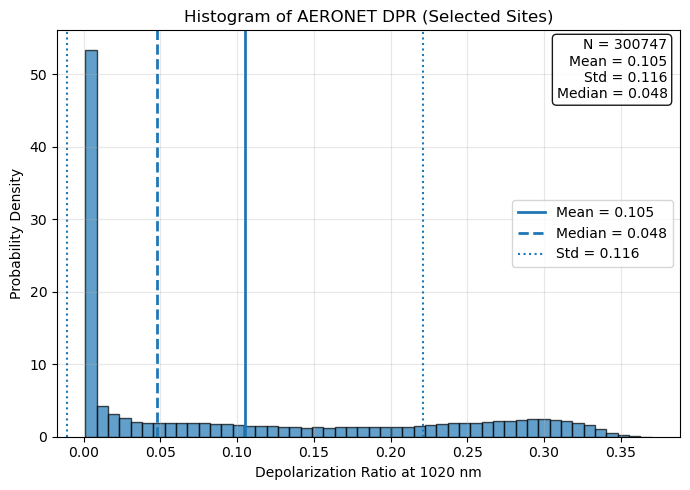

In [34]:
DPR = np.asarray(DPR_site_list)
DPR = DPR[np.isfinite(DPR)]
mean_val = np.mean(DPR)
std_val  = np.std(DPR)
median_val = np.median(DPR)
n_val = DPR.size
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    DPR,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

# Vertical lines for statistics
ax.axvline(mean_val, linestyle="-", linewidth=2, label=f"Mean = {mean_val:.3f}")
ax.axvline(median_val, linestyle="--", linewidth=2, label=f"Median = {median_val:.3f}")
ax.axvline(mean_val + std_val, linestyle=":", linewidth=1.5)
ax.axvline(mean_val - std_val, linestyle=":", linewidth=1.5, label=f"Std = {std_val:.3f}")

# Labels and title
ax.set_xlabel("Depolarization Ratio at 1020 nm")
ax.set_ylabel("Probability Density")
ax.set_title("Histogram of AERONET DPR (Selected Sites)")

# Text annotation box
textstr = (
    f"N = {n_val}\n"
    f"Mean = {mean_val:.3f}\n"
    f"Std = {std_val:.3f}\n"
    f"Median = {median_val:.3f}"
)

ax.text(
    0.98, 0.98, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


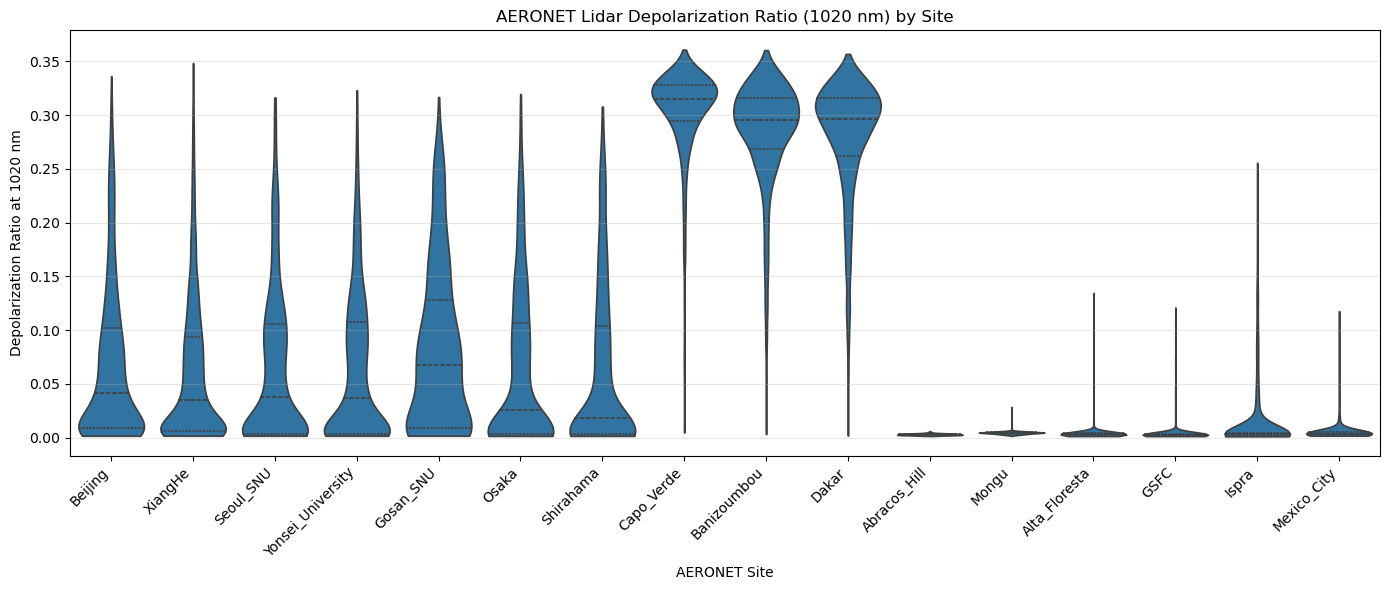

In [7]:
import seaborn as sns

records = []

for site in site_list:
    dpr = AERONET_data_all_dict[site]['Depolarization_Ratio[1020nm]']
    dpr = np.asarray(dpr)
    dpr = dpr[np.isfinite(dpr)]  # remove NaNs / infs

    for v in dpr:
        records.append({"Site": site, "DPR": v})

df = pd.DataFrame(records)
plt.figure(figsize=(14, 6))

sns.violinplot(
    data=df,
    x="Site",
    y="DPR",
    inner="quartile",   # shows median and IQR
    cut=0,
    density_norm="width"
)

plt.ylabel("Depolarization Ratio at 1020 nm")
plt.xlabel("AERONET Site")
plt.title("AERONET Lidar Depolarization Ratio (1020 nm) by Site")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [35]:

def dust_fraction_from_pldr(pldr, pldr_nd=0.02, pldr_d=0.30):
    """
    Dust fraction (Rd) from particle linear depolarization ratio (PLDR, δp)
    following Eq. (3) in Shin et al. (2019, AMT) at 1020 nm.

    Rd = ((δp - δp_nd) / (δp_d - δp_nd)) * ((1 + δp_d) / (1 + δp))

    Rules applied in the paper:
      - if δp < δp_nd  -> Rd = 0
      - if δp > δp_d   -> Rd = 1

    Parameters
    ----------
    pldr : array-like
        PLDR / depolarization ratio values (can be scalar, list, np.array).
    pldr_nd : float
        Non-dust PLDR (default 0.02 for 1020 nm).
    pldr_d : float
        Pure dust PLDR (default 0.30 for 1020 nm).

    Returns
    -------
    Rd : np.ndarray
        Dust fraction (0..1), same shape as input.
    """
    pldr = np.asarray(pldr, dtype=float)

    Rd = np.full_like(pldr, np.nan, dtype=float)
    valid = np.isfinite(pldr)

    # Eq. (3)
    denom = (pldr_d - pldr_nd)
    Rd[valid] = ((pldr[valid] - pldr_nd) / denom) * ((1.0 + pldr_d) / (1.0 + pldr[valid]))

    # Apply bounds described in the paper
    Rd = np.where(pldr < pldr_nd, 0.0, Rd)
    Rd = np.where(pldr > pldr_d,  1.0, Rd)

    # Safety clamp (also handles tiny numerical overshoots)
    Rd = np.clip(Rd, 0.0, 1.0)

    return Rd



In [36]:
records = []
for site in site_list:
    pldr = AERONET_data_all_dict[site]['Depolarization_Ratio[1020nm]']
    pldr = np.asarray(pldr, dtype=float)
    pldr = pldr[np.isfinite(pldr)]
    Rd = dust_fraction_from_pldr(pldr)  # dust fraction (0..1)

    for v in Rd:
        records.append({"Site": site, "DustFraction_Rd": v})

df_dustfrac = pd.DataFrame(records)

# Optional: quick per-site summary
summary = df_dustfrac.groupby("Site")["DustFraction_Rd"].agg(["count","mean","std","median"])
print(summary)

                  count      mean       std    median
Site                                                 
AAQ10_MY_Banting     23  0.049754  0.074776  0.007199
AAQ1_SK_Osan         25  0.134704  0.161403  0.085877
AAQ2_SK_Suwon        90  0.438340  0.290446  0.452924
AAQ3_SK_CBNU         86  0.385648  0.271417  0.395901
AAQ4_SK_Jincheon     24  0.152586  0.236187  0.000000
...                 ...       ...       ...       ...
Zhangye              26  0.756133  0.155220  0.807618
Zhongshan            15  0.005416  0.011235  0.000000
Zhongshan_Univ        1  0.000000       NaN  0.000000
Zinder_Airport     2181  0.921731  0.125425  0.975400
Zvenigorod          116  0.089855  0.204535  0.000000

[1049 rows x 4 columns]


In [37]:

from scipy.stats import pearsonr, spearmanr

def plot_dpr_scatter(dpr_x, dpr_y, xlab, ylab, title=None):
    """
    Scatter plot of DPR_y vs DPR_x with correlation statistics.
    """

    # Convert and clean
    x = np.asarray(dpr_x)
    y = np.asarray(dpr_y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size < 10:
        print("Not enough valid samples.")
        return

    # Statistics
    r_p, _ = pearsonr(x, y)
    r_s, _ = spearmanr(x, y)

    # Linear fit
    coef = np.polyfit(x, y, 1)
    xfit = np.linspace(x.min(), x.max(), 100)
    yfit = np.polyval(coef, xfit)

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(x, y, s=10, alpha=0.4)

    ax.plot(xfit, yfit, linewidth=2, label="Linear fit")
    ax.plot(xfit, xfit, linestyle="--", linewidth=1.5, label="1:1 line")

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if title:
        ax.set_title(title)

    ax.legend()
    ax.grid(True, alpha=0.3)

    # Annotation box
    textstr = (
        f"N = {x.size}\n"
        f"Pearson r = {r_p:.3f}\n"
        f"Spearman ρ = {r_s:.3f}\n"
        f"Slope = {coef[0]:.3f}"
    )

    ax.text(
        0.05, 0.95, textstr,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

    plt.tight_layout()
    plt.show()


In [39]:
dpr_1020 = []
dpr_440  = []
dpr_675  = []

for site in site_list:
    data = AERONET_data_all_dict[site]

    dpr_1020.append(data["Depolarization_Ratio[1020nm]"])
    dpr_440.append(data["Depolarization_Ratio[440nm]"])
    dpr_675.append(data["Depolarization_Ratio[675nm]"])

dpr_1020 = np.concatenate(dpr_1020)
dpr_440  = np.concatenate(dpr_440)
dpr_675  = np.concatenate(dpr_675)


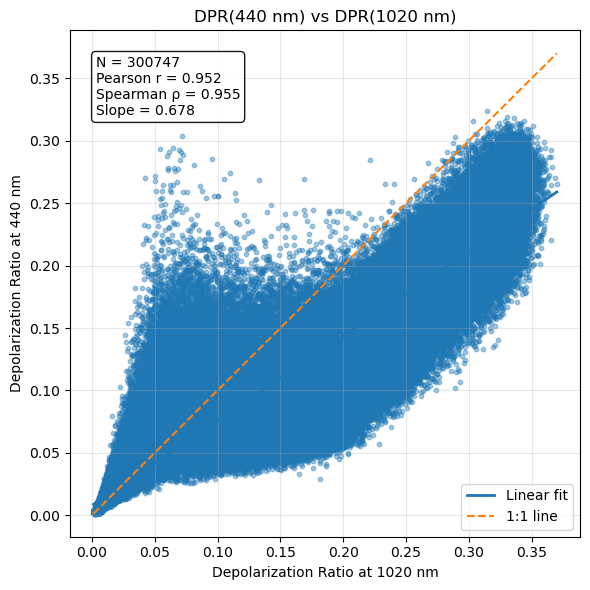

In [40]:
plot_dpr_scatter(
    dpr_1020,
    dpr_440,
    xlab="Depolarization Ratio at 1020 nm",
    ylab="Depolarization Ratio at 440 nm",
    title="DPR(440 nm) vs DPR(1020 nm)"
)


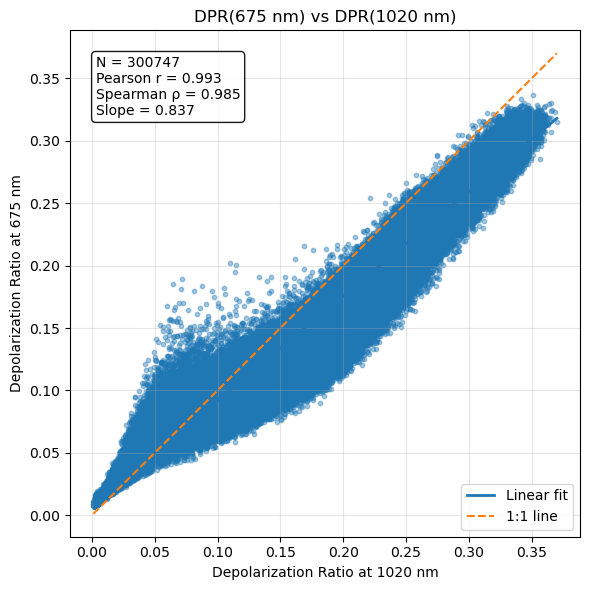

In [41]:
plot_dpr_scatter(
    dpr_1020,
    dpr_675,
    xlab="Depolarization Ratio at 1020 nm",
    ylab="Depolarization Ratio at 675 nm",
    title="DPR(675 nm) vs DPR(1020 nm)"
)


In [42]:

records = []

for site in site_list:
    data = AERONET_data_all_dict[site]

    # Extract arrays
    pldr_1020 = np.asarray(data['Depolarization_Ratio[1020nm]'], dtype=float)
    lr_675    = np.asarray(data['Lidar_Ratio[675nm]'], dtype=float)
    lr_1020   = np.asarray(data['Lidar_Ratio[1020nm]'], dtype=float)
    lr_440    = np.asarray(data['Lidar_Ratio[440nm]'], dtype=float)

    # Valid mask across all variables
    mask = (
        np.isfinite(pldr_1020) &
        np.isfinite(lr_675) &
        np.isfinite(lr_1020) &
        np.isfinite(lr_440)
    )

    pldr_1020 = pldr_1020[mask]
    lr_675    = lr_675[mask]
    lr_1020   = lr_1020[mask]
    lr_440   =  lr_440[mask]

    # Dust fraction
    Rd = dust_fraction_from_pldr(pldr_1020)

    # Select dust-dominated cases
    dust_mask = Rd > 0.89

    for v675, v1020,v440 in zip(lr_675[dust_mask], lr_1020[dust_mask],lr_440[dust_mask]):
        records.append({
            "Site": site,
            "Lidar_Ratio_675": v675,
            "Lidar_Ratio_1020": v1020,
            "Lidar_Ratio_440": v440
        })

df_lr_dust = pd.DataFrame(records)

print("Number of dust-dominated samples:", len(df_lr_dust))


Number of dust-dominated samples: 50670


## derive the DPR of dust dominant cases at three wavelengths

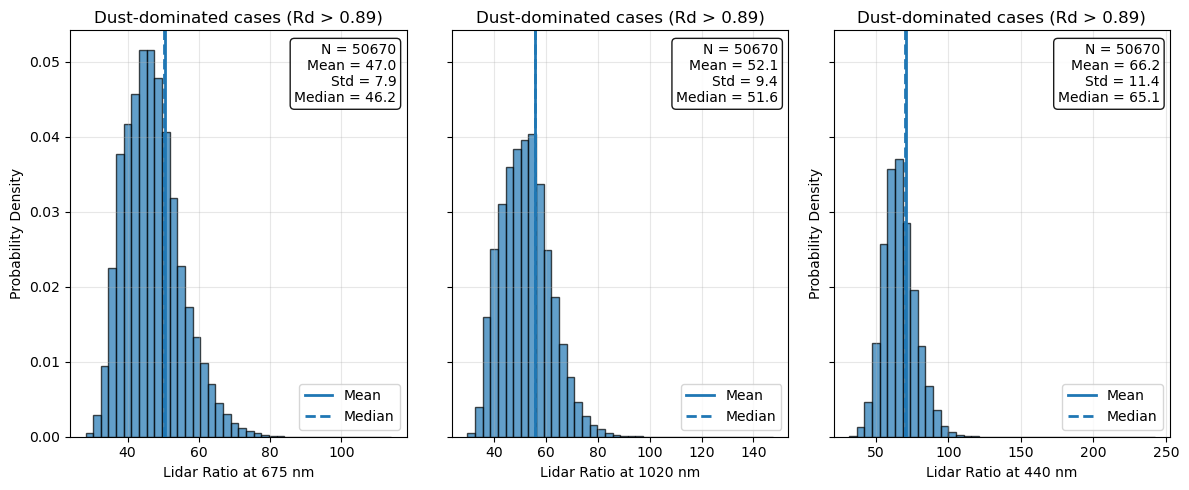

In [43]:
lr675  = df_lr_dust["Lidar_Ratio_675"].values
lr1020 = df_lr_dust["Lidar_Ratio_1020"].values
lr440 = df_lr_dust["Lidar_Ratio_440"].values

aeronet_lr_stats = {
    "675":  (np.mean(lr675),  np.std(lr675),  np.median(lr675)),
    "1020": (np.mean(lr1020), np.std(lr1020), np.median(lr1020)),
    "440": (np.mean(lr440), np.std(lr440), np.median(lr440))
}
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

# --- 675 nm ---
axes[0].hist(lr675, bins=40, density=True, alpha=0.7, edgecolor="black")
axes[0].axvline(stats["675"][0], linestyle="-",  linewidth=2, label="Mean")
axes[0].axvline(stats["675"][2], linestyle="--", linewidth=2, label="Median")

axes[0].set_xlabel("Lidar Ratio at 675 nm")
axes[0].set_ylabel("Probability Density")
axes[0].set_title("Dust-dominated cases (Rd > 0.89)")

text675 = (
    f"N = {lr675.size}\n"
    f"Mean = {aeronet_lr_stats['675'][0]:.1f}\n"
    f"Std = {aeronet_lr_stats['675'][1]:.1f}\n"
    f"Median = {aeronet_lr_stats['675'][2]:.1f}"
)
axes[0].text(
    0.97, 0.97, text675,
    transform=axes[0].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 1020 nm ---
axes[1].hist(lr1020, bins=40, density=True, alpha=0.7, edgecolor="black")
axes[1].axvline(stats["1020"][0], linestyle="-",  linewidth=2, label="Mean")
axes[1].axvline(stats["1020"][2], linestyle="--", linewidth=2, label="Median")

axes[1].set_xlabel("Lidar Ratio at 1020 nm")
axes[1].set_title("Dust-dominated cases (Rd > 0.89)")

text1020 = (
    f"N = {lr1020.size}\n"
    f"Mean = {aeronet_lr_stats['1020'][0]:.1f}\n"
    f"Std = {aeronet_lr_stats['1020'][1]:.1f}\n"
    f"Median = {aeronet_lr_stats['1020'][2]:.1f}"
)
axes[1].text(
    0.97, 0.97, text1020,
    transform=axes[1].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

axes[1].legend()
axes[1].grid(True, alpha=0.3)



# --- 440 nm ---
axes[2].hist(lr440, bins=40, density=True, alpha=0.7, edgecolor="black")
axes[2].axvline(stats["440"][0], linestyle="-",  linewidth=2, label="Mean")
axes[2].axvline(stats["440"][2], linestyle="--", linewidth=2, label="Median")

axes[2].set_xlabel("Lidar Ratio at 440 nm")
axes[2].set_ylabel("Probability Density")
axes[2].set_title("Dust-dominated cases (Rd > 0.89)")

text440 = (
    f"N = {lr440.size}\n"
    f"Mean = {aeronet_lr_stats['440'][0]:.1f}\n"
    f"Std = {aeronet_lr_stats['440'][1]:.1f}\n"
    f"Median = {aeronet_lr_stats['440'][2]:.1f}"
)
axes[2].text(
    0.97, 0.97, text440,
    transform=axes[2].transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## compare the DPR of dust and all aerosols

In [44]:

lr1020_all = []
lr1020_dust = []

for site in site_list:
    data = AERONET_data_all_dict[site]

    pldr_1020 = np.asarray(data['Depolarization_Ratio[1020nm]'], dtype=float)
    lr_1020   = np.asarray(data['Lidar_Ratio[1020nm]'], dtype=float)

    # Common validity mask
    mask = np.isfinite(pldr_1020) & np.isfinite(lr_1020)

    pldr_1020 = pldr_1020[mask]
    lr_1020   = lr_1020[mask]

    # Dust fraction
    Rd = dust_fraction_from_pldr(pldr_1020)

    # Store
    lr1020_all.append(lr_1020)
    lr1020_dust.append(lr_1020[Rd > 0.9])

lr1020_all  = np.concatenate(lr1020_all)
lr1020_dust = np.concatenate(lr1020_dust)

print("All cases:", lr1020_all.size)
print("Dust-dominant cases:", lr1020_dust.size)


All cases: 300747
Dust-dominant cases: 48572


In [45]:

def compute_stats(x):
    return {
        "N": x.size,
        "mean": np.mean(x),
        "median": np.median(x),
        "std": np.std(x)
    }

stats_all  = compute_stats(lr1020_all)
stats_dust = compute_stats(lr1020_dust)


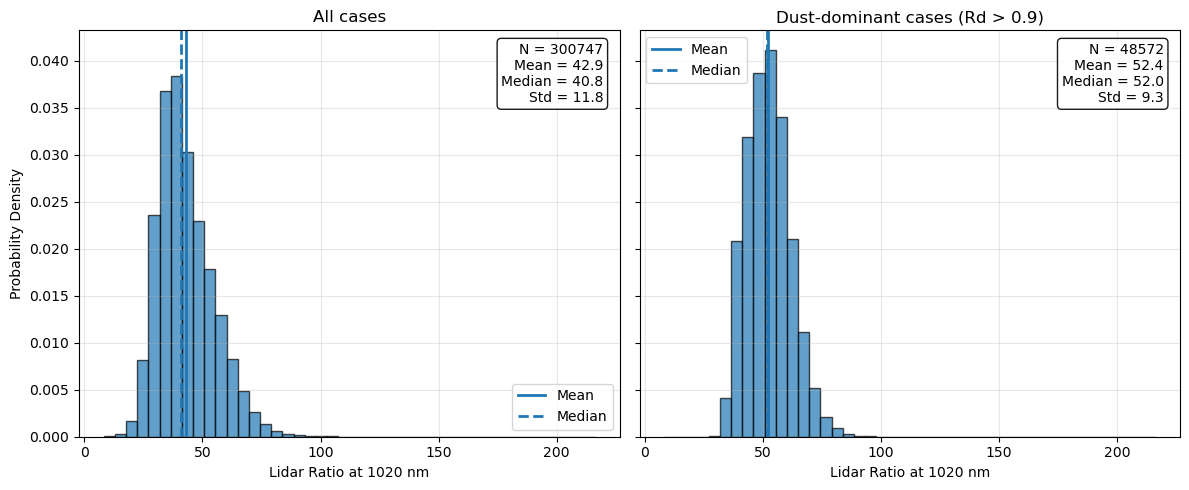

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

bins = np.linspace(
    min(lr1020_all.min(), lr1020_dust.min()),
    max(lr1020_all.max(), lr1020_dust.max()),
    45
)

# ---------- All cases ----------
axes[0].hist(
    lr1020_all,
    bins=bins,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

axes[0].axvline(stats_all["mean"],   linestyle="-",  linewidth=2, label="Mean")
axes[0].axvline(stats_all["median"], linestyle="--", linewidth=2, label="Median")

axes[0].set_title("All cases")
axes[0].set_xlabel("Lidar Ratio at 1020 nm")
axes[0].set_ylabel("Probability Density")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

text_all = (
    f"N = {stats_all['N']}\n"
    f"Mean = {stats_all['mean']:.1f}\n"
    f"Median = {stats_all['median']:.1f}\n"
    f"Std = {stats_all['std']:.1f}"
)

axes[0].text(
    0.97, 0.97,
    text_all,
    transform=axes[0].transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

# ---------- Dust-dominant cases ----------
axes[1].hist(
    lr1020_dust,
    bins=bins,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

axes[1].axvline(stats_dust["mean"],   linestyle="-",  linewidth=2, label="Mean")
axes[1].axvline(stats_dust["median"], linestyle="--", linewidth=2, label="Median")

axes[1].set_title("Dust-dominant cases (Rd > 0.9)")
axes[1].set_xlabel("Lidar Ratio at 1020 nm")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

text_dust = (
    f"N = {stats_dust['N']}\n"
    f"Mean = {stats_dust['mean']:.1f}\n"
    f"Median = {stats_dust['median']:.1f}\n"
    f"Std = {stats_dust['std']:.1f}"
)

axes[1].text(
    0.97, 0.97,
    text_dust,
    transform=axes[1].transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.tight_layout()
plt.show()


In [47]:

rd_lr1020 = []

for site in site_list:
    data = AERONET_data_all_dict[site]

    pldr_1020 = np.asarray(data['Depolarization_Ratio[1020nm]'], dtype=float)
    lr_1020   = np.asarray(data['Lidar_Ratio[1020nm]'], dtype=float)

    # Common validity mask
    mask = np.isfinite(pldr_1020) & np.isfinite(lr_1020)

    pldr_1020 = pldr_1020[mask]
    lr_1020   = lr_1020[mask]

    # Dust fraction
    Rd = dust_fraction_from_pldr(pldr_1020)

    # Product
    rd_lr1020.append(Rd * 56 / lr_1020)

rd_lr1020 = np.concatenate(rd_lr1020)

print("Total valid samples:", rd_lr1020.size)
mean_val   = np.mean(rd_lr1020)
median_val = np.median(rd_lr1020)
std_val    = np.std(rd_lr1020)


Total valid samples: 300747


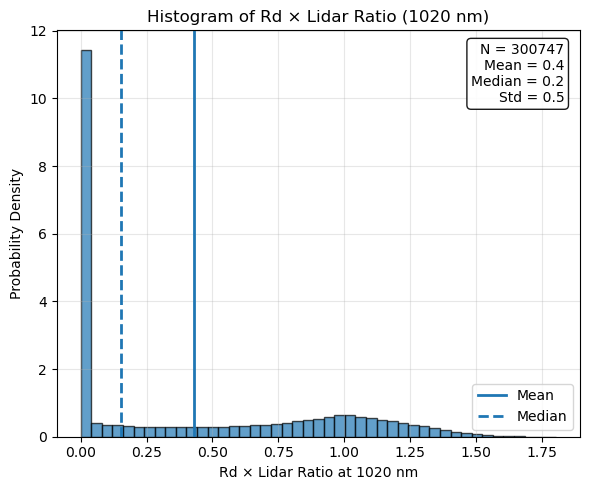

In [48]:

plt.figure(figsize=(6, 5))

plt.hist(
    rd_lr1020,
    bins=45,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(mean_val, linestyle="-",  linewidth=2, label="Mean")
plt.axvline(median_val, linestyle="--", linewidth=2, label="Median")

plt.xlabel("Rd × Lidar Ratio at 1020 nm")
plt.ylabel("Probability Density")
plt.title("Histogram of Rd × Lidar Ratio (1020 nm)")

textstr = (
    f"N = {rd_lr1020.size}\n"
    f"Mean = {mean_val:.1f}\n"
    f"Median = {median_val:.1f}\n"
    f"Std = {std_val:.1f}"
)

plt.text(
    0.97, 0.97,
    textstr,
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Use dust DPR to derive dust AOD from AERONET products

In [49]:
site_list = AERONET_data_all_dict.keys()

Total valid samples: 300747


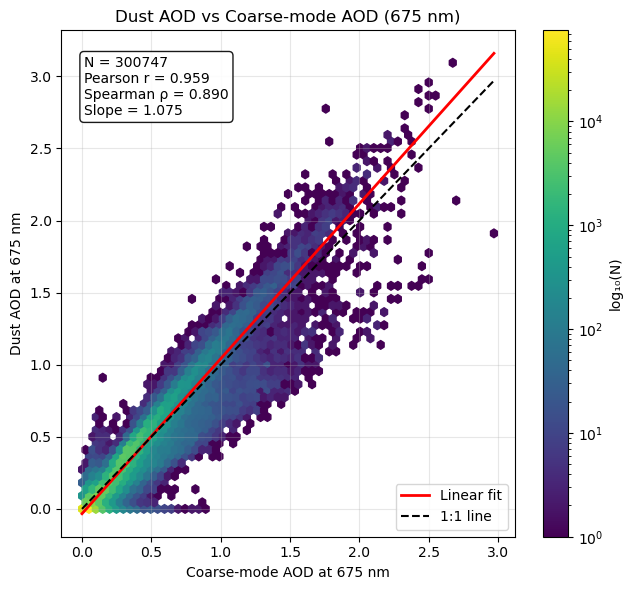

In [51]:

from scipy.stats import pearsonr, spearmanr

# =========================
# Configuration
# =========================
# WL = 440            # wavelength in nm, change to 440, 675, 870, etc.
# LR_DUST = 66.0       # constant lidar ratio for dust

WL = 675            # wavelength in nm, change to 440, 675, 870, etc.
WL_char = '675'
LR_DUST = aeronet_lr_stats[WL_char][0]      # constant lidar ratio for dust




# Build column-name templates
col_pldr = f"Depolarization_Ratio[{WL}nm]"
col_lr   = f"Lidar_Ratio[{WL}nm]"
col_aod  = f"AOD_Coincident_Input[{WL}nm]"
col_ext_c = f"AOD_Extinction-Coarse[{WL}nm]"
col_ext_t = f"AOD_Extinction-Total[{WL}nm]"

records = []

# =========================
# Loop over sites
# =========================
for site in site_list:
    data = AERONET_data_all_dict[site]

    # --- Inputs ---
    pldr = np.asarray(data[col_pldr], dtype=float)
    lr   = np.asarray(data[col_lr], dtype=float)
    aod  = np.asarray(data[col_aod], dtype=float)

    aod_ext_coarse = np.asarray(data[col_ext_c], dtype=float)
    aod_ext_total  = np.asarray(data[col_ext_t], dtype=float)

    # --- Common validity mask ---
    m = (
        np.isfinite(pldr) &
        np.isfinite(lr) &
        np.isfinite(aod) &
        np.isfinite(aod_ext_coarse) &
        np.isfinite(aod_ext_total) &
        (lr > 0.0) &
        (aod_ext_total > 0.0) &
        (aod >= 0.0)
    )

    pldr = pldr[m]
    lr   = lr[m]
    aod  = aod[m]
    aod_ext_coarse = aod_ext_coarse[m]
    aod_ext_total  = aod_ext_total[m]

    # --- Dust fraction from depolarization ---
    Rd = dust_fraction_from_pldr(pldr)

    dust_fraction = Rd * LR_DUST / lr
    dust_fraction = np.clip(dust_fraction, 0.0, 1.0)

    dust_aod = aod * dust_fraction

    # --- Coarse-mode AOD from CMF ---
    CMF = aod_ext_coarse / aod_ext_total
    CMF = np.clip(CMF, 0.0, 1.0)

    coarse_aod = CMF * aod

    records.append(pd.DataFrame({
        "Site": site,
        f"dust_AOD_{WL}": dust_aod,
        f"coarse_AOD_{WL}": coarse_aod,
        "dust_fraction": dust_fraction,
        f"CMF_{WL}": CMF
    }))

# =========================
# Combine all sites
# =========================
df_compare = pd.concat(records, ignore_index=True)
print("Total valid samples:", len(df_compare))

# =========================
# Correlation and plot
# =========================
x = df_compare[f"coarse_AOD_{WL}"].values
y = df_compare[f"dust_AOD_{WL}"].values

# Remove any remaining non-finite values
m = np.isfinite(x) & np.isfinite(y)
x = x[m]
y = y[m]

# Correlations
r_p, _ = pearsonr(x, y)
r_s, _ = spearmanr(x, y)

coef = np.polyfit(x, y, 1)

plt.figure(figsize=(6.5, 6))

# --- Density heat map ---
hb = plt.hexbin(
    x, y,
    gridsize=60,
    mincnt=1,
    bins="log",      # log-scaled density
    cmap="viridis"
)

cb = plt.colorbar(hb)
cb.set_label("log₁₀(N)")

# --- Fit and 1:1 line ---
xfit = np.linspace(0, x.max(), 300)
yfit = coef[0] * xfit + coef[1]

plt.plot(xfit, yfit, color="red", linewidth=2, label="Linear fit")
plt.plot(xfit, xfit, linestyle="--", color="black", linewidth=1.5, label="1:1 line")

plt.xlabel(f"Coarse-mode AOD at {WL} nm")
plt.ylabel(f"Dust AOD at {WL} nm")
plt.title(f"Dust AOD vs Coarse-mode AOD ({WL} nm)")

# --- Annotation ---
textstr = (
    f"N = {len(x)}\n"
    f"Pearson r = {r_p:.3f}\n"
    f"Spearman ρ = {r_s:.3f}\n"
    f"Slope = {coef[0]:.3f}"
)

plt.text(
    0.05, 0.95,
    textstr,
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [52]:
COARSE_THR = 0.5
DUST_THR   = 0.05

mask_anom = (
    (df_compare[f"coarse_AOD_{WL}"] > COARSE_THR) &
    (df_compare[f"dust_AOD_{WL}"] < DUST_THR)
)

df_anom = df_compare.loc[mask_anom].copy()

pd.set_option("display.max_rows", None)
print(df_anom)


                    Site  dust_AOD_675  coarse_AOD_675  dust_fraction  \
12654        Banizoumbou      0.000000        0.543660       0.000000   
20471        Ouagadougou      0.000000        0.528512       0.000000   
34521             Ilorin      0.000000        0.525117       0.000000   
35830             Ilorin      0.000000        0.683622       0.000000   
35873             Ilorin      0.000000        0.734381       0.000000   
36381             Ilorin      0.000000        0.531658       0.000000   
36734             Ilorin      0.000000        0.514998       0.000000   
37378             Ilorin      0.000000        0.616474       0.000000   
38595             Ilorin      0.000000        0.642229       0.000000   
65389             Kanpur      0.000000        0.775750       0.000000   
66378             Kanpur      0.000000        0.647947       0.000000   
68863             Kanpur      0.000000        0.555196       0.000000   
72947             Kanpur      0.000000        0.797

In [53]:

# =========================
# Configuration
# =========================
WL = 675
WL_char = '675'
LR_DUST = aeronet_lr_stats[WL_char][0]

col_pldr  = f"Depolarization_Ratio[{WL}nm]"
col_lr    = f"Lidar_Ratio[{WL}nm]"
col_aod   = f"AOD_Coincident_Input[{WL}nm]"
col_ext_c = f"AOD_Extinction-Coarse[{WL}nm]"
col_ext_t = f"AOD_Extinction-Total[{WL}nm]"

# (optional) track time if present in your dict
col_date = "Date(dd:mm:yyyy)"
col_time = "Time(hh:mm:ss)"

records = []

# =========================
# Loop over sites (WITH TRACKING)
# =========================
for site in site_list:
    data = AERONET_data_all_dict[site]

    # --- Inputs ---
    pldr = np.asarray(data[col_pldr], dtype=float)
    lr   = np.asarray(data[col_lr], dtype=float)
    aod  = np.asarray(data[col_aod], dtype=float)

    aod_ext_coarse = np.asarray(data[col_ext_c], dtype=float)
    aod_ext_total  = np.asarray(data[col_ext_t], dtype=float)

    # original indices BEFORE masking
    orig_idx = np.arange(len(pldr))

    # --- Common validity mask ---
    m = (
        np.isfinite(pldr) &
        np.isfinite(lr) &
        np.isfinite(aod) &
        np.isfinite(aod_ext_coarse) &
        np.isfinite(aod_ext_total) &
        (lr > 0.0) &
        (aod_ext_total > 0.0) &
        (aod >= 0.0)
    )

    # apply mask
    pldr = pldr[m]
    lr   = lr[m]
    aod  = aod[m]
    aod_ext_coarse = aod_ext_coarse[m]
    aod_ext_total  = aod_ext_total[m]
    orig_idx = orig_idx[m]  # <. this is the key tracking vector

    # --- Dust fraction from depolarization ---
    Rd = dust_fraction_from_pldr(pldr)

    dust_fraction = Rd * LR_DUST / lr
    dust_fraction = np.clip(dust_fraction, 0.0, 1.0)

    dust_aod = aod * dust_fraction

    # --- Coarse-mode AOD from CMF ---
    CMF = aod_ext_coarse / aod_ext_total
    CMF = np.clip(CMF, 0.0, 1.0)

    coarse_aod = CMF * aod

    # (optional) grab date/time aligned with orig_idx
    has_dt = (col_date in data) and (col_time in data)
    if has_dt:
        date_arr = np.asarray(data[col_date], dtype=object)[orig_idx]
        time_arr = np.asarray(data[col_time], dtype=object)[orig_idx]
    else:
        date_arr = np.full_like(orig_idx, None, dtype=object)
        time_arr = np.full_like(orig_idx, None, dtype=object)

    records.append(pd.DataFrame({
        "Site": site,
        "orig_index": orig_idx,               # <. index into AERONET_data_all_dict[site][var]
        "row_in_site_valid": np.arange(len(orig_idx)),  # <. index within the masked valid arrays
        f"dust_AOD_{WL}": dust_aod,
        f"coarse_AOD_{WL}": coarse_aod,
        "dust_fraction": dust_fraction,
        f"CMF_{WL}": CMF,
        "Date": date_arr,
        "Time": time_arr,
    }))

# =========================
# Combine all sites
# =========================
df_compare = pd.concat(records, ignore_index=True)
print("Total valid samples:", len(df_compare))

# =========================
# Select anomalous cases (example)
# =========================
COARSE_THR = 0.1
DUST_THR   = 0.01

mask_anom = (
    (df_compare[f"coarse_AOD_{WL}"] > COARSE_THR) &
    (df_compare[f"dust_AOD_{WL}"]   < DUST_THR)
)

df_anom = df_compare.loc[mask_anom].copy()

# 1) Full list: show all rows or save
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
#print(df_anom)

# better. save it
df_anom.to_csv(f"anomalous_cases_WL{WL}.csv", index=False)
print("Saved:", f"anomalous_cases_WL{WL}.csv")

# =========================
# 2) Pull other retrievals (SSA example) for anomalous cases
# =========================
ssa_col = f"Single_Scattering_Albedo[{WL}nm]"  # or try [440nm],[675nm],[870nm],[1020nm]

ssa_vals = []
for _, r in df_anom.iterrows():
    site = r["Site"]
    i0   = int(r["orig_index"])  # <. THIS maps back to the original dict arrays
    if ssa_col in AERONET_data_all_dict[site]:
        v = AERONET_data_all_dict[site][ssa_col][i0]
    else:
        v = np.nan
    ssa_vals.append(v)

df_anom[ssa_col] = pd.to_numeric(ssa_vals, errors="coerce")
print(df_anom[["Site","orig_index", f"coarse_AOD_{WL}", f"dust_AOD_{WL}", ssa_col]].head(20))


Total valid samples: 300747
Saved: anomalous_cases_WL675.csv
               Site  orig_index  coarse_AOD_675  dust_AOD_675  \
3            Cuiaba          75        0.101797      0.000684   
846           Dakar        1287        0.106006      0.000000   
1059          Dakar        1676        0.116947      0.000000   
1060          Dakar        1681        0.143384      0.000000   
1061          Dakar        1682        0.133079      0.000000   
1516          Dakar        2555        0.113018      0.000000   
1517          Dakar        2556        0.107371      0.000000   
4062          Dakar        7646        0.365385      0.000000   
5057  Alta_Floresta         342        0.107408      0.000000   
5117  Alta_Floresta         437        0.141014      0.000000   
5122  Alta_Floresta         442        0.189389      0.000000   
5319  Alta_Floresta         941        0.187288      0.000000   
5320  Alta_Floresta         942        0.105068      0.000000   
5325  Alta_Floresta         9

In [54]:


# Wavelengths to examine
SSA_WLS = [440, 675, 870, 1020]

# Build SSA table for anomalous cases
ssa_records = []

for _, r in df_anom.iterrows():
    site = r["Site"]
    idx  = int(r["orig_index"])

    rec = {
        "Site": site,
        "orig_index": idx
    }

    for wl in SSA_WLS:
        col = f"Single_Scattering_Albedo[{wl}nm]"
        if col in AERONET_data_all_dict[site]:
            v = AERONET_data_all_dict[site][col][idx]
        else:
            v = np.nan
        rec[f"SSA_{wl}"] = v

    ssa_records.append(rec)

df_ssa_anom = pd.DataFrame(ssa_records)

# Convert to numeric and drop rows where all SSA are missing
for wl in SSA_WLS:
    df_ssa_anom[f"SSA_{wl}"] = pd.to_numeric(df_ssa_anom[f"SSA_{wl}"], errors="coerce")

df_ssa_anom = df_ssa_anom.dropna(
    subset=[f"SSA_{wl}" for wl in SSA_WLS],
    how="all"
)

print("Anomalous samples with SSA:", len(df_ssa_anom))


Anomalous samples with SSA: 8751


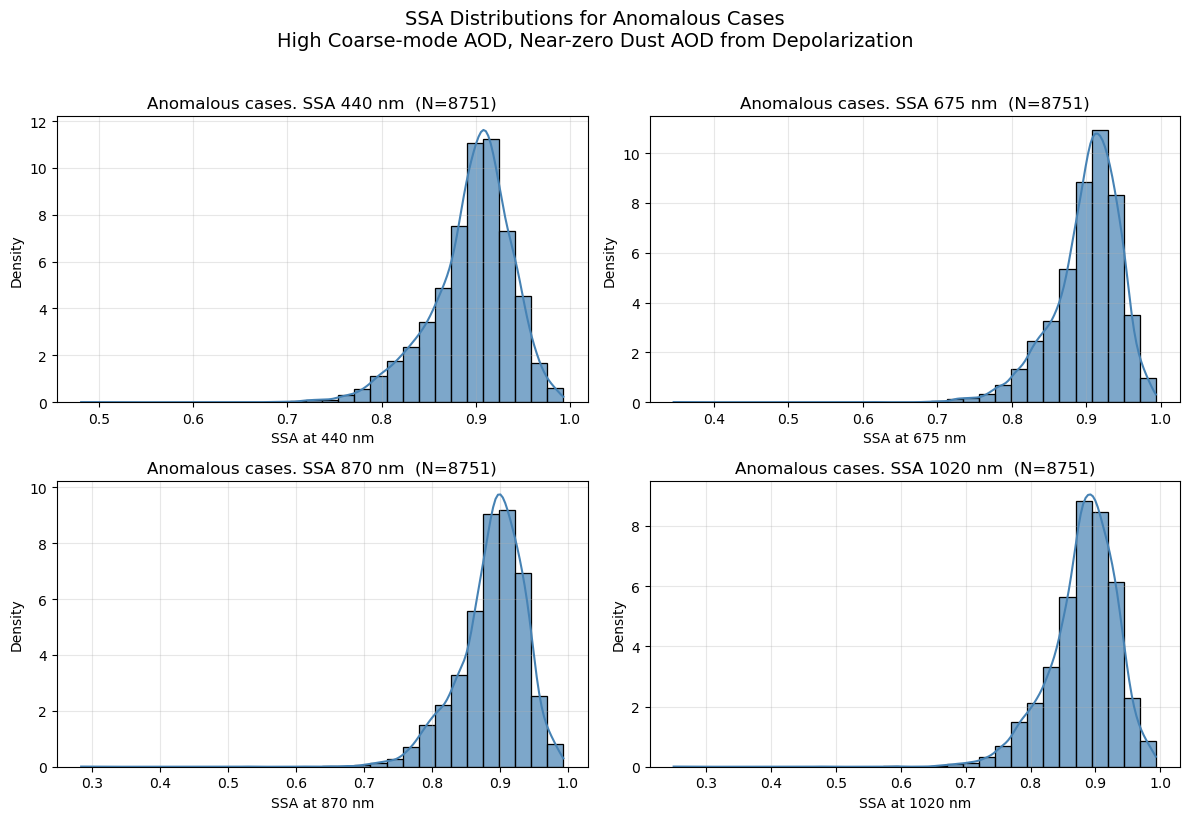

In [55]:
plt.figure(figsize=(12, 8))

for i, wl in enumerate(SSA_WLS, 1):
    ax = plt.subplot(2, 2, i)

    data = df_ssa_anom[f"SSA_{wl}"].dropna().values
    if len(data) == 0:
        continue

    sns.histplot(
        data,
        bins=30,
        stat="density",
        kde=True,
        color="steelblue",
        alpha=0.7,
        ax=ax
    )

    ax.set_xlabel(f"SSA at {wl} nm")
    ax.set_ylabel("Density")
    ax.set_title(f"Anomalous cases. SSA {wl} nm  (N={len(data)})")
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "SSA Distributions for Anomalous Cases\n"
    "High Coarse-mode AOD, Near-zero Dust AOD from Depolarization",
    y=1.02,
    fontsize=14
)

plt.tight_layout()
plt.show()


In [56]:
DUST_DOM_THR = 0.9

df_dustdom = df_compare[df_compare["dust_fraction"] > DUST_DOM_THR].copy()

print("Number of dust-dominant cases:", len(df_dustdom))


Number of dust-dominant cases: 37464


In [57]:
SSA_WLS = [440, 675, 870, 1020]

def extract_ssa(df_subset):
    records = []
    for _, r in df_subset.iterrows():
        site = r["Site"]
        idx  = int(r["orig_index"])

        rec = {"Site": site}
        for wl in SSA_WLS:
            col = f"Single_Scattering_Albedo[{wl}nm]"
            if col in AERONET_data_all_dict[site]:
                rec[f"SSA_{wl}"] = AERONET_data_all_dict[site][col][idx]
            else:
                rec[f"SSA_{wl}"] = np.nan

        records.append(rec)

    df = pd.DataFrame(records)
    for wl in SSA_WLS:
        df[f"SSA_{wl}"] = pd.to_numeric(df[f"SSA_{wl}"], errors="coerce")
    return df

df_ssa_anom    = extract_ssa(df_anom)
df_ssa_dustdom = extract_ssa(df_dustdom)

print("SSA samples (anomalous):", len(df_ssa_anom))
print("SSA samples (dust-dominant):", len(df_ssa_dustdom))


SSA samples (anomalous): 8751
SSA samples (dust-dominant): 37464


In [58]:

def plot_median_with_quantile_band(
    x,
    y_ensemble,
    q_low=0.25,
    q_high=0.75,
    ax=None,
    label_median="Median",
    band_label=None,
    alpha=0.25,
    nan_policy="omit",  # "omit" or "propagate"
    **line_kwargs,
):
    """
    Plot median curve + shaded quantile band.

    Parameters
    ----------
    x : (N,) array-like
        X-axis values.
    y_ensemble : (M, N) or (N, M) array-like
        Ensemble values (M members across N x-points). If shape is (N, M),
        it will be transposed automatically.
    q_low, q_high : float
        Quantiles in [0,1] for the shaded band.
    ax : matplotlib Axes, optional
        Existing axes to draw on.
    label_median : str
        Legend label for the median line.
    band_label : str or None
        Legend label for the shaded band (None = no band legend entry).
    alpha : float
        Transparency for the shaded band.
    nan_policy : {"omit","propagate"}
        "omit" uses nanquantile/nanmedian; "propagate" uses quantile/median.
    line_kwargs : dict
        Extra kwargs forwarded to ax.plot for the median line (e.g. lw=2, ls="--").

    Returns
    -------
    ax, median, qlo, qhi : (Axes, ndarray, ndarray, ndarray)
    """
    x = np.asarray(x)

    Y = np.asarray(y_ensemble)
    if Y.ndim != 2:
        raise ValueError("y_ensemble must be 2D (members x N).")

    # Ensure shape is (members, N)
    if Y.shape[1] != x.size and Y.shape[0] == x.size:
        Y = Y.T
    if Y.shape[1] != x.size:
        raise ValueError(f"Shape mismatch: x has length {x.size}, y_ensemble has shape {Y.shape}.")

    if nan_policy == "omit":
        median = np.nanmedian(Y, axis=0)
        qlo = np.nanquantile(Y, q_low, axis=0)
        qhi = np.nanquantile(Y, q_high, axis=0)
    elif nan_policy == "propagate":
        median = np.median(Y, axis=0)
        qlo = np.quantile(Y, q_low, axis=0)
        qhi = np.quantile(Y, q_high, axis=0)
    else:
        raise ValueError('nan_policy must be "omit" or "propagate".')

    if ax is None:
        fig, ax = plt.subplots()

    # Median line
    (line,) = ax.plot(x, median, label=label_median, **line_kwargs)

    # Quantile band (match the median line color)
    ax.fill_between(
        x, qlo, qhi,
        color=line.get_color(),
        alpha=alpha,
        label=band_label
    )

    return ax, median, qlo, qhi


# --- Example usage ---
# x = np.arange(100)
# y_ens = np.random.randn(50, 100).cumsum(axis=1)  # 50 members
# ax, med, q25, q75 = plot_median_with_quantile_band(
#     x, y_ens, q_low=0.1, q_high=0.9, lw=2, band_label="10–90%"
# )
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.legend()
# plt.show()


In [59]:

SSA_WLS = np.array([440, 675, 870, 1020])

def build_ssa_matrix(df, wls):
    """
    Return SSA matrix with shape (n_samples, n_wavelengths)
    Rows with any NaN acrossN across wavelengths are dropped.
    """
    cols = [f"SSA_{wl}" for wl in wls]
    Y = df[cols].to_numpy(dtype=float)

    # drop rows with any missing wavelength
    mask = np.all(np.isfinite(Y), axis=1)
    return Y[mask]
Y_anom    = build_ssa_matrix(df_ssa_anom, SSA_WLS)
Y_dust   = build_ssa_matrix(df_ssa_dustdom, SSA_WLS)

print("Anomalous spectra:", Y_anom.shape)
print("Dust-dominant spectra:", Y_dust.shape)


Anomalous spectra: (8751, 4)
Dust-dominant spectra: (37464, 4)


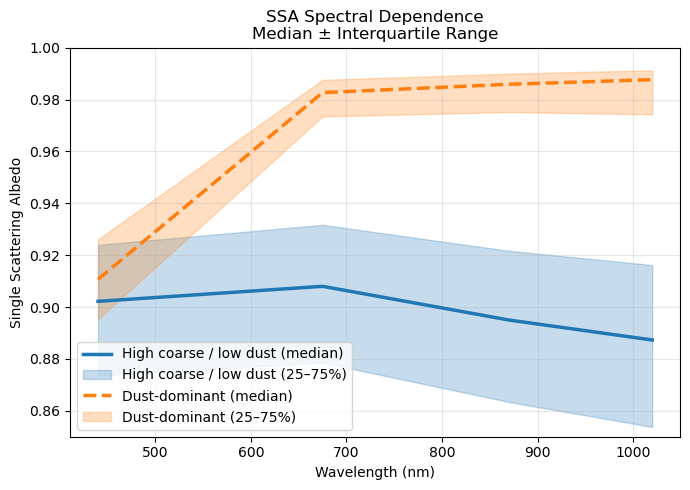

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))

# Anomalous: high coarse / low dust
plot_median_with_quantile_band(
    SSA_WLS,
    Y_anom,
    q_low=0.25,
    q_high=0.75,
    ax=ax,
    label_median="High coarse / low dust (median)",
    band_label="High coarse / low dust (25–75%)",
    lw=2.5
)

# Dust-dominant
plot_median_with_quantile_band(
    SSA_WLS,
    Y_dust,
    q_low=0.25,
    q_high=0.75,
    ax=ax,
    label_median="Dust-dominant (median)",
    band_label="Dust-dominant (25–75%)",
    lw=2.5,
    linestyle="--"
)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Single Scattering Albedo")
ax.set_ylim(0.85, 1.0)
ax.set_title("SSA Spectral Dependence\nMedian ± Interquartile Range")

ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## AERONET and MODIS collocation (this part handled using external code)

In [47]:
# SHORT_NAME = 'MOD04_L2'
# OVERPASS_FINAL_FILE = f"AERONET_SDA_L1.5_allsites_{SHORT_NAME}_overpass_info_final.pkl"
# with open(OVERPASS_FINAL_FILE,'rb') as f:
#     MODIS_data_dict = pickle.load(f)

In [48]:

# site = "GSFC"

# dates = AERONET_data_all_dict[site]["Date(dd:mm:yyyy)"]
# times = AERONET_data_all_dict[site]["Time(hh:mm:ss)"]

# # Combine date and time strings
# dt_strings = [f"{d} {t}" for d, t in zip(dates, times)]

# # Convert to pandas datetime
# dt = pd.to_datetime(
#     dt_strings,
#     format="%d:%m:%Y %H:%M:%S",
#     errors="coerce"   # invalid entries become NaT
# )

# print(dt[:5])

DatetimeIndex(['1993-05-27 10:57:41', '1993-05-27 12:34:48',
               '1993-06-17 12:32:00', '1993-06-22 21:48:56',
               '1993-06-23 12:33:00'],
              dtype='datetime64[ns]', freq=None)


In [79]:

# def aeronet_within_window_for_modis(
#     site: str,
#     AERONET_data_all_dict: dict,
#     MODIS_data_dict: dict,
#     window_minutes: int = 30,
#     aeronet_date_key: str = "Date(dd:mm:yyyy)",
#     aeronet_time_key: str = "Time(hh:mm:ss)",
#     modis_time_key: str = "MODIS_mean_time",
# ):
#     """
#     For each MODIS overpass datetime, find AERONET retrievals within ±window_minutes.

#     Returns
#     -------
#     out : dict with
#       - modis_times: DatetimeIndex (sorted)
#       - aeronet_times: DatetimeIndex (sorted, valid only)
#       - matches_idx: list[list[int]]            original AERONET indices per MODIS time
#       - matches_dt:  list[list[pd.Timestamp]]  AERONET times per MODIS time
#       - nearest_idx: np.ndarray (n_modis,)     original AERONET index of closest match or -1
#       - nearest_dt:  np.ndarray (n_modis,)     closest AERONET time or NaT
#       - nearest_abs_minutes: np.ndarray (n_modis,) abs time diff in minutes or nan
#     """

#     # ---------- AERONET times (keep original indices) ----------
#     dates = AERONET_data_all_dict[site].get(aeronet_date_key, [])
#     times = AERONET_data_all_dict[site].get(aeronet_time_key, [])

#     aeronet_dt_raw = pd.to_datetime(
#         [f"{d} {t}" for d, t in zip(dates, times)],
#         format="%d:%m:%Y %H:%M:%S",
#         errors="coerce",
#     )

#     valid_mask = ~pd.isna(aeronet_dt_raw)
#     aeronet_orig_idx = np.where(valid_mask)[0]  # original positions in the input arrays/lists
#     aeronet_dt_valid = pd.DatetimeIndex(aeronet_dt_raw[valid_mask])

#     # Build a sorted table so "sorted position" maps back to original index
#     aeronet_tbl = (
#         pd.DataFrame({"aeronet_time": aeronet_dt_valid.to_numpy(), "orig_index": aeronet_orig_idx})
#         .sort_values("aeronet_time")
#         .reset_index(drop=True)
#     )

#     aeronet_ts = pd.DatetimeIndex(aeronet_tbl["aeronet_time"].to_numpy())
#     aeronet_values = aeronet_ts.values  # numpy datetime64 for searchsorted

#     # ---------- MODIS times ----------
#     modis_raw = MODIS_data_dict[site].get(modis_time_key, [])
#     modis_ts = pd.to_datetime(pd.Series(modis_raw), errors="coerce").dropna()
#     modis_ts = pd.DatetimeIndex(modis_ts.to_numpy()).sort_values()

#     # ---------- Edge cases ----------
#     n = int(np.size(modis_ts))
#     if (len(aeronet_ts) == 0) or (n == 0):
#         return dict(
#             modis_times=modis_ts,
#             aeronet_times=aeronet_ts,
#             matches_idx=[[] for _ in range(n)],
#             matches_dt=[[] for _ in range(n)],
#             nearest_idx=np.full(n, -1, dtype=int),
#             nearest_dt=np.full(n, np.datetime64("NaT"), dtype="datetime64[ns]"),
#             nearest_abs_minutes=np.full(n, np.nan, dtype=float),
#         )

#     # ---------- Window search ----------
#     win = np.timedelta64(int(window_minutes), "m")

#     matches_idx = [[] for _ in range(n)]
#     matches_dt  = [[] for _ in range(n)]
#     nearest_idx = np.full(n, -1, dtype=int)
#     nearest_dt  = np.full(n, np.datetime64("NaT"), dtype="datetime64[ns]")
#     nearest_abs_minutes = np.full(n, np.nan, dtype=float)

#     for i, mt in enumerate(modis_ts):
#         mt64 = mt.to_datetime64()

#         left = np.searchsorted(aeronet_values, mt64 - win, side="left")
#         right = np.searchsorted(aeronet_values, mt64 + win, side="right")

#         if right <= left:
#             # no matches in window
#             continue

#         # times in the window (already sorted)
#         m_times = aeronet_ts[left:right]
#         matches_dt[i] = list(m_times)

#         # corresponding original indices
#         m_orig = aeronet_tbl.loc[left:right - 1, "orig_index"].to_numpy(dtype=int)
#         matches_idx[i] = list(m_orig)

#         # nearest within the window
#         deltas_min = np.abs((m_times - mt) / pd.Timedelta(minutes=1)).to_numpy(dtype=float)
#         j = int(np.argmin(deltas_min))
#         nearest_idx[i] = int(m_orig[j])
#         nearest_dt[i] = m_times[j].to_datetime64()
#         nearest_abs_minutes[i] = float(deltas_min[j])

#     return dict(
#         modis_times=modis_ts,
#         aeronet_times=aeronet_ts,
#         matches_idx=matches_idx,
#         matches_dt=matches_dt,
#         nearest_idx=nearest_idx,
#         nearest_dt=nearest_dt,
#         nearest_abs_minutes=nearest_abs_minutes,
#     )


In [85]:
# site = "Capo_Verde"
# out = aeronet_within_window_for_modis(site, AERONET_data_all_dict, MODIS_data_dict, window_minutes=30)
# sum(len(x) > 0 for x in out["matches_idx"]), len(out["modis_times"])


(17, 8993)

In [89]:
# matched_modis_idx = [i for i, lst in enumerate(out["matches_idx"]) if len(lst) > 0]

# for i in matched_modis_idx:
#     print(
#         "MODIS:", out["modis_times"][i],
#         "| nearest AERONET:", pd.Timestamp(out["nearest_dt"][i]),
#         "| Δmin:", out["nearest_abs_minutes"][i],
#         "| aeronet orig idx:", out["nearest_idx"][i],
#     )

MODIS: 2014-01-06 11:37:30 | nearest AERONET: 2014-01-06 11:10:13 | Δmin: 27.283333333333335 | aeronet orig idx: 4062
MODIS: 2022-01-05 11:27:30 | nearest AERONET: 2022-01-05 11:03:06 | Δmin: 24.4 | aeronet orig idx: 6125
MODIS: 2022-12-14 11:17:30 | nearest AERONET: 2022-12-14 10:52:31 | Δmin: 24.983333333333334 | aeronet orig idx: 6507
MODIS: 2022-12-21 11:07:30 | nearest AERONET: 2022-12-21 10:56:28 | Δmin: 11.033333333333333 | aeronet orig idx: 6540
MODIS: 2022-12-21 11:12:30 | nearest AERONET: 2022-12-21 10:56:28 | Δmin: 16.033333333333335 | aeronet orig idx: 6540
MODIS: 2022-12-31 11:27:30 | nearest AERONET: 2022-12-31 11:00:59 | Δmin: 26.516666666666666 | aeronet orig idx: 6578
MODIS: 2023-01-02 11:12:30 | nearest AERONET: 2023-01-02 10:43:46 | Δmin: 28.733333333333334 | aeronet orig idx: 6583
MODIS: 2023-01-14 11:17:30 | nearest AERONET: 2023-01-14 11:02:18 | Δmin: 15.2 | aeronet orig idx: 6615
MODIS: 2023-02-19 11:22:30 | nearest AERONET: 2023-02-19 10:53:32 | Δmin: 28.9666666

In [91]:
# AERONET_data_all_dict[site]['Date(dd:mm:yyyy)'][out["nearest_idx"][matched_modis_idx]]

array(['06:01:2014', '05:01:2022', '14:12:2022', '21:12:2022',
       '21:12:2022', '31:12:2022', '02:01:2023', '14:01:2023',
       '19:02:2023', '09:12:2023', '11:12:2023', '28:12:2023',
       '02:01:2024', '05:01:2024', '07:01:2024', '12:01:2024',
       '24:01:2024'], dtype=object)

### combine collocation files to single dict

In [75]:
# %cd  ~/Research

/home/ec2-user/Research


In [95]:
# # directory
# from pathlib import Path

# MODIS_name = "MYD04"
# data_dir = Path("AERONET_MODIS_DB_collocation_files")
# final_file = Path(f"AERONET_{MODIS_name}_L2_collocation_with_SDA_data.pkl")

# if final_file.exists():
#     print(f"Final file already exists: {final_file}")
# else:
#     print("Final file not found... combining per-site pickles")

#     pattern = str(data_dir / f"AERONET_{MODIS_name}_L2_collocation_*.pkl")
#     file_list = sorted(glob.glob(pattern))

#     if len(file_list) == 0:
#         raise FileNotFoundError(f"No files matched pattern: {pattern}")

#     all_data_dict = {}

#     for site_file in file_list:
#         site_file = Path(site_file)
#         site_name = (
#             site_file.stem
#             .replace(f"AERONET_{MODIS_name}_L2_collocation_", "")
#         )

#         with open(site_file, "rb") as f:
#             site_dict = pickle.load(f)

#         all_data_dict[site_name] = site_dict

#     with open(final_file, "wb") as f:
#         pickle.dump(all_data_dict, f, protocol=pickle.HIGHEST_PROTOCOL)

#     print(f"Saved combined dict with {len(all_data_dict)} sites -> {final_file}")
    

# #show results
# # for f, s in zip(file_list, site_names):
# #     print(s, "->", f)

Final file already exists: AERONET_MYD04_L2_collocation_with_SDA_data.pkl


## Analysis of collocated AERONET-MODIS observations

In [108]:
MODIS_name = 'MOD04'
data_dir = "AERONET_MODIS_DB_collocation_files"
pattern = os.path.join(data_dir, f"AERONET_{MODIS_name}_L2_collocation_*.pkl")
collocated_files = sorted(glob.glob(pattern))
AERONET_SDA_L1p5_path = 'AERONET_SDA_v1.5_allsites/'
AERONET_SDA_L1p5_prefix='19930101_20260103'
Collocation_data_with_SDA = f'AERONET_{MODIS_name}_L2_collocation_with_SDA_data.pkl'

def nearest_index_within_minutes(dt_sorted, orig_idx_sorted, target_str, minutes=5):
    target = np.datetime64(pd.to_datetime(target_str, format="%d:%m:%Y %H:%M:%S"))
    tol = np.timedelta64(minutes, "m")

    i = np.searchsorted(dt_sorted, target)

    # candidate positions in the sorted array
    cand_pos = []
    if i > 0:
        cand_pos.append(i - 1)
    if i < dt_sorted.size:
        cand_pos.append(i)

    if not cand_pos:
        return None, None, None

    cand_pos = np.array(cand_pos, dtype=int)
    diffs = np.abs(dt_sorted[cand_pos] - target)
    j = cand_pos[np.argmin(diffs)]

    if diffs.min() <= tol:
        original_index = int(orig_idx_sorted[j])
        nearest_time = dt_sorted[j]
        delta_minutes = float(diffs.min() / np.timedelta64(1, "m"))
        return original_index, nearest_time, delta_minutes

    return None, None, None

In [109]:
collocated_files[0]

'AERONET_MODIS_DB_collocation_files/AERONET_MOD04_L2_collocation_AAQ10_MY_Banting.pkl'

In [110]:

if os.path.exists(Collocation_data_with_SDA):
    with open(Collocation_data_with_SDA,'rb') as f:
            AERONET_MODIS_collocated_data_dic=pickle.load(f)
else:
    AERONET_MODIS_collocated_data_dic = {}
    AERONET_SDA_collocated_data_dic = {}
    for collocated_file in collocated_files:
        base = os.path.basename(collocated_file)
        site_name = base.replace(".pkl", "").split("_collocation_")[-1]
        #print(site_name)
        AERONET_SDA_L1p5_site_file = glob.glob(AERONET_SDA_L1p5_path+AERONET_SDA_L1p5_prefix+f"_{site_name}.ONEILL_lev15")
        if len(AERONET_SDA_L1p5_site_file) == 1:
            with open(collocated_file,'rb') as f: 
                df=pickle.load(f)
            AERONET_MODIS_collocated_data_dic[site_name] = df
            
            print('working on ...',site_name)
            print(collocated_file)
            print(AERONET_SDA_L1p5_site_file[0])
            print('collocating with AERONET SDA data')
            AERONET_SDA_data = read_aeronet_to_dict(AERONET_SDA_L1p5_site_file[0],product_name='sda')
            date_arr = AERONET_SDA_data["Date_(dd:mm:yyyy)"]
            time_arr = AERONET_SDA_data["Time_(hh:mm:ss)"]
            
            # 1) Build datetime64 array (same length as your variables)
            dt = pd.to_datetime(
                pd.Series(date_arr) + " " + pd.Series(time_arr),
                format="%d:%m:%Y %H:%M:%S",
                errors="coerce",
            ).to_numpy(dtype="datetime64[ns]")
            
            # Keep only valid datetime entries
            valid = ~np.isnat(dt)
            dt_valid = dt[valid]
            
            # 2) Sort once and keep mapping to original indices
            order = np.argsort(dt_valid)
            dt_sorted = dt_valid[order]
            orig_idx_sorted = np.flatnonzero(valid)[order]   # indices in the ORIGINAL arrays
            print('find nearest SDA data')
            for modis_granule in AERONET_MODIS_collocated_data_dic[site_name]:
                target_str = (str(AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['Date(dd:mm:yyyy)'])
                                + " "
                                + str(AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['Time(hh:mm:ss)'])
                            )
                idx_sorted, t_near, dmin = nearest_index_within_minutes(
                    dt_sorted, orig_idx_sorted, target_str, minutes=5
                )
                
                # Create the output container
                AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['nearest_AERONET_SDA_L1.5_data'] = {}
                
                # If no match found, store metadata and skip extraction
                if idx_sorted is None:
                    AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['nearest_AERONET_SDA_L1.5_data_meta'] = {
                        "found": False,
                        "target_str": target_str,
                        "nearest_time": None if t_near is None else str(t_near),
                        "delta_minutes": None if dmin is None else float(dmin),
                    }
                else:
                    # Map sorted index back to original index (this is the one you should use for arrays)
                    idx = int(orig_idx_sorted[idx_sorted])
                
                    out = AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['nearest_AERONET_SDA_L1.5_data']
                    out_meta = {
                        "found": True,
                        "target_str": target_str,
                        "nearest_time": str(t_near),
                        "delta_minutes": float(dmin),
                        "idx_original": idx,
                        "idx_sorted": int(idx_sorted),
                    }
                    AERONET_MODIS_collocated_data_dic[site_name][modis_granule]['nearest_AERONET_SDA_L1.5_data_meta'] = out_meta
                
                    # Extract all variables at idx when possible
                    for data_key in AERONET_SDA_data.keys():
                        v = AERONET_SDA_data[data_key]
                        try:
                            out[data_key] = v[idx]
                        except Exception:
                            # scalar or not indexable. store as-is
                            out[data_key] = v
        else:
            print(site_name,AERONET_SDA_L1p5_site_file,'SDA file not found or more than one')
    with open(f'AERONET_{MODIS_name}_L2_collocation_with_SDA_data.pkl','wb') as f:
        pickle.dump(AERONET_MODIS_collocated_data_dic,f)


In [123]:

def extract_arrays_from_collocation_dict(colloc_dic):
    # --- allocate lists (faster than np.append in a loop) ---
    out = {
        "AERONET_AOD440": [], "AERONET_DPR440": [], "AERONET_LR440": [], "AERONET_SSA440": [],
        "AERONET_EXT_TOTAL440": [], "AERONET_EXT_COARSE440": [],
        "AERONET_AOD675": [], "AERONET_DPR675": [], "AERONET_LR675": [], "AERONET_SSA675": [],
        "AERONET_EXT_TOTAL675": [], "AERONET_EXT_COARSE675": [],
        "AERONET_AOD1020": [], "AERONET_DPR1020": [], "AERONET_LR1020": [], "AERONET_SSA1020": [],
        "AERONET_EXT_TOTAL1020": [], "AERONET_EXT_COARSE1020": [],
        "AERONET_SDA_AOD550": [], "AERONET_SDA_AE550": [], "AERONET_SDA_FMF550": [],
        "MODIS_DB_AOD550": [], "MODIS_DB_AOD412": [], "MODIS_DB_AOD470": [], "MODIS_DB_AOD660": [],
        "MODIS_DB_AE": [],
        "MODIS_DB_SSA412": [], "MODIS_DB_SSA470": [], "MODIS_DB_SSA660": [],
    }

    for site_name in colloc_dic.keys():
        for granule in colloc_dic[site_name].keys():
            g = colloc_dic[site_name][granule]

            # guard against missing Deep_Blue_data
            if "Deep_Blue_data" not in g:
                continue

            # same condition you already use to define a "valid" sample
            if "aod550" not in g["Deep_Blue_data"]:
                continue

            # --- AERONET INV vars ---
            out["AERONET_AOD440"].append(g["AOD_Coincident_Input[440nm]"])
            out["AERONET_DPR440"].append(g["Depolarization_Ratio[440nm]"])
            out["AERONET_LR440"].append(g["Lidar_Ratio[440nm]"])
            out["AERONET_SSA440"].append(g["Single_Scattering_Albedo[440nm]"])
            out["AERONET_EXT_TOTAL440"].append(g["AOD_Extinction-Total[440nm]"])
            out["AERONET_EXT_COARSE440"].append(g["AOD_Extinction-Coarse[440nm]"])

            out["AERONET_AOD675"].append(g["AOD_Coincident_Input[675nm]"])
            out["AERONET_DPR675"].append(g["Depolarization_Ratio[675nm]"])
            out["AERONET_LR675"].append(g["Lidar_Ratio[675nm]"])
            out["AERONET_SSA675"].append(g["Single_Scattering_Albedo[675nm]"])
            out["AERONET_EXT_TOTAL675"].append(g["AOD_Extinction-Total[675nm]"])
            out["AERONET_EXT_COARSE675"].append(g["AOD_Extinction-Coarse[675nm]"])

            out["AERONET_AOD1020"].append(g["AOD_Coincident_Input[1020nm]"])
            out["AERONET_DPR1020"].append(g["Depolarization_Ratio[1020nm]"])
            out["AERONET_LR1020"].append(g["Lidar_Ratio[1020nm]"])
            out["AERONET_SSA1020"].append(g["Single_Scattering_Albedo[1020nm]"])
            out["AERONET_EXT_TOTAL1020"].append(g["AOD_Extinction-Total[1020nm]"])
            out["AERONET_EXT_COARSE1020"].append(g["AOD_Extinction-Coarse[1020nm]"])

            # --- SDA (optional) ---
            meta = g.get("nearest_AERONET_SDA_L1.5_data_meta", {})
            if meta.get("found", False):
                sda = g["nearest_AERONET_SDA_L1.5_data"]
                out["AERONET_SDA_AOD550"].append(sda.get("Total_AOD_500nm[tau_a]", np.nan))
                out["AERONET_SDA_AE550"].append(sda.get("Angstrom_Exponent(AE)-Total_500nm[alpha]", np.nan))
                out["AERONET_SDA_FMF550"].append(sda.get("FineModeFraction_500nm[eta]", np.nan))
            else:
                out["AERONET_SDA_AOD550"].append(np.nan)
                out["AERONET_SDA_AE550"].append(np.nan)
                out["AERONET_SDA_FMF550"].append(np.nan)

            # --- MODIS Deep Blue ---
            db = g["Deep_Blue_data"]
            out["MODIS_DB_AOD550"].append(db["aod550"]["mean"])
            out["MODIS_DB_AOD412"].append(db["stats_full"]["Deep_Blue_Spectral_Aerosol_Optical_Depth_Land"]["mean"][0])
            out["MODIS_DB_AOD470"].append(db["stats_full"]["Deep_Blue_Spectral_Aerosol_Optical_Depth_Land"]["mean"][1])
            out["MODIS_DB_AOD660"].append(db["stats_full"]["Deep_Blue_Spectral_Aerosol_Optical_Depth_Land"]["mean"][2])

            out["MODIS_DB_SSA412"].append(db["stats_full"]["Deep_Blue_Spectral_Single_Scattering_Albedo_Land"]["mean"][0])
            out["MODIS_DB_SSA470"].append(db["stats_full"]["Deep_Blue_Spectral_Single_Scattering_Albedo_Land"]["mean"][1])
            out["MODIS_DB_SSA660"].append(db["stats_full"]["Deep_Blue_Spectral_Single_Scattering_Albedo_Land"]["mean"][2])

            out["MODIS_DB_AE"].append(db["stats_full"]["Deep_Blue_Angstrom_Exponent_Land"]["mean"])

    # convert lists -> numpy arrays once
    for k in out:
        out[k] = np.asarray(out[k], dtype=float)
    return out


# ---- LOAD BOTH DATASETS ----
with open("AERONET_MOD04_L2_collocation_with_SDA_data.pkl", "rb") as f:
    dic_mod04 = pickle.load(f)

with open("AERONET_MYD04_L2_collocation_with_SDA_data.pkl", "rb") as f:
    dic_myd04 = pickle.load(f)

# ---- EXTRACT ARRAYS FROM EACH ----
arr_mod04 = extract_arrays_from_collocation_dict(dic_mod04)
arr_myd04 = extract_arrays_from_collocation_dict(dic_myd04)

# ---- COMBINE (CONCATENATE) ----
combined = {}
for k in arr_mod04.keys():
    combined[k] = np.concatenate([arr_mod04[k], arr_myd04[k]])

# If you want, unpack back into your original variable names:
# If you want, unpack back into your original variable names:

AERONET_AOD440        = combined["AERONET_AOD440"]
AERONET_DPR440        = combined["AERONET_DPR440"]
AERONET_LR440         = combined["AERONET_LR440"]
AERONET_SSA440        = combined["AERONET_SSA440"]
AERONET_EXT_TOTAL440  = combined["AERONET_EXT_TOTAL440"]
AERONET_EXT_COARSE440 = combined["AERONET_EXT_COARSE440"]

AERONET_AOD675        = combined["AERONET_AOD675"]
AERONET_DPR675        = combined["AERONET_DPR675"]
AERONET_LR675         = combined["AERONET_LR675"]
AERONET_SSA675        = combined["AERONET_SSA675"]
AERONET_EXT_TOTAL675  = combined["AERONET_EXT_TOTAL675"]
AERONET_EXT_COARSE675 = combined["AERONET_EXT_COARSE675"]

AERONET_AOD1020        = combined["AERONET_AOD1020"]
AERONET_DPR1020        = combined["AERONET_DPR1020"]
AERONET_LR1020         = combined["AERONET_LR1020"]
AERONET_SSA1020        = combined["AERONET_SSA1020"]
AERONET_EXT_TOTAL1020  = combined["AERONET_EXT_TOTAL1020"]
AERONET_EXT_COARSE1020 = combined["AERONET_EXT_COARSE1020"]

AERONET_SDA_AOD550 = combined["AERONET_SDA_AOD550"]
AERONET_SDA_AE550  = combined["AERONET_SDA_AE550"]
AERONET_SDA_FMF550 = combined["AERONET_SDA_FMF550"]

MODIS_DB_AOD550 = combined["MODIS_DB_AOD550"]
MODIS_DB_AOD412 = combined["MODIS_DB_AOD412"]
MODIS_DB_AOD470 = combined["MODIS_DB_AOD470"]
MODIS_DB_AOD660 = combined["MODIS_DB_AOD660"]
MODIS_DB_AE     = combined["MODIS_DB_AE"]

MODIS_DB_SSA412 = combined["MODIS_DB_SSA412"]
MODIS_DB_SSA470 = combined["MODIS_DB_SSA470"]
MODIS_DB_SSA660 = combined["MODIS_DB_SSA660"]


In [124]:
AERONET_CMF440 = AERONET_EXT_COARSE440/AERONET_EXT_TOTAL440
AERONET_CM_AOD440 = AERONET_AOD440*AERONET_CMF440
AERONET_CMF675 = AERONET_EXT_COARSE675/AERONET_EXT_TOTAL675
AERONET_CM_AOD675 = AERONET_AOD675*AERONET_CMF675
AERONET_CMF1020 = AERONET_EXT_COARSE1020/AERONET_EXT_TOTAL1020
AERONET_CM_AOD1020 = AERONET_AOD1020*AERONET_CMF1020

In [125]:
AERONET_AOD440.shape

(151738,)

In [126]:



def dust_fraction_from_pldr(pldr, pldr_nd=0.02, pldr_d=0.30):
    """
    Dust fraction (Rd) from particle linear depolarization ratio (PLDR, δp)
    following Eq. (3) in Shin et al. (2019, AMT) at 1020 nm.
    """
    pldr = np.asarray(pldr, dtype=float)

    Rd = np.full_like(pldr, np.nan, dtype=float)
    valid = np.isfinite(pldr)

    denom = (pldr_d - pldr_nd)
    Rd[valid] = ((pldr[valid] - pldr_nd) / denom) * ((1.0 + pldr_d) / (1.0 + pldr[valid]))

    Rd = np.where(pldr < pldr_nd, 0.0, Rd)
    Rd = np.where(pldr > pldr_d,  1.0, Rd)
    Rd = np.clip(Rd, 0.0, 1.0)

    return Rd

def compute_aeronet_dust_fraction(AERONET_DPR1020, AERONET_LR1020, LR_DUST=56.0):
    """
    Use:
      pldr = AERONET_DPR1020
      lr   = AERONET_LR1020
      dust_fraction = Rd * LR_DUST / lr   (clipped 0..1)

    Returns
    -------
    dust_fraction : np.ndarray
    Rd            : np.ndarray
    """
    pldr = np.asarray(AERONET_DPR1020, dtype=float)
    lr   = np.asarray(AERONET_LR1020, dtype=float)

    Rd = dust_fraction_from_pldr(pldr)

    # NaN-safe; require finite lr and lr>0 to avoid divide-by-zero
    dust_fraction = np.full_like(Rd, np.nan, dtype=float)
    valid = np.isfinite(Rd) & np.isfinite(lr) & (lr > 0)

    dust_fraction[valid] = Rd[valid] * float(LR_DUST) / lr[valid]
    dust_fraction = np.clip(dust_fraction, 0.0, 1.0)

    return dust_fraction, Rd

# ---- Example usage (arrays/Series already in your notebook) ----
dust_fraction_1020, Rd_1020 = compute_aeronet_dust_fraction(
    AERONET_DPR1020,
    AERONET_LR1020,
    LR_DUST=aeronet_lr_stats['1020'][0]
)
dust_AOD_1020 = AERONET_AOD1020*dust_fraction_1020


# ---- Example usage (arrays/Series already in your notebook) ----
dust_fraction_675, Rd_675 = compute_aeronet_dust_fraction(
    AERONET_DPR675,
    AERONET_LR675,
    LR_DUST=aeronet_lr_stats['675'][0]
)
dust_AOD_675 = AERONET_AOD675*dust_fraction_675


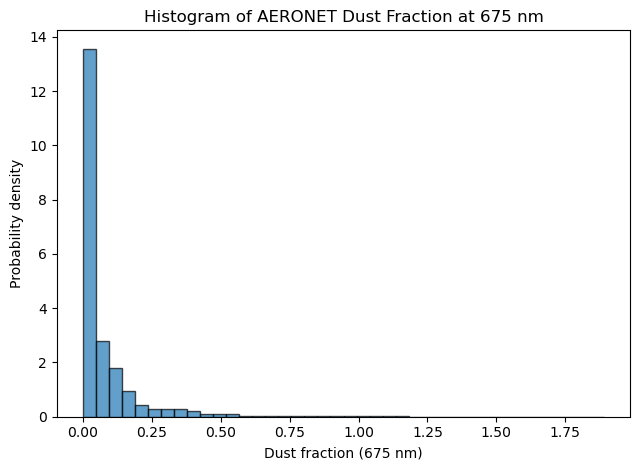

In [127]:
# Remove NaNs before plotting
df = np.asarray(dust_AOD_675, dtype=float)
df = df[np.isfinite(df)]

plt.figure(figsize=(6.5, 4.8))
plt.hist(df, bins=40, density=True, edgecolor="black", alpha=0.7)

plt.xlabel("Dust fraction (675 nm)")
plt.ylabel("Probability density")
plt.title("Histogram of AERONET Dust Fraction at 675 nm")

plt.tight_layout()
plt.show()

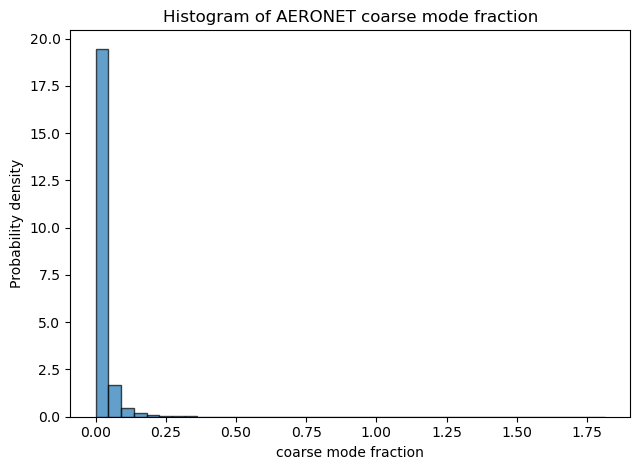

In [128]:
# Remove NaNs before plotting
df = np.asarray(AERONET_CM_AOD675, dtype=float)
df = df[np.isfinite(df)]

plt.figure(figsize=(6.5, 4.8))
plt.hist(df, bins=40, density=True, edgecolor="black", alpha=0.7)

plt.xlabel("coarse mode fraction")
plt.ylabel("Probability density")
plt.title("Histogram of AERONET coarse mode fraction")

plt.tight_layout()
plt.show()

In [129]:
MODIS_DB_SSA412.size

151738

In [130]:
# Dust-dominant index (boolean mask)
dust_idx = np.asarray(dust_fraction_675, dtype=float) > 0.8

nondust_idx = np.asarray(dust_fraction_675, dtype=float) < 0.1

# (optional but recommended) also require MODIS value to be finite
# dust_idx &= np.isfinite(MODIS_DB_SSA412)

# Sample MODIS arrays using the mask
MODIS_DB_SSA412_dust = np.asarray(MODIS_DB_SSA412)[dust_idx]
MODIS_DB_SSA470_dust = np.asarray(MODIS_DB_SSA470)[dust_idx]
MODIS_DB_SSA660_dust = np.asarray(MODIS_DB_SSA660)[dust_idx]
MODIS_DB_AE_dust = np.asarray(MODIS_DB_AE)[dust_idx]


# Sample MODIS arrays using the mask
MODIS_DB_SSA412_nondust = np.asarray(MODIS_DB_SSA412)[nondust_idx]
MODIS_DB_SSA470_nondust = np.asarray(MODIS_DB_SSA470)[nondust_idx]
MODIS_DB_SSA660_nondust = np.asarray(MODIS_DB_SSA660)[nondust_idx]
MODIS_DB_AE_nondust = np.asarray(MODIS_DB_AE)[nondust_idx]

# You can do the same for any other MODIS variable
# MODIS_DB_AOD550_dust = np.asarray(MODIS_DB_AOD550)[dust_idx]
# MODIS_DB_SSA443_dust  = np.asarray(MODIS_DB_SSA443)[dust_idx]

print("Dust-dominant samples:", dust_idx.sum(), "/", dust_idx.size)
print("SSA412 (dust) shape:", MODIS_DB_SSA412_dust.shape)

# Quick stats (ignoring NaNs)
print("SSA412 (dust) mean/std:", np.nanmean(MODIS_DB_SSA412_dust), np.nanstd(MODIS_DB_SSA412_dust))

Dust-dominant samples: 446 / 151738
SSA412 (dust) shape: (446,)
SSA412 (dust) mean/std: 0.9263059717328693 0.03102133587377002


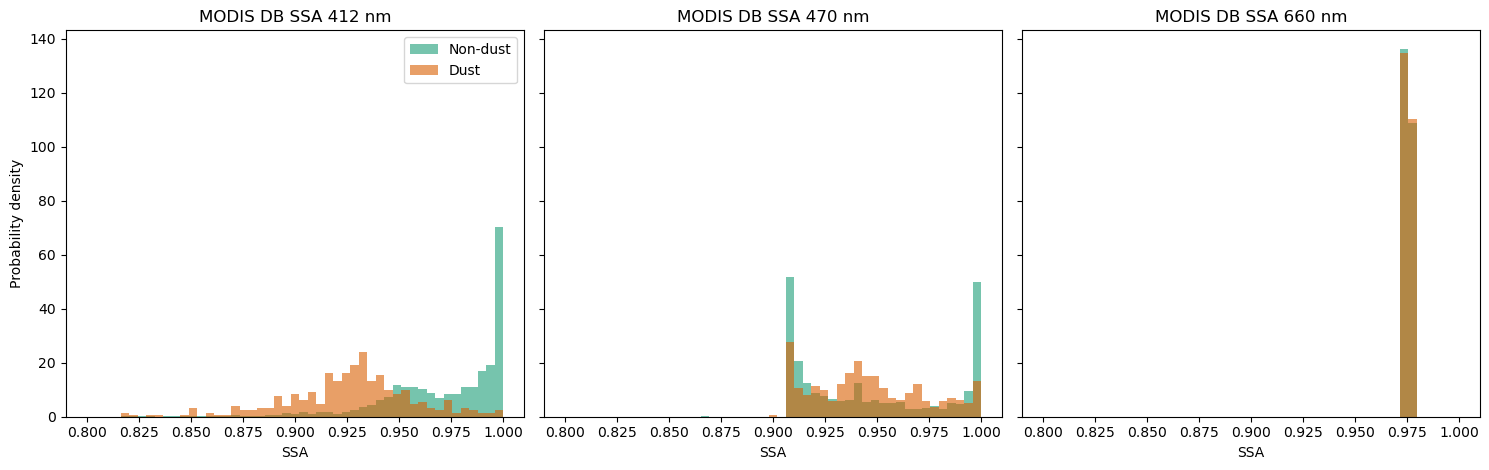

In [131]:

# ---------- Helper to clean data ----------
def _clean(x):
    x = np.asarray(x, dtype=float)
    return x[np.isfinite(x)]

# Clean arrays
ssa412_d = _clean(MODIS_DB_SSA412_dust)
ssa470_d = _clean(MODIS_DB_SSA470_dust)
ssa660_d = _clean(MODIS_DB_SSA660_dust)

ssa412_nd = _clean(MODIS_DB_SSA412_nondust)
ssa470_nd = _clean(MODIS_DB_SSA470_nondust)
ssa660_nd = _clean(MODIS_DB_SSA660_nondust)

# ---------- Plot settings ----------
bins = np.linspace(0.8, 1.0, 50)   # SSA physical range
alpha = 0.6

warm_color = "#d95f02"   # dust (orange/red)
cold_color = "#1b9e77"   # non-dust (green/teal)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

# ---------- SSA 412 ----------
axes[0].hist(
    ssa412_nd, bins=bins, color=cold_color, alpha=alpha,
    label="Non-dust", density=True
)
axes[0].hist(
    ssa412_d, bins=bins, color=warm_color, alpha=alpha,
    label="Dust", density=True
)
axes[0].set_title("MODIS DB SSA 412 nm")
axes[0].set_xlabel("SSA")
axes[0].set_ylabel("Probability density")
axes[0].legend()

# ---------- SSA 470 ----------
axes[1].hist(
    ssa470_nd, bins=bins, color=cold_color, alpha=alpha,
    density=True
)
axes[1].hist(
    ssa470_d, bins=bins, color=warm_color, alpha=alpha,
    density=True
)
axes[1].set_title("MODIS DB SSA 470 nm")
axes[1].set_xlabel("SSA")

# ---------- SSA 660 ----------
axes[2].hist(
    ssa660_nd, bins=bins, color=cold_color, alpha=alpha,
    density=True
)
axes[2].hist(
    ssa660_d, bins=bins, color=warm_color, alpha=alpha,
    density=True
)
axes[2].set_title("MODIS DB SSA 660 nm")
axes[2].set_xlabel("SSA")

plt.tight_layout()
plt.show()

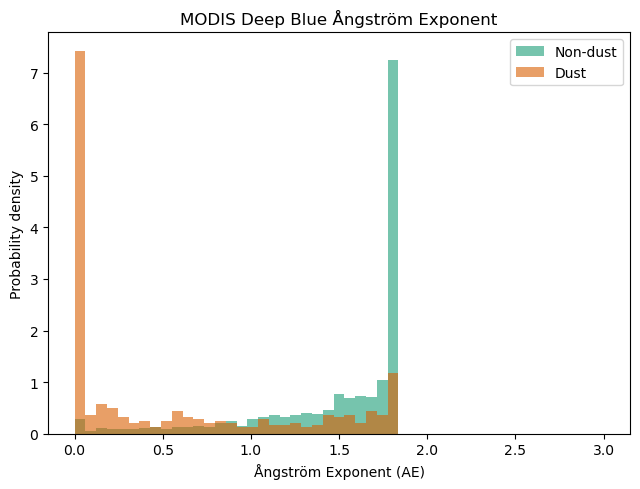

In [132]:
AE_dust = _clean(MODIS_DB_AE_dust)
AE_nondust = _clean(MODIS_DB_AE_nondust)

# ---------- Plot settings ----------
bins = np.linspace(0.0, 3.0, 50)   # typical AE range
alpha = 0.6

warm_color = "#d95f02"   # dust
cold_color = "#1b9e77"   # non-dust

# ---------- Plot ----------
plt.figure(figsize=(6.5, 5))

plt.hist(
    AE_nondust,
    bins=bins,
    color=cold_color,
    alpha=alpha,
    density=True,
    label="Non-dust"
)

plt.hist(
    AE_dust,
    bins=bins,
    color=warm_color,
    alpha=alpha,
    density=True,
    label="Dust"
)

plt.xlabel("Ångström Exponent (AE)")
plt.ylabel("Probability density")
plt.title("MODIS Deep Blue Ångström Exponent")
plt.legend()

plt.tight_layout()
plt.show()

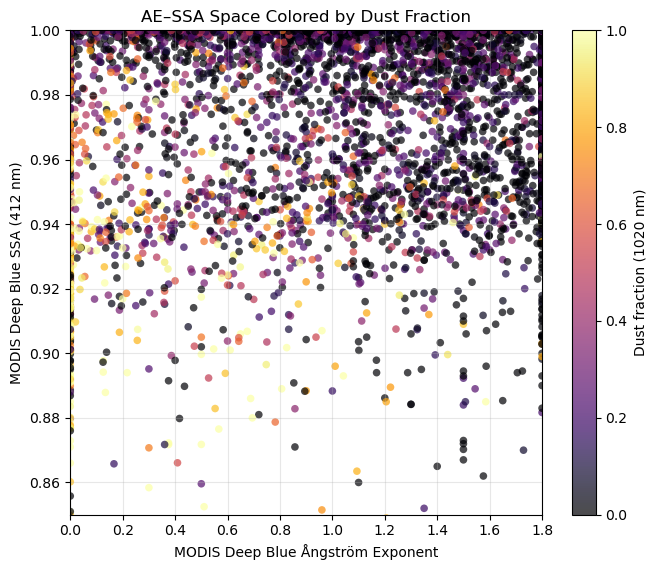

In [133]:


# ---------- Prepare data ----------
AE  = np.asarray(MODIS_DB_AE, dtype=float)
SSA = np.asarray(MODIS_DB_SSA412, dtype=float)
DF  = np.asarray(dust_fraction_675, dtype=float)

# Valid mask
mask = (
    np.isfinite(AE) &
    np.isfinite(SSA) &
    np.isfinite(DF) &
    (SSA > 0.0) & (SSA <= 1.0) &
    (AE >= 0.0)
)

AE  = AE[mask]
SSA = SSA[mask]
DF  = DF[mask]

# ---------- Plot ----------
plt.figure(figsize=(6.8, 5.8))

sc = plt.scatter(
    AE,
    SSA,
    c=DF,
    s=30,
    cmap="inferno",   # warm colors emphasize dust
    alpha=0.7,
    linewidths=0
)

cbar = plt.colorbar(sc)
cbar.set_label("Dust fraction (1020 nm)")

plt.xlabel("MODIS Deep Blue Ångström Exponent")
plt.ylabel("MODIS Deep Blue SSA (412 nm)")
plt.title("AE–SSA Space Colored by Dust Fraction")

# Typical physical limits
plt.xlim(0.0, 1.8)
plt.ylim(0.85, 1.0)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [134]:
AERONET_MODIS_collocated_data_dic[site_name][granule]['Deep_Blue_data']['stats_full']

NameError: name 'AERONET_MODIS_collocated_data_dic' is not defined

In [135]:
print(len(AERONET_AOD440),len(MODIS_DB_AOD550))

151738 151738


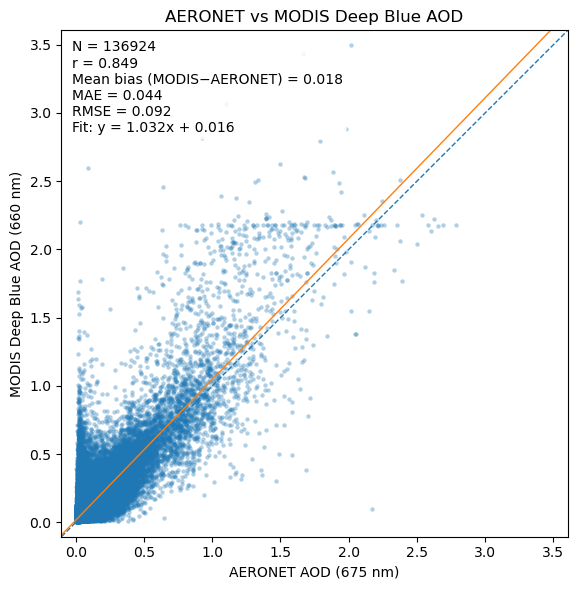

{'N': 136924, 'mean_bias_modis_minus_aeronet': 0.018381371978449933, 'MAE': 0.04432080343749025, 'RMSE': 0.0915283870197431, 'Pearson_r': 0.8491302778257384, 'slope': 1.0318381886751034, 'intercept': 0.015658450389325805}


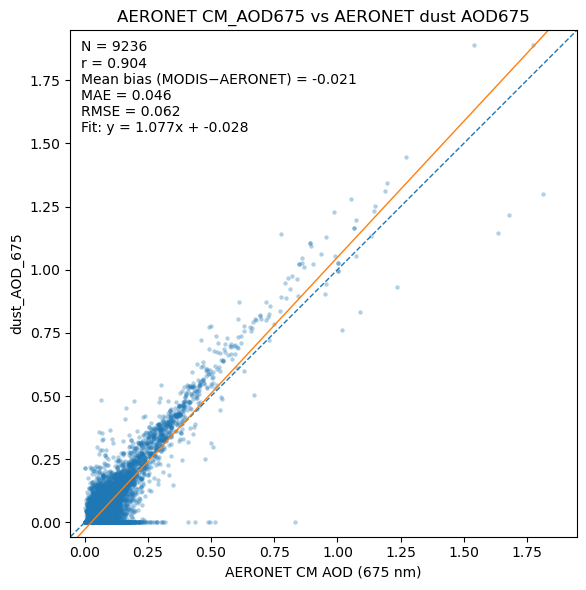

{'N': 9236, 'mean_bias_modis_minus_aeronet': -0.020768468495761354, 'MAE': 0.04601002740559837, 'RMSE': 0.06249013852439634, 'Pearson_r': 0.9035926760432885, 'slope': 1.076590201270024, 'intercept': -0.02758253480149428}


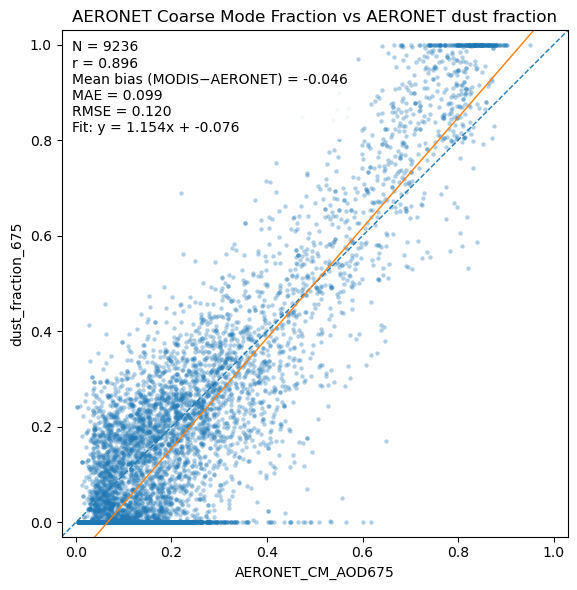

{'N': 9236, 'mean_bias_modis_minus_aeronet': -0.046001368320087624, 'MAE': 0.09913021740148195, 'RMSE': 0.12045333360006447, 'Pearson_r': 0.8958018869216555, 'slope': 1.1540568502209385, 'intercept': -0.07604743155446787}


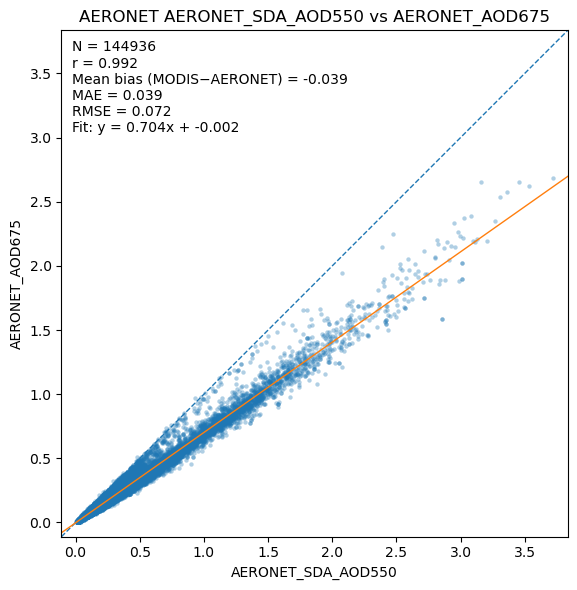

{'N': 144936, 'mean_bias_modis_minus_aeronet': -0.03921801894629354, 'MAE': 0.03923699576364739, 'RMSE': 0.07231314977186735, 'Pearson_r': 0.9923422358302787, 'slope': 0.7038528592862067, 'intercept': -0.00210514811031194}


In [136]:
import numpy as np
import matplotlib.pyplot as plt

def plot_aod_correlation(aeronet_aod, modis_aod, *,
                         xlabel="AERONET AOD (440 nm)",
                         ylabel="MODIS Deep Blue AOD (550 nm)",
                         title="AERONET vs MODIS Deep Blue AOD",
                         mode="both",              # "scatter", "hexbin", or "both"
                         gridsize=60,              # for hexbin density
                         mincnt=1,                 # for hexbin density
                         equal_axes=True,
                         show_regression=True,
                         annotate=True):
    """
    Plot correlation between two AOD datasets with metrics and 1:1 line.

    Metrics:
      - N
      - Mean Bias (MODIS - AERONET)
      - MAE, RMSE
      - Pearson r
      - (optional) linear regression line y = m x + b

    Returns: dict of computed metrics
    """
    x = np.asarray(aeronet_aod, dtype=float).ravel()
    y = np.asarray(modis_aod, dtype=float).ravel()

    # ---- Clean: finite + (optional) non-negative AOD ----
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    # If you want to enforce physical AOD >= 0, uncomment:
    # m2 = (x >= 0) & (y >= 0)
    # x, y = x[m2], y[m2]

    n = x.size
    if n < 3:
        raise ValueError(f"Not enough valid paired samples after filtering (N={n}).")

    diff = y - x  # MODIS - AERONET
    mean_bias = float(np.mean(diff))
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    r = float(np.corrcoef(x, y)[0, 1])

    # Linear regression (least squares): y = m*x + b
    slope, intercept = np.polyfit(x, y, 1) if show_regression else (np.nan, np.nan)

    # Limits
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    lo = float(np.nanmin([xmin, ymin]))
    hi = float(np.nanmax([xmax, ymax]))
    pad = 0.03 * (hi - lo) if hi > lo else 0.1
    lo, hi = lo - pad, hi + pad

    metrics = {
        "N": int(n),
        "mean_bias_modis_minus_aeronet": mean_bias,
        "MAE": mae,
        "RMSE": rmse,
        "Pearson_r": r,
        "slope": float(slope),
        "intercept": float(intercept),
    }

    def _decorate(ax):
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        # 1:1 line
        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)

        # Regression line
        if show_regression:
            xx = np.array([lo, hi])
            yy = slope * xx + intercept
            ax.plot(xx, yy, linewidth=1)

        if equal_axes:
            ax.set_aspect("equal", adjustable="box")

        if annotate:
            txt = (
                f"N = {metrics['N']}\n"
                f"r = {metrics['Pearson_r']:.3f}\n"
                f"Mean bias (MODIS−AERONET) = {metrics['mean_bias_modis_minus_aeronet']:.3f}\n"
                f"MAE = {metrics['MAE']:.3f}\n"
                f"RMSE = {metrics['RMSE']:.3f}"
            )
            if show_regression:
                txt += f"\nFit: y = {metrics['slope']:.3f}x + {metrics['intercept']:.3f}"

            ax.text(
                0.02, 0.98, txt,
                transform=ax.transAxes,
                va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none"),
            )

    # ---- Plot ----
    if mode == "scatter":
        fig, ax = plt.subplots(figsize=(6.5, 6))
        ax.scatter(x, y, s=10, alpha=0.35, linewidths=0)
        _decorate(ax)
        plt.tight_layout()
        plt.show()

    elif mode == "hexbin":
        fig, ax = plt.subplots(figsize=(6.5, 6))
        hb = ax.hexbin(x, y, gridsize=gridsize, mincnt=mincnt)
        plt.colorbar(hb, ax=ax, label="count")
        _decorate(ax)
        plt.tight_layout()
        plt.show()

    elif mode == "both":
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))
        axes[0].scatter(x, y, s=10, alpha=0.35, linewidths=0)
        _decorate(axes[0])
        axes[0].set_title(title + " (scatter)")

        hb = axes[1].hexbin(x, y, gridsize=gridsize, mincnt=mincnt)
        plt.colorbar(hb, ax=axes[1], label="count")
        _decorate(axes[1])
        axes[1].set_title(title + " (density)")

        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("mode must be 'scatter', 'hexbin', or 'both'.")

    return metrics


# --- Example usage with your arrays ---
# AERONET_AOD440 and MODIS_DB_AOD550 are the arrays you built in your notebook.
metrics = plot_aod_correlation(
    AERONET_AOD675,
    MODIS_DB_AOD660,
    xlabel="AERONET AOD (675 nm)",
    ylabel="MODIS Deep Blue AOD (660 nm)",
    title="AERONET vs MODIS Deep Blue AOD",
    mode="scatter"
)

print(metrics)


# --- Example usage with your arrays ---
# AERONET_AOD440 and MODIS_DB_AOD550 are the arrays you built in your notebook.
metrics = plot_aod_correlation(
    AERONET_CM_AOD675,
    dust_AOD_675,
    xlabel="AERONET CM AOD (675 nm)",
    ylabel="dust_AOD_675",
    title="AERONET CM_AOD675 vs AERONET dust AOD675",
    mode="scatter"
)

print(metrics)

# --- Example usage with your arrays ---
# AERONET_AOD440 and MODIS_DB_AOD550 are the arrays you built in your notebook.
metrics = plot_aod_correlation(
    AERONET_CMF675,
    dust_fraction_675,
    xlabel="AERONET_CM_AOD675",
    ylabel="dust_fraction_675",
    title="AERONET Coarse Mode Fraction vs AERONET dust fraction",
    mode="scatter"
)

print(metrics)


# --- Example usage with your arrays ---
# AERONET_AOD440 and MODIS_DB_AOD550 are the arrays you built in your notebook.
metrics = plot_aod_correlation(
    AERONET_SDA_AOD550,
    AERONET_AOD675,
    xlabel="AERONET_SDA_AOD550",
    ylabel="AERONET_AOD675",
    title="AERONET AERONET_SDA_AOD550 vs AERONET_AOD675",
    mode="scatter"
)

print(metrics)

In [137]:

from scipy.stats import linregress
from sklearn.metrics import mean_squared_error


def plot_aod_correlation_log(
    aeronet_aod,
    modis_aod,
    xlabel="AERONET AOD",
    ylabel="MODIS Deep Blue AOD",
    title="AERONET vs MODIS Deep Blue AOD",
    mode="both",          # "scatter", "hexbin", "both"
    gridsize=70,
    mincnt=1,
    lo=1e-3,
    hi=5.0,
    show_regression=True,
    annotate=True,
    equal_axes=True,
):
    """
    Log-log scatter/hexbin comparison plot for AOD with validation metrics computed in linear space.

    Notes
    -----
    - Plot axes are log-scaled; therefore only positive finite values are retained.
    - Metrics and linear regression are computed in *linear* space (common in validation literature).
    - Regression line is plotted as y = slope*x + intercept, over the log-spaced x-range.
    """

    # --- 1) Prepare data ---
    x = np.asarray(aeronet_aod, dtype=np.float64).ravel()
    y = np.asarray(modis_aod, dtype=np.float64).ravel()

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    N = int(x.size)
    if N < 2:
        raise ValueError("Not enough valid samples after filtering (need at least 2 positive finite pairs).")

    # --- 2) Statistics (linear space) ---
    slope, intercept, r, _, _ = linregress(x, y)
    rmse = float(np.sqrt(mean_squared_error(x, y)))
    mae = float(np.mean(np.abs(y - x)))
    mean_bias = float(np.mean(y - x))

    metrics = {
        "N": N,
        "mean_bias_modis_minus_aeronet": float(mean_bias),
        "MAE": float(mae),
        "RMSE": float(rmse),
        "Pearson_r": float(r),
        "slope": float(slope),
        "intercept": float(intercept),
    }

    # --- 3) Helpers ---
    lo = float(lo)
    hi = float(hi)
    if not (lo > 0 and hi > lo):
        raise ValueError("lo must be > 0 and hi must be > lo for log axes.")

    xx = np.logspace(np.log10(lo), np.log10(hi), 200)

    def _decorate(ax, subtitle=None):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title if subtitle is None else f"{title} ({subtitle})")

        # 1:1 line
        ax.plot(xx, xx, linestyle="--", linewidth=1)

        # Regression line (linear model, drawn over log-spaced x)
        if show_regression:
            ax.plot(xx, slope * xx + intercept, linewidth=1)

        if equal_axes:
            ax.set_aspect("equal", adjustable="box")

        if annotate:
            txt = (
                f"N = {metrics['N']}\n"
                f"r = {metrics['Pearson_r']:.3f}\n"
                f"Mean bias (MODIS − AERONET) = {metrics['mean_bias_modis_minus_aeronet']:.3f}\n"
                f"MAE = {metrics['MAE']:.3f}\n"
                f"RMSE = {metrics['RMSE']:.3f}"
            )
            if show_regression:
                txt += f"\nFit: y = {metrics['slope']:.3f}x + {metrics['intercept']:.3f}"

            ax.text(
                0.02, 0.98, txt,
                transform=ax.transAxes,
                va="top", ha="left",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none"),
            )

    # --- 4) Plotting ---
    mode = str(mode).lower().strip()

    if mode == "scatter":
        fig, ax = plt.subplots(figsize=(6.5, 6))
        ax.scatter(x, y, s=10, alpha=0.35, linewidths=0)
        _decorate(ax)
        plt.tight_layout()
        plt.show()

    elif mode == "hexbin":
        fig, ax = plt.subplots(figsize=(6.5, 6))
        hb = ax.hexbin(x, y, gridsize=gridsize, mincnt=mincnt)
        plt.colorbar(hb, ax=ax, label="count")
        _decorate(ax)
        plt.tight_layout()
        plt.show()

    elif mode == "both":
        fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))

        axes[0].scatter(x, y, s=10, alpha=0.35, linewidths=0)
        _decorate(axes[0], subtitle="scatter")

        hb = axes[1].hexbin(x, y, gridsize=gridsize, mincnt=mincnt)
        plt.colorbar(hb, ax=axes[1], label="count")
        _decorate(axes[1], subtitle="density")

        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("mode must be 'scatter', 'hexbin', or 'both'.")

    return metrics





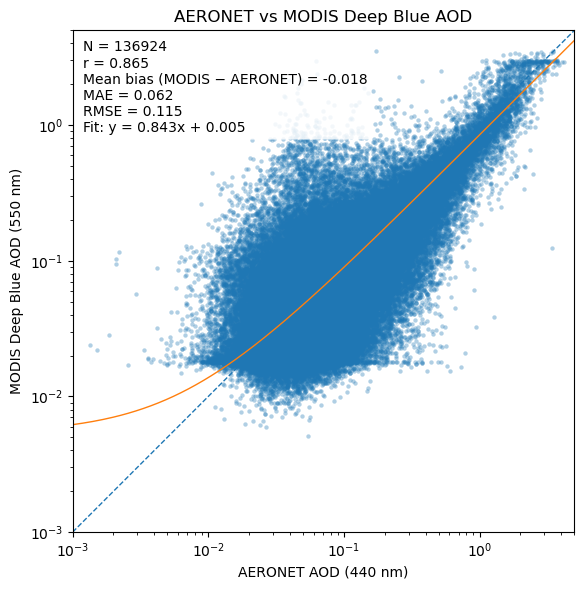

{'N': 136924, 'mean_bias_modis_minus_aeronet': -0.01758225552831259, 'MAE': 0.061834788337717626, 'RMSE': 0.11541353465874635, 'Pearson_r': 0.8651922442096289, 'slope': 0.8427780058874937, 'intercept': 0.005354750096827468}


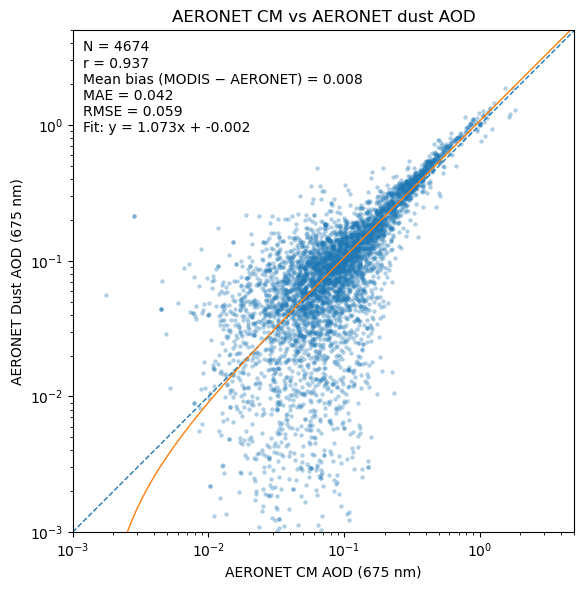

{'N': 4674, 'mean_bias_modis_minus_aeronet': 0.00762216136557426, 'MAE': 0.04225610951402666, 'RMSE': 0.059358705821662035, 'Pearson_r': 0.9373343153151314, 'slope': 1.0734562193415829, 'intercept': -0.0017172389758491613}


In [138]:
#Example usage:
metrics = plot_aod_correlation_log(
    AERONET_AOD440,
    MODIS_DB_AOD550,
    xlabel="AERONET AOD (440 nm)",
    ylabel="MODIS Deep Blue AOD (550 nm)",
    title="AERONET vs MODIS Deep Blue AOD",
    mode="scatter",
)
print(metrics)

#Example usage:
metrics = plot_aod_correlation_log(
    AERONET_CM_AOD675,
    dust_AOD_675,
    xlabel="AERONET CM AOD (675 nm)",
    ylabel="AERONET Dust AOD (675 nm)",
    title="AERONET CM vs AERONET dust AOD",
    mode="scatter",
)
print(metrics)


# ML-based training of AERONET and MODIS deepblue product against AERONET dust AOD derived from DPR

In [139]:
dust_fraction = dust_AOD_675/AERONET_AOD675
df = pd.DataFrame({
    "dust_fraction":dust_fraction,
    "AERONET_SDA_AE550":AERONET_SDA_AE550,
    "AERONET_SDA_AOD550":AERONET_SDA_AOD550,
    "AERONET_SDA_FMF550":AERONET_SDA_FMF550,
    "AERONET_AOD675":AERONET_AOD675,
    "AERONET_AOD440":AERONET_AOD440,
    "AERONET_AOD1020":AERONET_AOD1020,
    "AERONET_CM_AOD675":AERONET_CM_AOD675,
    "AERONET_CM_AOD440":AERONET_CM_AOD440,
    "AERONET_CM_AOD1020":AERONET_CM_AOD1020,
    "AERONET_CMF675":AERONET_CMF675,
    "AERONET_CMF440":AERONET_CMF440,
    "AERONET_CMF1020":AERONET_CMF1020,
    "AERONET_SSA675":AERONET_SSA675,
    "AERONET_SSA440":AERONET_SSA440,
    "AERONET_SSA1020":AERONET_SSA1020,
    # "AERONET_DPR675":AERONET_DPR675,
    # "AERONET_DPR1020":AERONET_DPR1020,
    # "AERONET_DPR440":AERONET_DPR440,
    # "AERONET_LR675":AERONET_LR675,
    # "AERONET_LR1020":AERONET_LR1020,
    # "AERONET_LR440":AERONET_LR440
})
# Replace inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing target or features
df = df.dropna()

# Enforce physical bounds
df = df[df["dust_fraction"] >= 0.00]

for col in [
    "AERONET_SDA_AOD550",
    "AERONET_AOD675",
    "AERONET_AOD440",
    "AERONET_AOD1020",
    "AERONET_CM_AOD675",
    "AERONET_CM_AOD440",
    "AERONET_CM_AOD1020",
    # "AERONET_DPR675",
    # "AERONET_DPR440",
    # "AERONET_DPR1020",
    # "AERONET_LR675",
    # "AERONET_LR1020",
    # "AERONET_LR440",
]:
    df = df[df[col] > 0]

for col in [
    "AERONET_SSA675",
    "AERONET_SSA440",
    "AERONET_SSA1020"
]:
    df[col] = df[col].clip(0.0, 1.0)

print("Final sample size:", len(df))

Final sample size: 8965


## first try to train AERONET on AERONET data

[0]	validation_0-rmse:0.23248
[200]	validation_0-rmse:0.08213
[400]	validation_0-rmse:0.08145
[600]	validation_0-rmse:0.08155
[624]	validation_0-rmse:0.08156
RMSE: 0.0761
MAE : 0.0522
R²  : 0.8978


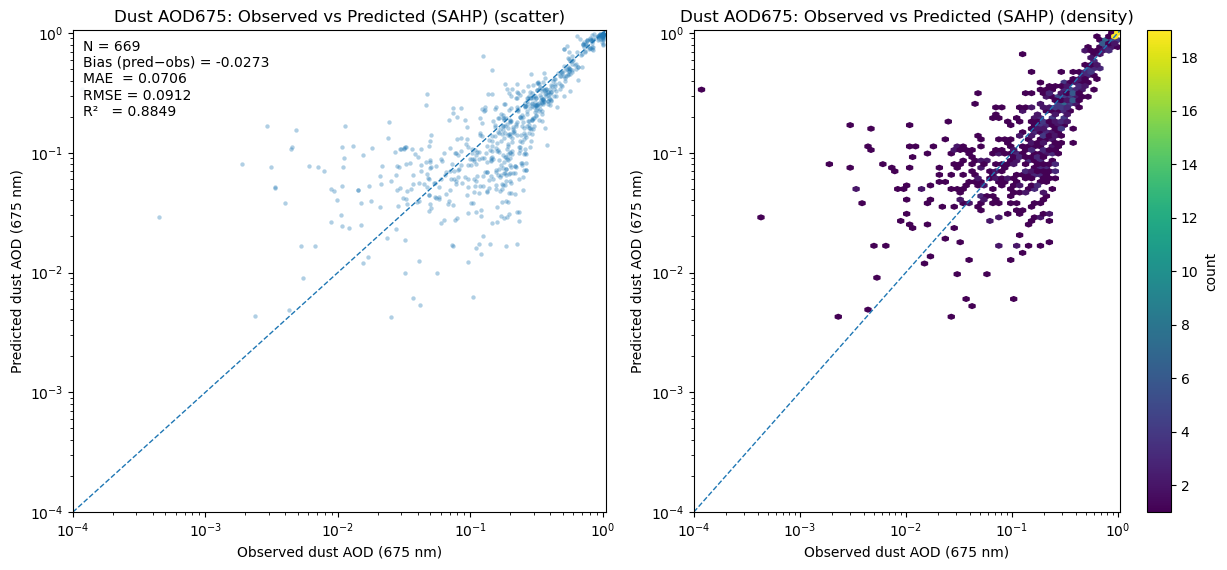

AERONET_CMF440        0.714714
AERONET_CMF675        0.141194
AERONET_CMF1020       0.022769
AERONET_SSA1020       0.017673
AERONET_SDA_FMF550    0.017540
AERONET_SSA675        0.015253
AERONET_SDA_AE550     0.013347
AERONET_SSA440        0.007738
AERONET_AOD440        0.007500
AERONET_AOD1020       0.007498
AERONET_CM_AOD440     0.007228
AERONET_SDA_AOD550    0.007170
AERONET_CM_AOD1020    0.006884
AERONET_CM_AOD675     0.006801
AERONET_AOD675        0.006690
dtype: float32


In [140]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
# -----------------------------
# SAHP plot (scatter + density parity) in log axes
# -----------------------------
def sahp_parity_plot_log(
    y_true_lin,
    y_pred_lin,
    title="SAHP Parity Plot (log space)",
    xlabel="Observed dust AOD (675 nm)",
    ylabel="Predicted dust AOD (675 nm)",
    lo=1e-4,
    hi=None,
    gridsize=70,
    mincnt=1,
):
    """
    SAHP-style parity plot:
      - left: scatter on log-log axes
      - right: hexbin density on log-log axes
      - 1:1 line and metrics annotated
    Metrics are computed in linear space (common in validation literature).
    """
    y_true = np.asarray(y_true_lin, dtype=float)
    y_pred = np.asarray(y_pred_lin, dtype=float)

    # keep finite and positive for log plotting
    m = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    yt = y_true[m]
    yp = y_pred[m]
    if yt.size == 0:
        raise ValueError("No valid positive samples to plot on log axes.")

    if hi is None:
        hi = float(np.nanmax([yt.max(), yp.max()]) * 1.05)

    # linear-space metrics
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp))
    bias = float(np.mean(yp - yt))
    N    = int(yt.size)

    txt = (
        f"N = {N}\n"
        f"Bias (pred−obs) = {bias:.4f}\n"
        f"MAE  = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"R²   = {r2:.4f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))

    # Scatter
    ax = axes[0]
    ax.scatter(yt, yp, s=10, alpha=0.35, linewidths=0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title + " (scatter)")
    xx = np.logspace(np.log10(lo), np.log10(hi), 200)
    ax.plot(xx, xx, linestyle="--", linewidth=1)  # 1:1
    ax.text(
        0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
    )

    # Density (hexbin)
    ax = axes[1]
    hb = ax.hexbin(yt, yp, gridsize=gridsize, mincnt=mincnt, xscale="log", yscale="log")
    cb = plt.colorbar(hb, ax=ax, label="count")
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title + " (density)")
    ax.plot(xx, xx, linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

    return {"N": N, "bias": bias, "MAE": mae, "RMSE": rmse, "R2": r2}


# -----------------------------
# Target and features
# -----------------------------
y = df["dust_fraction"].astype(float)
X = df.drop(columns=["dust_fraction"]).astype(float)

# -----------------------------
# Remove invalid samples
# -----------------------------
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X.loc[mask]
y = y.loc[mask]

# 70% train, 15% val, 15% test
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)
model = XGBRegressor(
    n_estimators=1500,
    early_stopping_rounds=200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=200
)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

_ = sahp_parity_plot_log(
    y_true_lin=y_test,
    y_pred_lin=y_pred,
    title="Dust AOD675: Observed vs Predicted (SAHP)",
    xlabel="Observed dust AOD (675 nm)",
    ylabel="Predicted dust AOD (675 nm)",
    lo=1e-4,
)
print(importance)

### SHAP (SHapley Additive exPlanations) plots

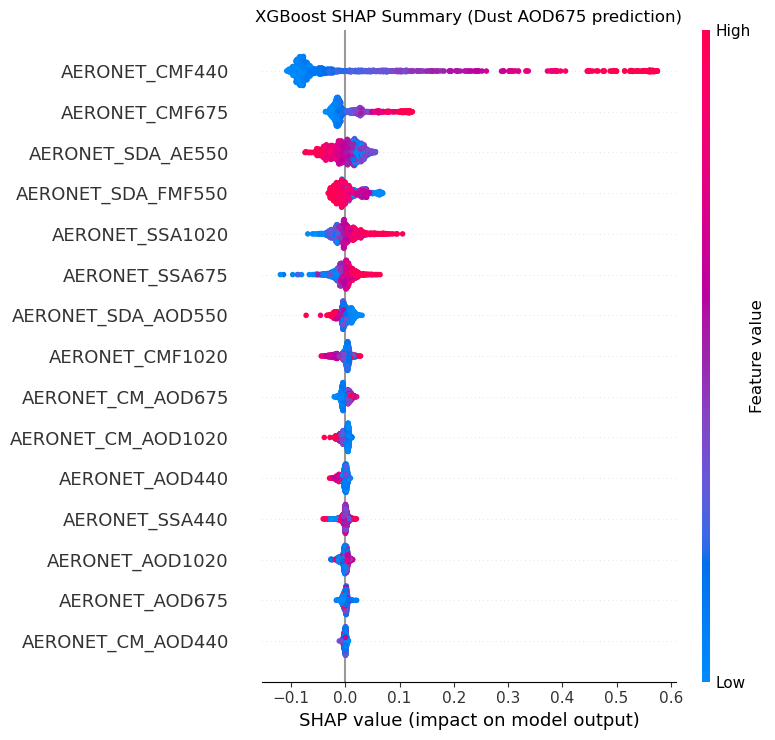

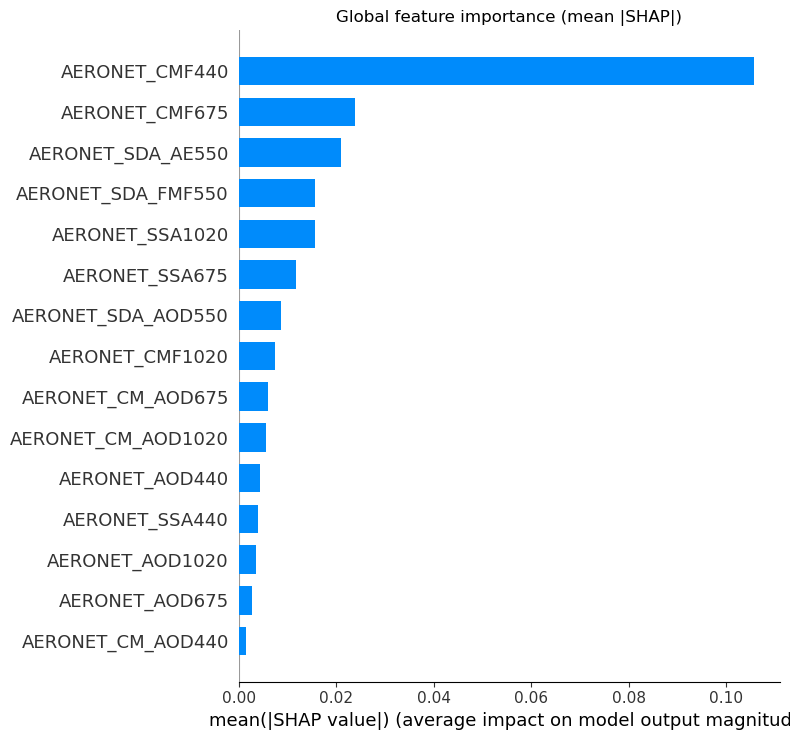

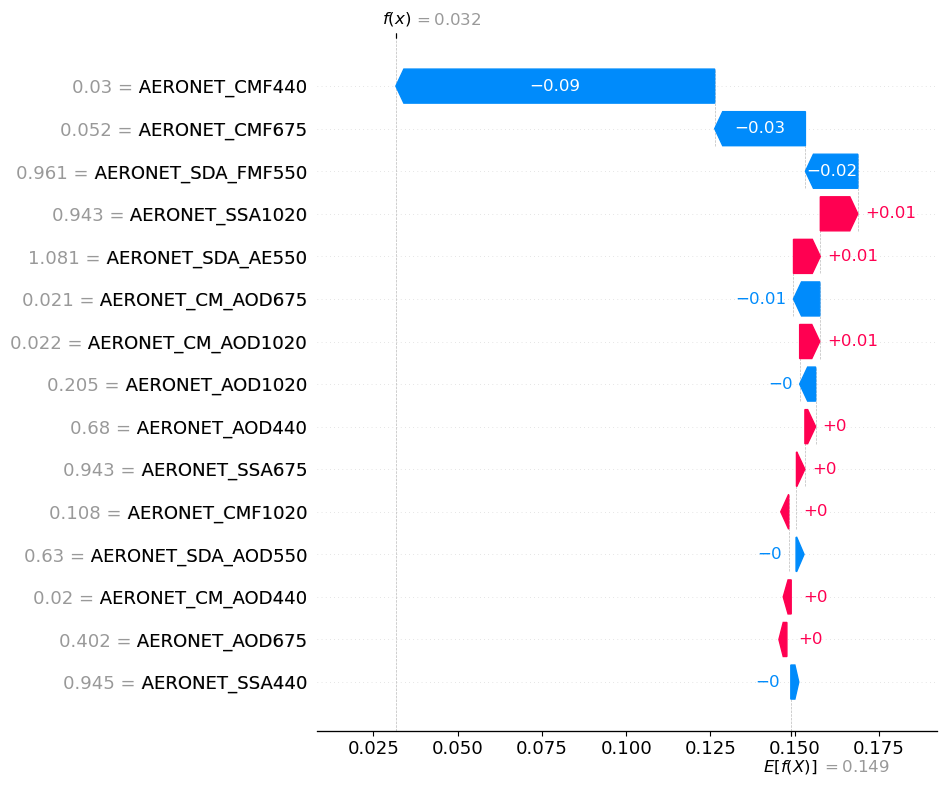

Top features by mean(|SHAP|): ['AERONET_CMF440', 'AERONET_CMF675', 'AERONET_SDA_AE550', 'AERONET_SDA_FMF550', 'AERONET_SSA1020']


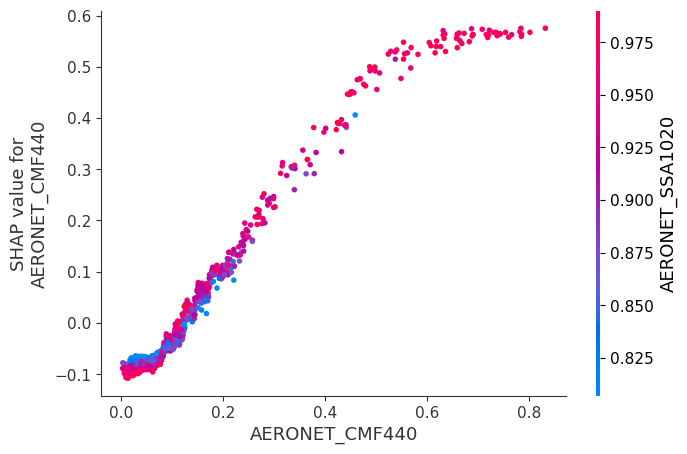

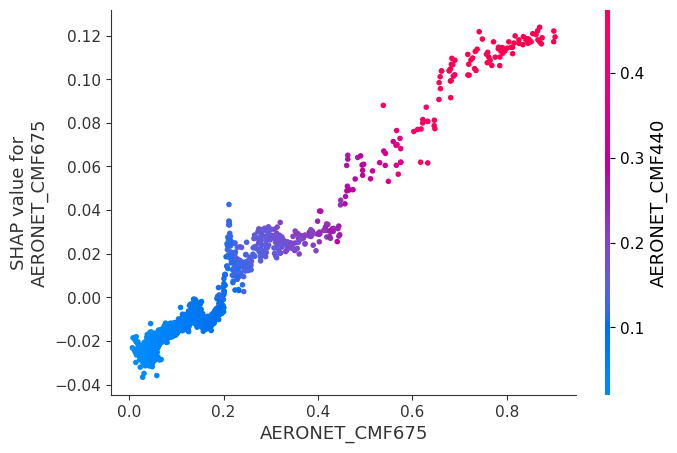

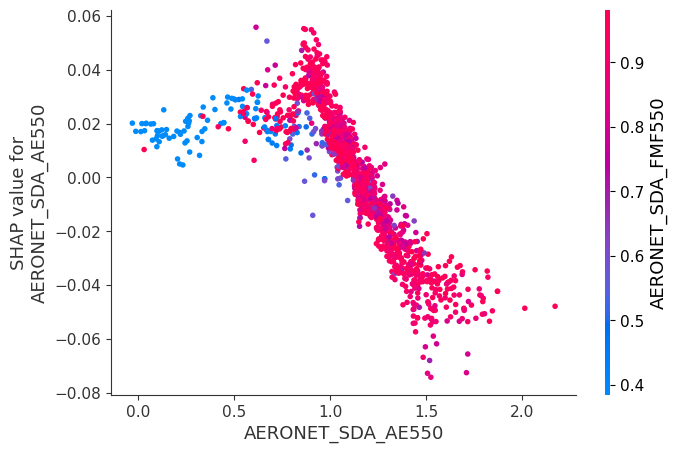

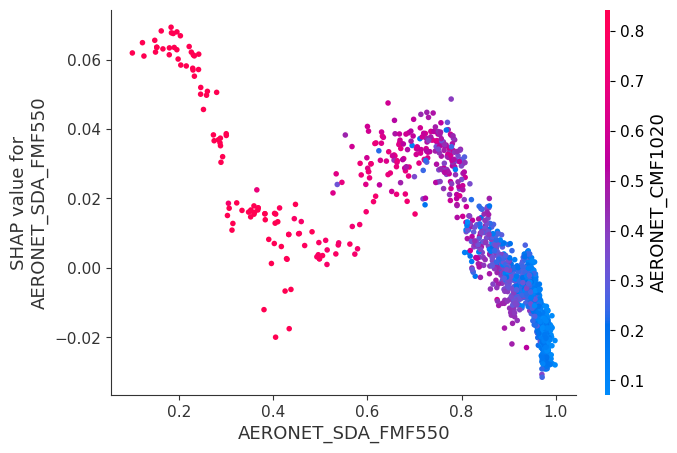

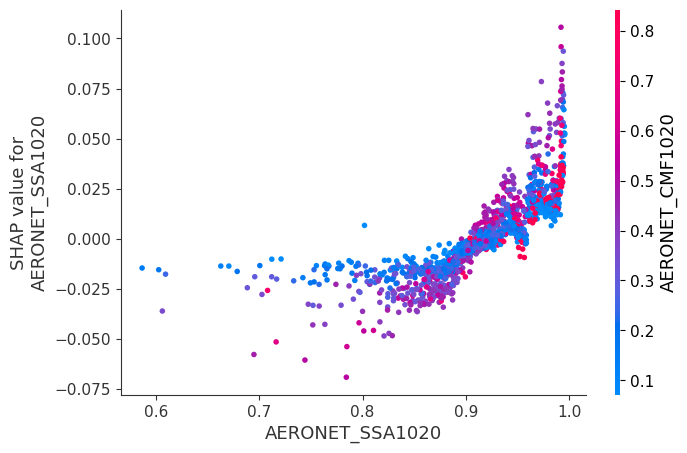

In [141]:
# =========================
# SHAP explainability for your trained XGBRegressor
# =========================
# Assumes you already ran:
#   model.fit(...)
# and you still have:
#   X_train, X_val, X_test, y_train, y_val, y_test
# plus model = XGBRegressor(...)


import shap

# ---- 0) (Optional but recommended) sample for speed ----
# SHAP can be slow on very large datasets; start with a representative sample.
# Increase nsamp if it is fast enough.
nsamp = min(5000, len(X_test))
X_explain = X_test.sample(n=nsamp, random_state=42) if len(X_test) > nsamp else X_test.copy()

# ---- 1) Build an explainer (TreeExplainer is best for XGBoost trees) ----
# For xgboost sklearn wrapper, this usually "just works".
explainer = shap.TreeExplainer(model)

# shap_values can be:
# - a numpy array (n_samples, n_features) for regression
# - or a shap.Explanation object in newer versions
shap_values = explainer.shap_values(X_explain)

# If you get a list (rare for some configs), take the first element
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# ---- 2) SHAP summary plot (beeswarm) like your screenshot ----
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="dot",   # beeswarm
    show=False
)
plt.title("XGBoost SHAP Summary (Dust AOD675 prediction)")
plt.tight_layout()
plt.show()

# ---- 3) SHAP summary plot (bar) for mean(|SHAP|) global importance ----
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_explain,
    plot_type="bar",
    show=False
)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.show()

# ---- 4) Waterfall plot for ONE prediction (local explanation) ----
# Choose an index to explain
i = 0
x_row = X_explain.iloc[[i]]  # keep as DataFrame for feature names

# Get SHAP values for this row as an Explanation object (for nice waterfall)
# Some SHAP versions return plain arrays from shap_values; we can reconstruct:
base_value = explainer.expected_value
sv_row = shap_values[i, :]

# expected_value can be array-like; for regression it is usually scalar
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(np.ravel(base_value)[0])

exp = shap.Explanation(
    values=sv_row,
    base_values=base_value,
    data=x_row.iloc[0].values,
    feature_names=X_explain.columns.tolist()
)

shap.plots.waterfall(exp, max_display=15)  # shows top contributors

# ---- 5) Dependence plots (how a feature changes prediction) ----
# Pick your top few features from mean(|SHAP|):
mean_abs = np.abs(shap_values).mean(axis=0)
top_feats = X_explain.columns[np.argsort(mean_abs)[::-1][:5]].tolist()
print("Top features by mean(|SHAP|):", top_feats)

for feat in top_feats:
    shap.dependence_plot(
        feat,
        shap_values,
        X_explain,
        interaction_index="auto",  # shows strongest interaction feature
        show=True
    )

# ---- 6) SHAP interaction values (optional; can be expensive) ----
# Useful if you suspect strong nonlinear interactions.
# Start with a small sample.
# X_small = X_explain.sample(n=min(1500, len(X_explain)), random_state=0)
# shap_inter = explainer.shap_interaction_values(X_small)
# shap.summary_plot(shap_inter, X_small)  # global interaction summary


### compare AERONET AE and AERONET FMF

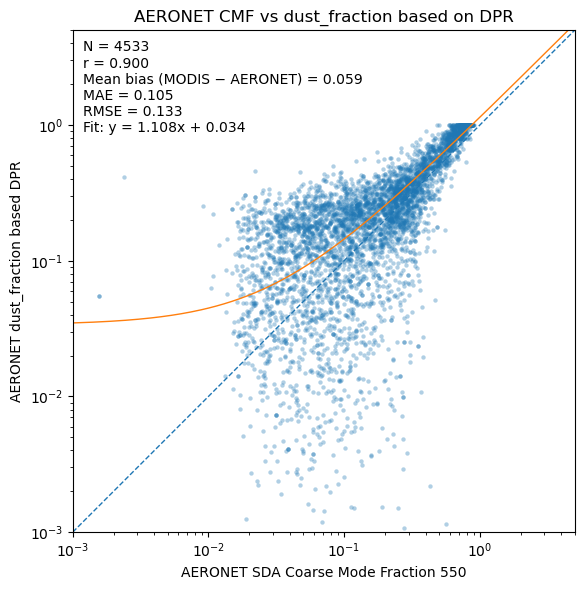

{'N': 4533, 'mean_bias_modis_minus_aeronet': 0.05902428592107732, 'MAE': 0.10490627436497825, 'RMSE': 0.1330137941577288, 'Pearson_r': 0.9002381415561079, 'slope': 1.107927004585655, 'intercept': 0.03373013029860761}


In [142]:
#Example usage:
metrics = plot_aod_correlation_log(
    1-AERONET_SDA_FMF550,
    dust_fraction,
    xlabel="AERONET SDA Coarse Mode Fraction 550",
    ylabel="AERONET dust_fraction based DPR",
    title="AERONET CMF vs dust_fraction based on DPR",
    mode="scatter",
)
print(metrics)

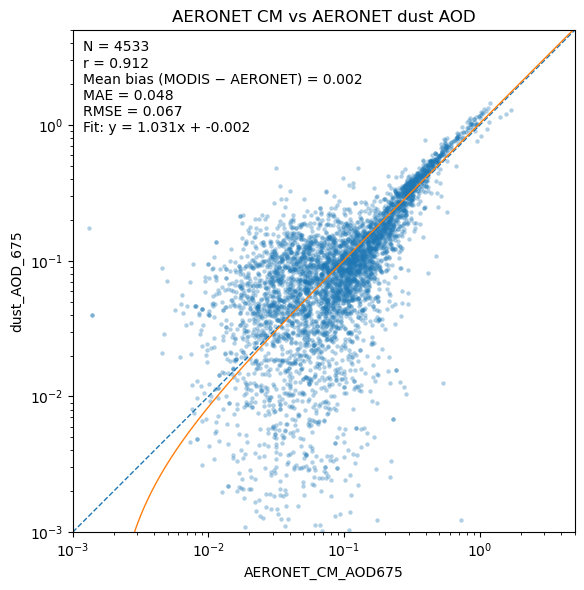

{'N': 4533, 'mean_bias_modis_minus_aeronet': 0.0021949075942377535, 'MAE': 0.04826427392789377, 'RMSE': 0.06704366256953179, 'Pearson_r': 0.9119801572217698, 'slope': 1.0313474089049515, 'intercept': -0.0019400706932204137}


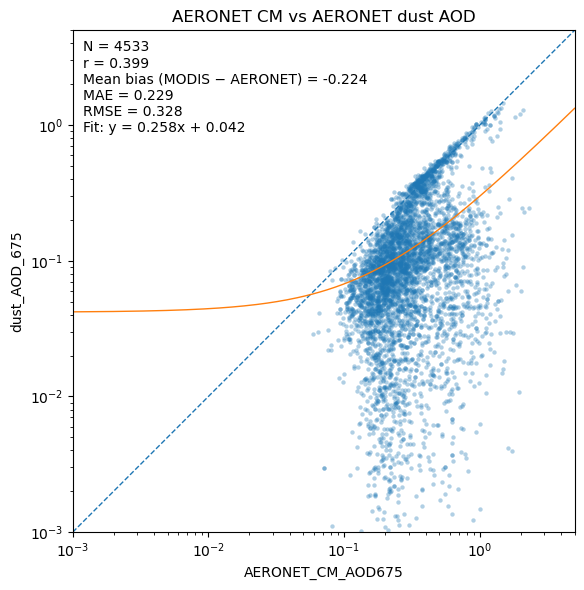

{'N': 4533, 'mean_bias_modis_minus_aeronet': -0.22421063885297643, 'MAE': 0.22859525191413935, 'RMSE': 0.3281203616971549, 'Pearson_r': 0.39867123122594283, 'slope': 0.2576156439230534, 'intercept': 0.04179583380989248}


In [143]:
#Example usage:
# -----------------------------
# Parameterization (paper Eq. 7)
# FMF = f_mean(AE) = 0.085*AE^2 + 0.336*AE + 0.051
# Note: fitted using FMF < 0.7 (paper), but you can plot it across the axis range.
# -----------------------------
def fmean(alpha):
    return 0.085*alpha**2 + 0.336*alpha + 0.051
FMF_mean_par = fmean(AERONET_SDA_AE550)

metrics = plot_aod_correlation_log(
    (1-AERONET_SDA_FMF550)*AERONET_SDA_AOD550,
    dust_AOD_675,
    xlabel="AERONET_CM_AOD675",
    ylabel="dust_AOD_675",
    title="AERONET CM vs AERONET dust AOD",
    mode="scatter",
)
print(metrics)


metrics = plot_aod_correlation_log(
    (1-FMF_mean_par)*AERONET_SDA_AOD550,
    dust_AOD_675,
    xlabel="AERONET_CM_AOD675",
    ylabel="dust_AOD_675",
    title="AERONET CM vs AERONET dust AOD",
    mode="scatter",
)
print(metrics)

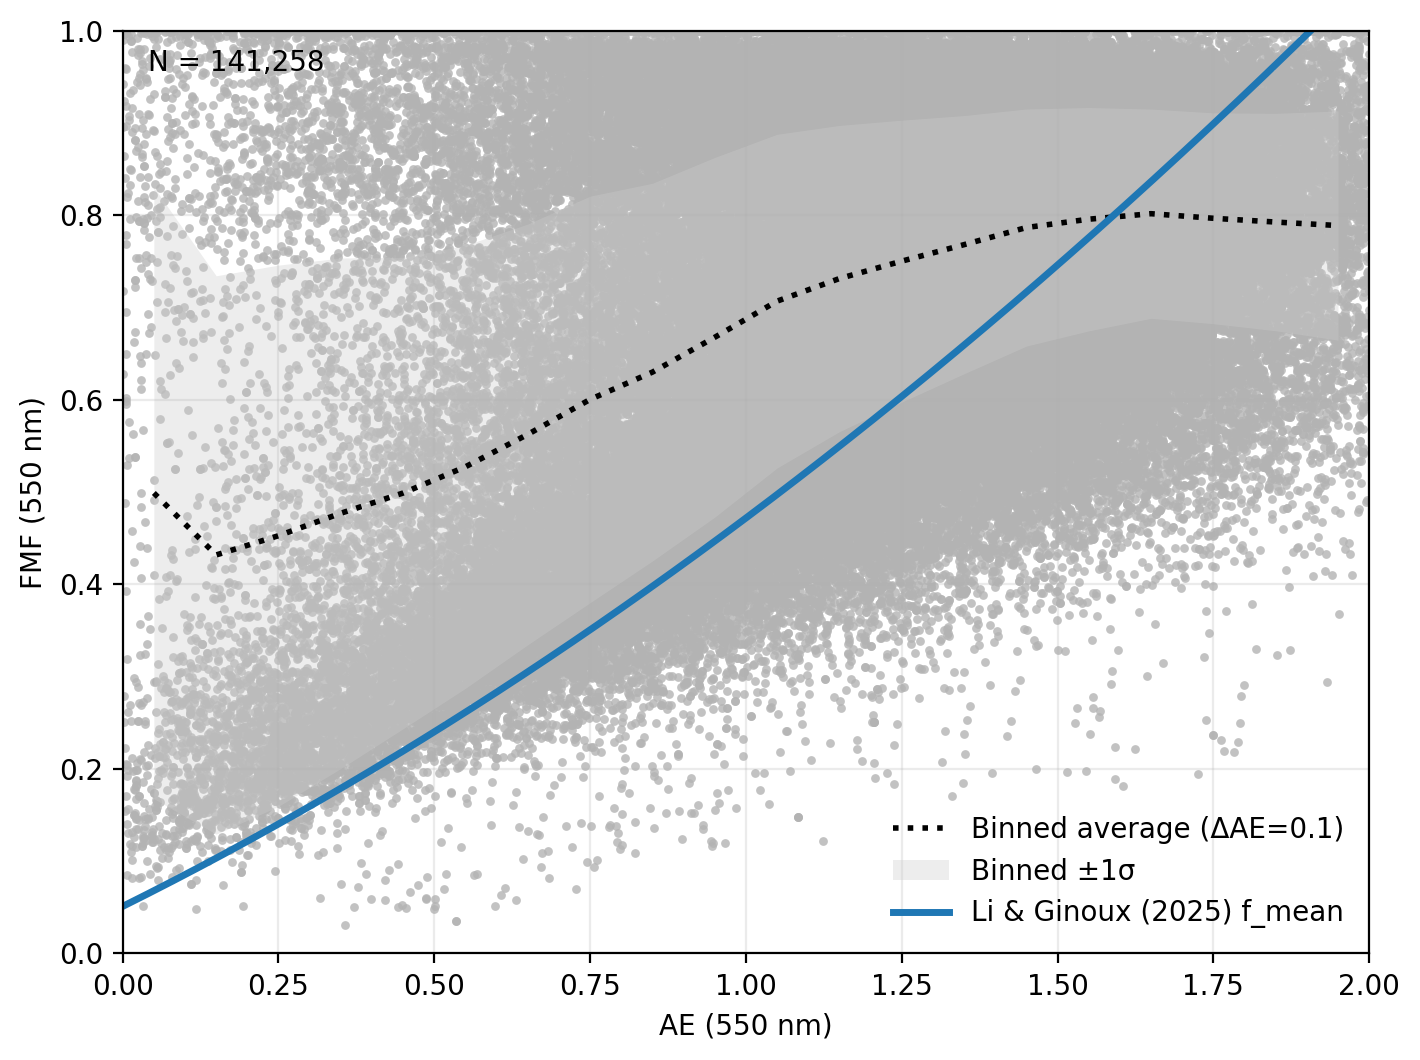

In [144]:

# ------------------------------------------------------------
# Inputs (you already have these as 1-D arrays of length 73085)
# ------------------------------------------------------------
# AERONET_SDA_AE550  = ...  # Ångström exponent at 550 nm (shape: [N])
# AERONET_SDA_FMF550 = ...  # Fine-mode fraction at 550 nm (shape: [N])

AE  = np.asarray(AERONET_SDA_AE550).astype(float)
FMF = np.asarray(AERONET_SDA_FMF550).astype(float)

# --------------------
# Basic QC / filtering
# --------------------
m = np.isfinite(AE) & np.isfinite(FMF)
AE, FMF = AE[m], FMF[m]

# Optional: keep physically plausible FMF range
m = (FMF >= 0.0) & (FMF <= 1.0)
AE, FMF = AE[m], FMF[m]

# Optional: limit AE plotting range similar to Fig. 3a (0–2)
m = (AE >= 0.0) & (AE <= 2.0)
AE, FMF = AE[m], FMF[m]



# -------------------------
# Binned average (Fig. 3a)
# bins by AE in increments of 0.1
# -------------------------
bin_w = 0.1
edges = np.arange(0.0, 2.0 + bin_w, bin_w)
centers = 0.5*(edges[:-1] + edges[1:])

idx = np.digitize(AE, edges) - 1  # 0..nbin-1
nbin = len(centers)

bin_mean = np.full(nbin, np.nan)
bin_std  = np.full(nbin, np.nan)
bin_n    = np.zeros(nbin, dtype=int)

for i in range(nbin):
    sel = (idx == i)
    bin_n[i] = np.sum(sel)
    if bin_n[i] >= 10:  # require some minimum samples per bin
        bin_mean[i] = np.mean(FMF[sel])
        bin_std[i]  = np.std(FMF[sel], ddof=1)

# -------------------------
# Plot (Figure 3a style)
# -------------------------
fig, ax = plt.subplots(figsize=(7.2, 5.4), dpi=200)

# Gray scatter. rasterized helps for large N when saving vector formats
ax.scatter(AE, FMF, s=10, alpha=0.8, linewidths=0, color="0.7", rasterized=True)

# Binned average as black dotted line
ax.plot(centers, bin_mean, linestyle=":", linewidth=2.0, color="k", label="Binned average (ΔAE=0.1)")

# Optionally show ±1 std band around binned mean
ax.fill_between(
    centers,
    bin_mean - bin_std,
    bin_mean + bin_std,
    color="0.8",
    alpha=0.35,
    linewidth=0,
    label="Binned ±1σ"
)

# Parameterization curve
x = np.linspace(0.0, 2.0, 400)
ax.plot(x, fmean(x), linewidth=2.5, label="Li & Ginoux (2025) f_mean")

# Formatting similar to the paper
ax.set_xlim(0.0, 2.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("AE (550 nm)")
ax.set_ylabel("FMF (550 nm)")
ax.grid(True, which="major", alpha=0.25)
ax.legend(frameon=False, loc="lower right")

# Optional annotation: sample size
ax.text(0.02, 0.98, f"N = {len(AE):,}", transform=ax.transAxes,
        va="top", ha="left")

plt.tight_layout()
plt.show()

# If you want to save:
# fig.savefig("FMF_vs_AE_like_Fig3a.png", dpi=300, bbox_inches="tight")
# fig.savefig("FMF_vs_AE_like_Fig3a.pdf", bbox_inches="tight")

## Now try to train MODIS Deep Blue data on AERONET data

In [145]:
AERONET_CMF550=(1-AERONET_SDA_FMF550)
AERONET_CM_AOD550=AERONET_CMF550*AERONET_SDA_AOD550
dust_fraction_675 = dust_AOD_675/AERONET_AOD675
arrays = [
    dust_fraction,
    MODIS_DB_AOD550,
    MODIS_DB_AOD412,
    MODIS_DB_AOD470,
    MODIS_DB_AOD660,
    MODIS_DB_AE,
    MODIS_DB_SSA412,
    MODIS_DB_SSA470,
    MODIS_DB_SSA660,
]

lengths = [len(a) for a in arrays]
print("Array lengths:", lengths)

assert len(set(lengths)) == 1, "ERROR: Arrays do not have the same length"
import pandas as pd

df = pd.DataFrame({
    "dust_fraction_675": dust_fraction,
    "MODIS_DB_AOD550":  MODIS_DB_AOD550,
    "MODIS_DB_AOD412":  MODIS_DB_AOD412,
    "MODIS_DB_AOD470":  MODIS_DB_AOD470,
    "MODIS_DB_AOD660":  MODIS_DB_AOD660,
    "MODIS_DB_AE":      MODIS_DB_AE,
    "MODIS_DB_SSA412":  MODIS_DB_SSA412,
    "MODIS_DB_SSA470":  MODIS_DB_SSA470,
    "MODIS_DB_SSA660":  MODIS_DB_SSA660,
})
# Replace inf with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows with missing target or features
df = df.dropna()

# Enforce physical bounds
df[df["dust_fraction_675"] >= 0.00]

for col in [
    "MODIS_DB_AOD550","MODIS_DB_AOD412",
    "MODIS_DB_AOD470","MODIS_DB_AOD660"
]:
    df = df[df[col] > 0]

for col in [
    "MODIS_DB_SSA412","MODIS_DB_SSA660","MODIS_DB_SSA470",
]:
    df[col] = df[col].clip(0.0, 1.0)

print("Final sample size:", len(df))

Array lengths: [151738, 151738, 151738, 151738, 151738, 151738, 151738, 151738, 151738]
Final sample size: 4163


In [146]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [148]:
# -----------------------------
# Target and features
# -----------------------------
y = df["dust_fraction_675"].astype(float)
X = df.drop(columns=["dust_fraction_675"]).astype(float)

# -----------------------------
# Remove invalid samples
# -----------------------------
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X = X.loc[mask]
y = y.loc[mask]

# 70% train, 15% val, 15% test
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)
model = XGBRegressor(
    n_estimators=2000,
    early_stopping_rounds=200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=200
)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

[0]	validation_0-rmse:0.27145
[200]	validation_0-rmse:0.22004
[288]	validation_0-rmse:0.22169
RMSE: 0.2207
MAE : 0.1655
R²  : 0.4037
MODIS_DB_AE        0.301747
MODIS_DB_SSA412    0.156458
MODIS_DB_AOD660    0.113094
MODIS_DB_AOD412    0.096719
MODIS_DB_SSA470    0.095938
MODIS_DB_AOD550    0.085321
MODIS_DB_AOD470    0.081266
MODIS_DB_SSA660    0.069456
dtype: float32


[0]	validation_0-rmse:0.19965
[200]	validation_0-rmse:0.16651
[288]	validation_0-rmse:0.16886
RMSE (linear): 0.2220
MAE  (linear): 0.1637
R²   (linear): 0.3962


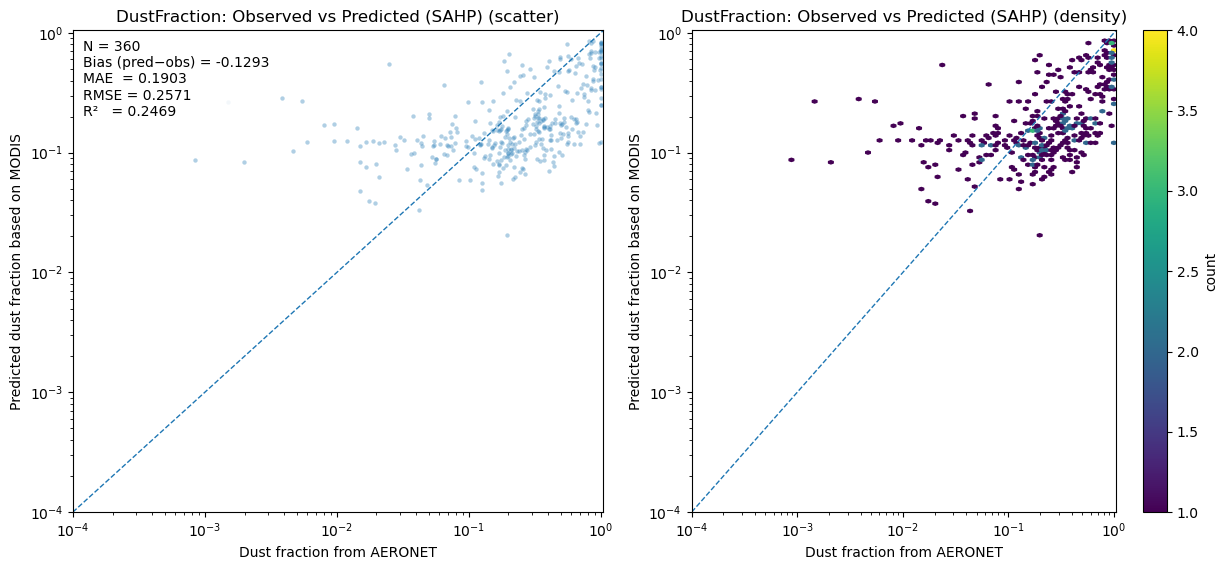

MODIS_DB_AE        0.295374
MODIS_DB_SSA412    0.147182
MODIS_DB_AOD660    0.116411
MODIS_DB_AOD412    0.097456
MODIS_DB_SSA470    0.096289
MODIS_DB_AOD470    0.090473
MODIS_DB_AOD550    0.083723
MODIS_DB_SSA660    0.073093
dtype: float32


In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# -----------------------------
# Log-space helpers (safe for zeros)
# -----------------------------
def log1p_transform(y, eps=0.0):
    """
    Log transform for nonnegative targets: log( y + 1 + eps )
    - eps lets you shift slightly if you have tiny negatives from noise (usually keep eps=0).
    """
    y = np.asarray(y, dtype=float)
    y = np.clip(y, 0.0, None)  # enforce nonnegative for AOD-type targets
    return np.log1p(y + eps)

def inv_log1p_transform(y_log, eps=0.0):
    """Inverse of log1p_transform."""
    y_log = np.asarray(y_log, dtype=float)
    y_lin = np.expm1(y_log) - eps
    return np.clip(y_lin, 0.0, None)


# -----------------------------
# SAHP plot (scatter + density parity) in log axes
# -----------------------------
def sahp_parity_plot_log(
    y_true_lin,
    y_pred_lin,
    title="SAHP Parity Plot (log space)",
    xlabel="Observed dust AOD (675 nm)",
    ylabel="Predicted dust AOD (675 nm)",
    lo=1e-4,
    hi=None,
    gridsize=70,
    mincnt=1,
):
    """
    SAHP-style parity plot:
      - left: scatter on log-log axes
      - right: hexbin density on log-log axes
      - 1:1 line and metrics annotated
    Metrics are computed in linear space (common in validation literature).
    """
    y_true = np.asarray(y_true_lin, dtype=float)
    y_pred = np.asarray(y_pred_lin, dtype=float)

    # keep finite and positive for log plotting
    m = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true > 0) & (y_pred > 0)
    yt = y_true[m]
    yp = y_pred[m]
    if yt.size == 0:
        raise ValueError("No valid positive samples to plot on log axes.")

    if hi is None:
        hi = float(np.nanmax([yt.max(), yp.max()]) * 1.05)

    # linear-space metrics
    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae  = float(mean_absolute_error(yt, yp))
    r2   = float(r2_score(yt, yp))
    bias = float(np.mean(yp - yt))
    N    = int(yt.size)

    txt = (
        f"N = {N}\n"
        f"Bias (pred−obs) = {bias:.4f}\n"
        f"MAE  = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"R²   = {r2:.4f}"
    )

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))

    # Scatter
    ax = axes[0]
    ax.scatter(yt, yp, s=10, alpha=0.35, linewidths=0)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title + " (scatter)")
    xx = np.logspace(np.log10(lo), np.log10(hi), 200)
    ax.plot(xx, xx, linestyle="--", linewidth=1)  # 1:1
    ax.text(
        0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none")
    )

    # Density (hexbin)
    ax = axes[1]
    hb = ax.hexbin(yt, yp, gridsize=gridsize, mincnt=mincnt, xscale="log", yscale="log")
    cb = plt.colorbar(hb, ax=ax, label="count")
    ax.set_xlim(lo, hi);  ax.set_ylim(lo, hi)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(title + " (density)")
    ax.plot(xx, xx, linestyle="--", linewidth=1)

    plt.tight_layout()
    plt.show()

    return {"N": N, "bias": bias, "MAE": mae, "RMSE": rmse, "R2": r2}


# -----------------------------
# Target and features (log-space training)
# -----------------------------
y_lin = df["dust_fraction_675"].astype(float).values
X = df.drop(columns=["dust_fraction_675"]).astype(float)

# Remove invalid samples (+ optional target nonnegativity clamp)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y_lin)
X = X.loc[mask]
y_lin = y_lin[mask]

# Log-transform target for training
y_log = log1p_transform(y_lin)  # uses log1p, safe for zeros

# 70% train, 15% val, 15% test (split indices consistently)
X_train, X_tmp, y_train_log, y_tmp_log, y_train_lin, y_tmp_lin = train_test_split(
    X, y_log, y_lin, test_size=0.30, random_state=42
)

X_val, X_test, y_val_log, y_test_log, y_val_lin, y_test_lin = train_test_split(
    X_tmp, y_tmp_log, y_tmp_lin, test_size=0.50, random_state=42
)

# -----------------------------
# Model
# -----------------------------
model = XGBRegressor(
    n_estimators=1500,
    early_stopping_rounds=200,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
)

model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_val, y_val_log)],
    verbose=200
)

# Predict in log space, convert back to linear space for evaluation
y_pred_log = model.predict(X_test)
y_pred_lin = inv_log1p_transform(y_pred_log)

# -----------------------------
# Metrics (linear space, on test set)
# -----------------------------
rmse = np.sqrt(mean_squared_error(y_test_lin, y_pred_lin))
mae  = mean_absolute_error(y_test_lin, y_pred_lin)
r2   = r2_score(y_test_lin, y_pred_lin)

print(f"RMSE (linear): {rmse:.4f}")
print(f"MAE  (linear): {mae:.4f}")
print(f"R²   (linear): {r2:.4f}")

# -----------------------------
# SAHP parity plot (log-log axes)
# -----------------------------
_ = sahp_parity_plot_log(
    y_true_lin=y_test_lin,
    y_pred_lin=y_pred_lin,
    title="DustFraction: Observed vs Predicted (SAHP)",
    xlabel="Dust fraction from AERONET",
    ylabel="Predicted dust fraction based on MODIS",
    lo=1e-4,
)

# -----------------------------
# Feature importance
# -----------------------------
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

In [150]:
y_pred_lin.max()

np.float64(0.86112907993947)

In [151]:
X_test

,MODIS_DB_AOD550,MODIS_DB_AOD412,MODIS_DB_AOD470,MODIS_DB_AOD660,MODIS_DB_AE,MODIS_DB_SSA412,MODIS_DB_SSA470,MODIS_DB_SSA660
122038,0.355500,0.371000,0.363250,0.347500,0.157250,0.936000,0.943500,0.976000
131880,0.236200,0.239600,0.238000,0.234400,0.049800,0.999800,1.000000,0.975600
105178,0.262375,0.418750,0.338250,0.200375,1.579875,0.985000,0.912625,0.975250
16773,0.244333,0.303167,0.273167,0.220333,0.750167,0.978167,0.930083,0.975667
25128,0.983063,1.212875,1.100688,0.874438,0.695625,0.955938,1.000000,0.975500
16879,0.306000,0.376818,0.340636,0.276909,0.526818,0.979800,0.934091,0.975546
117896,0.266250,0.303250,0.285600,0.247700,0.460950,0.994150,0.996950,0.975850
62639,0.365800,0.459600,0.411600,0.328000,0.704600,0.934667,0.924600,0.975200
128797,0.239250,0.376750,0.305850,0.185350,1.539150,0.967500,0.914600,0.975550
33158,0.596667,0.900222,0.745222,0.472667,1.398667,0.996571,0.997857,0.975571


In [152]:
FMF_X_text = fmean(X_test['MODIS_DB_AE'])
CM_AOD550_X_text = (1-FMF_X_text)*(X_test['MODIS_DB_AOD550'])

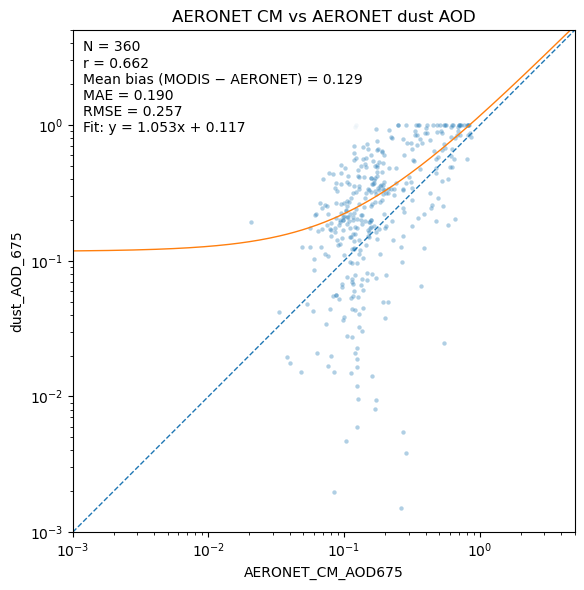

{'N': 360, 'mean_bias_modis_minus_aeronet': 0.12925542383532498, 'MAE': 0.19029657207980877, 'RMSE': 0.25714759889323113, 'Pearson_r': 0.6620239803703901, 'slope': 1.0528134182523805, 'intercept': 0.11724155804160274}


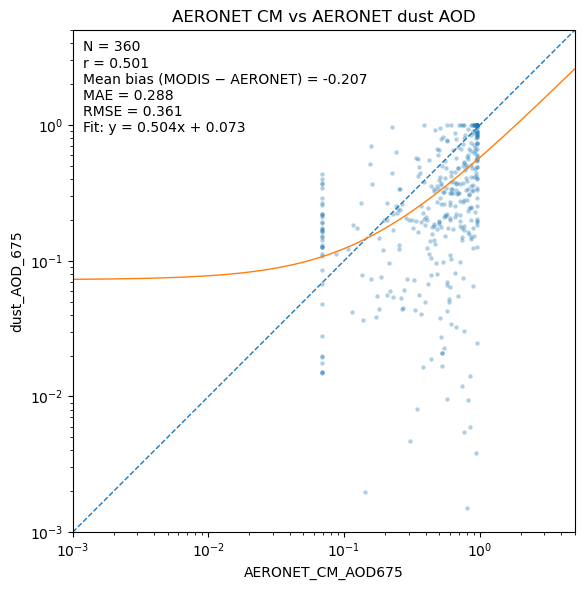

{'N': 360, 'mean_bias_modis_minus_aeronet': -0.20706132244404207, 'MAE': 0.28816852559636985, 'RMSE': 0.3605081882876124, 'Pearson_r': 0.5008285228578399, 'slope': 0.5041034471008669, 'intercept': 0.07252231438147577}


In [153]:


metrics = plot_aod_correlation_log(
    y_pred_lin,
    y_test_lin,
    xlabel="AERONET_CM_AOD675",
    ylabel="dust_AOD_675",
    title="AERONET CM vs AERONET dust AOD",
    mode="scatter",
)
print(metrics)

metrics = plot_aod_correlation_log(
    1-FMF_X_text,
    y_test_lin,
    xlabel="AERONET_CM_AOD675",
    ylabel="dust_AOD_675",
    title="AERONET CM vs AERONET dust AOD",
    mode="scatter",
)
print(metrics)

In [154]:
# MODIS_DB_AOD_R1 = MODIS_DB_AOD550/MODIS_DB_AOD660
# MODIS_DB_AOD_R2 = MODIS_DB_AOD412/MODIS_DB_AOD470
# arrays = [
#     dust_fraction_675,
#     MODIS_DB_AOD_R1,
#     MODIS_DB_AOD_R2,
#     MODIS_DB_AE,
#     MODIS_DB_SSA412,
#     MODIS_DB_SSA470,
#     MODIS_DB_SSA660,
# ]

# lengths = [len(a) for a in arrays]
# print("Array lengths:", lengths)

# assert len(set(lengths)) == 1, "ERROR: Arrays do not have the same length"
# import pandas as pd

# df = pd.DataFrame({
#     "dust_fraction_675":      dust_fraction_675,
#     "MODIS_DB_AOD_R1":  MODIS_DB_AOD_R1,
#     "MODIS_DB_AOD_R2":  MODIS_DB_AOD_R2,
#     "MODIS_DB_AE":      MODIS_DB_AE,
#     "MODIS_DB_SSA412":  MODIS_DB_SSA412,
#     "MODIS_DB_SSA470":  MODIS_DB_SSA470,
#     "MODIS_DB_SSA660":  MODIS_DB_SSA660,
# })
# # Replace inf with NaN
# df = df.replace([np.inf, -np.inf], np.nan)

# # Drop rows with missing target or features
# df = df.dropna()

# # Enforce physical bounds
# df = df[df["dust_fraction_675"] >= 0.0]

# for col in [
#     "MODIS_DB_AOD_R1","MODIS_DB_AOD_R2",
#     "MODIS_DB_AE"
# ]:
#     df = df[df[col] > 0]

# for col in [
#     "MODIS_DB_SSA412","MODIS_DB_SSA660","MODIS_DB_SSA470",
# ]:
#     df[col] = df[col].clip(0.0, 1.0)

# print("Final sample size:", len(df))

In [155]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In [156]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### save XGBoost model


In [157]:
import json
import numpy as np

# ---------- SAVE ----------
MODEL_PATH = "dust_aod_xgb.json"
META_PATH  = "dust_aod_xgb_meta.json"

# 1) Save model in XGBoost native format
model.save_model(MODEL_PATH)

# 2) Save metadata needed for correct inference
meta = {
    "feature_names": list(X.columns),
    "target_transform": "log1p",
    "eps": 0.0,  # set to whatever you used
}
with open(META_PATH, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:", MODEL_PATH, META_PATH)



Saved: dust_aod_xgb.json dust_aod_xgb_meta.json


## Apply Trained XGBoost model to DB 

In [158]:
# ---------- LOAD ----------
from xgboost import XGBRegressor

loaded = XGBRegressor()
loaded.load_model(MODEL_PATH)

with open(META_PATH, "r") as f:
    meta = json.load(f)

feature_names = meta["feature_names"]
eps = meta.get("eps", 0.0)

In [159]:
feature_names

['MODIS_DB_AOD550',
 'MODIS_DB_AOD412',
 'MODIS_DB_AOD470',
 'MODIS_DB_AOD660',
 'MODIS_DB_AE',
 'MODIS_DB_SSA412',
 'MODIS_DB_SSA470',
 'MODIS_DB_SSA660']

In [160]:
earthaccess.login(strategy="netrc")
gs = earthaccess.search_data(
        short_name="MOD04_L2",
        temporal=('2025-03-14 17:00:00','2025-03-14 17:10:00' ),
        point=(-101.112,33.98),
    )

In [161]:
gs

[Collection: {'ShortName': 'MOD04_L2', 'Version': '6.1'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -122.528203, 'Latitude': 30.260388}, {'Longitude': -98.988624, 'Latitude': 27.151423}, {'Longitude': -91.045295, 'Latitude': 44.486394}, {'Longitude': -120.917545, 'Latitude': 48.672962}, {'Longitude': -122.528203, 'Latitude': 30.260388}]}}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2025-03-14T17:05:00.000Z', 'EndingDateTime': '2025-03-14T17:10:00.000Z'}}
 Size(MB): 2.41248893737793
 Data: ['https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/MOD04_L2/MOD04_L2.A2025073.1705.061.2025074013638.hdf']]

In [162]:
downloaded_files = earthaccess.download(
                    gs[0],
                    local_path="./temp_downloads"
                )

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [163]:
!ls temp_downloads

INV				  MOD04_L2.A2025073.1705.061.2025074013638.hdf
INV_Level15_All_Points_V3.tar.gz  USAGE_INFORMATION
INV_Level2_All_Points_V3.tar.gz


In [164]:
MOD04_granule = MODIS_Lib.MODIS_DeepBlue_Level2('temp_downloads/MOD04_L2.A2025073.1705.061.2025074013638.hdf')

In [165]:
MODIS_DB_AOD550 = MOD04_granule.Deep_Blue_Aerosol_Optical_Depth_550_Land
MODIS_DB_AOD412 = MOD04_granule.Deep_Blue_Spectral_Aerosol_Optical_Depth_Land[0]
MODIS_DB_AOD470 = MOD04_granule.Deep_Blue_Spectral_Aerosol_Optical_Depth_Land[1]
MODIS_DB_AOD660 = MOD04_granule.Deep_Blue_Spectral_Aerosol_Optical_Depth_Land[2]
MODIS_DB_AE     = MOD04_granule.Deep_Blue_Angstrom_Exponent_Land
MODIS_DB_SSA412 = MOD04_granule.Deep_Blue_Spectral_Single_Scattering_Albedo_Land[0]
MODIS_DB_SSA470 = MOD04_granule.Deep_Blue_Spectral_Single_Scattering_Albedo_Land[1]
MODIS_DB_SSA660 = MOD04_granule.Deep_Blue_Spectral_Single_Scattering_Albedo_Land[2]

In [166]:
MOD04_granule.Deep_Blue_Aerosol_Optical_Depth_550_Land.shape

(204, 135)

In [167]:
['MODIS_DB_AOD550',
 'MODIS_DB_AOD412',
 'MODIS_DB_AOD470',
 'MODIS_DB_AOD660',
 'MODIS_DB_AE',
 'MODIS_DB_SSA412',
 'MODIS_DB_SSA470',
 'MODIS_DB_SSA660']

['MODIS_DB_AOD550',
 'MODIS_DB_AOD412',
 'MODIS_DB_AOD470',
 'MODIS_DB_AOD660',
 'MODIS_DB_AE',
 'MODIS_DB_SSA412',
 'MODIS_DB_SSA470',
 'MODIS_DB_SSA660']

In [168]:
MOD04_granule.Deep_Blue_Spectral_Aerosol_Optical_Depth_Land.shape

(3, 204, 135)

In [169]:
import json
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# -----------------------------
# Load model + metadata
# -----------------------------
MODEL_PATH = "dust_aod_xgb.json"
META_PATH  = "dust_aod_xgb_meta.json"

with open(META_PATH, "r") as f:
    meta = json.load(f)

feature_order = meta["feature_names"]           # must match training order
eps = float(meta.get("eps", 0.0))

model = XGBRegressor()
model.load_model(MODEL_PATH)

def inv_log1p_transform(y_log, eps=0.0):
    y_log = np.asarray(y_log, dtype=float)
    y_lin = np.expm1(y_log) - eps
    return np.clip(y_lin, 0.0, None)

# -----------------------------
# Build feature grids dict from your granule
# (make sure each is shape (H,W) = (204,135))
# -----------------------------
features_2d = {
    "MODIS_DB_AOD550": MODIS_DB_AOD550,
    "MODIS_DB_AOD412": MODIS_DB_AOD412,
    "MODIS_DB_AOD470": MODIS_DB_AOD470,
    "MODIS_DB_AOD660": MODIS_DB_AOD660,
    "MODIS_DB_AE":     MODIS_DB_AE,
    "MODIS_DB_SSA412": MODIS_DB_SSA412,
    "MODIS_DB_SSA470": MODIS_DB_SSA470,
    "MODIS_DB_SSA660": MODIS_DB_SSA660,
}

# -----------------------------
# Assemble X for inference in the saved feature order
# -----------------------------
# 1) shape checks
H, W = np.asarray(next(iter(features_2d.values()))).shape
for k, arr in features_2d.items():
    arr = np.asarray(arr)
    if arr.shape != (H, W):
        raise ValueError(f"{k} has shape {arr.shape}, expected {(H, W)}")

# 2) ensure all required features exist
missing = [c for c in feature_order if c not in features_2d]
extra   = [c for c in features_2d.keys() if c not in feature_order]
if missing:
    raise KeyError(f"Missing required features for model: {missing}")
if extra:
    print(f"Note: extra features provided but unused by model: {extra}")

# 3) flatten and stack into (H*W, n_features)
X_flat = np.column_stack([np.asarray(features_2d[c], dtype=float).ravel() for c in feature_order])

# 4) mask invalid rows (NaN/inf). Keep at least one finite feature row
valid = np.isfinite(X_flat).all(axis=1)

# -----------------------------
# Predict (log space), invert to linear, reshape back to grid
# -----------------------------
pred_lin_flat = np.full(H * W, np.nan, dtype=np.float32)

if np.any(valid):
    X_valid = pd.DataFrame(X_flat[valid], columns=feature_order)
    y_pred_log = model.predict(X_valid)
    y_pred_lin = inv_log1p_transform(y_pred_log, eps=eps)
    pred_lin_flat[valid] = y_pred_lin.astype(np.float32)

dust_aod_grid_675 = pred_lin_flat.reshape(H, W)

dust_aod_grid_675  # (204,135) predicted dust AOD on the MODIS grid

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [170]:
MOD04_granule.lat

array([[48.574127, 48.567795, 48.558872, ..., 44.81216 , 44.68251 ,
        44.54225 ],
       [48.48565 , 48.479187, 48.47009 , ..., 44.72885 , 44.599823,
        44.45957 ],
       [48.397247, 48.390644, 48.38158 , ..., 44.64585 , 44.517635,
        44.377743],
       ...,
       [30.760769, 30.736185, 30.71181 , ..., 27.753773, 27.666327,
        27.571198],
       [30.672535, 30.64785 , 30.623386, ..., 27.667624, 27.580267,
        27.485355],
       [30.583483, 30.558722, 30.534195, ..., 27.580893, 27.493685,
        27.399055]], dtype=float32)

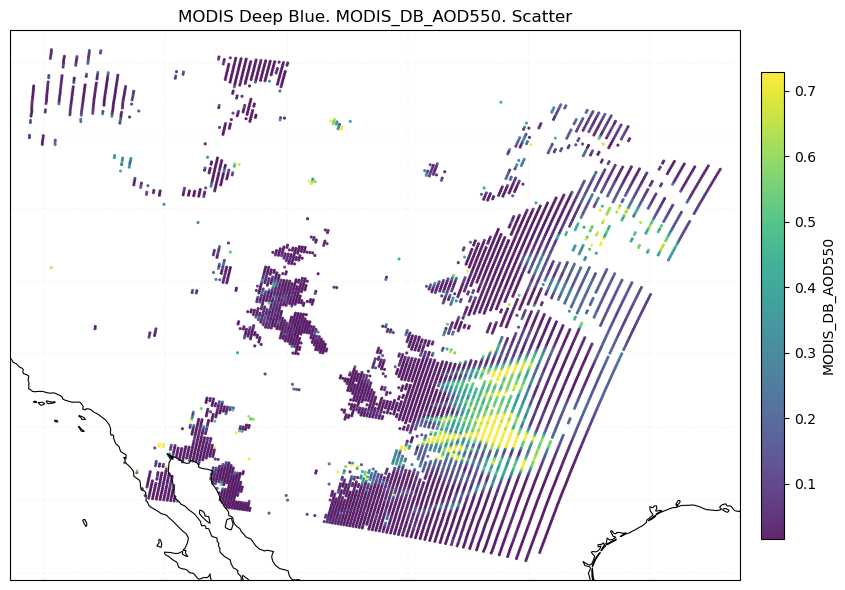

MODIS_DB_AOD550 {'N': 6905, 'vmin': 0.01600000075995922, 'vmax': 0.7289200346218423}


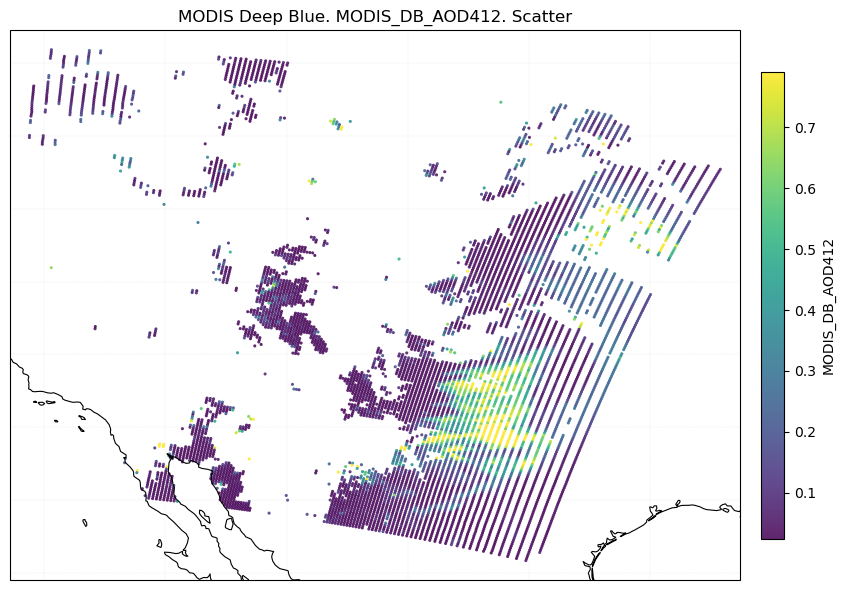

MODIS_DB_AOD412 {'N': 6905, 'vmin': 0.02400000113993883, 'vmax': 0.7919200376141817}


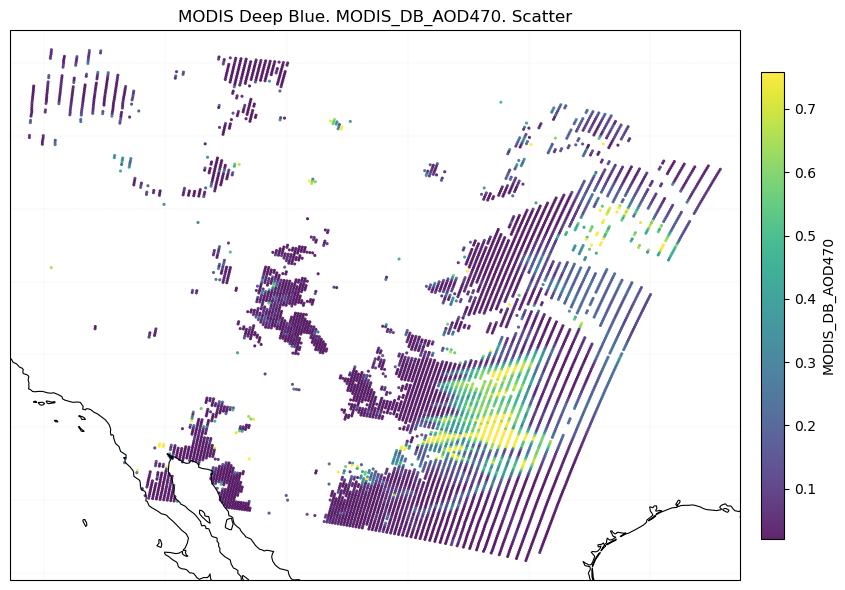

MODIS_DB_AOD470 {'N': 6905, 'vmin': 0.021000000997446477, 'vmax': 0.7590000360505655}


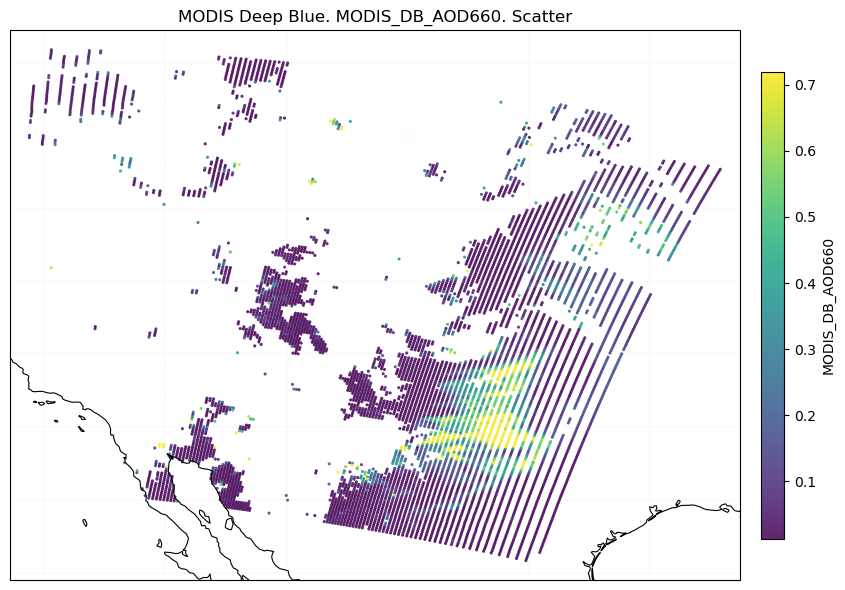

MODIS_DB_AOD660 {'N': 6905, 'vmin': 0.013000000617466867, 'vmax': 0.7200000341981649}


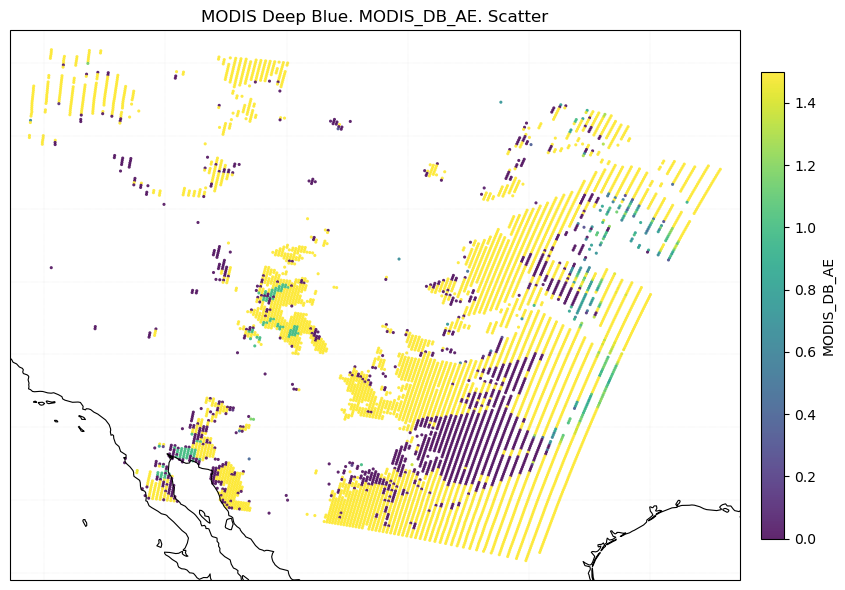

MODIS_DB_AE {'N': 6905, 'vmin': 0.0, 'vmax': 1.500000071246177}


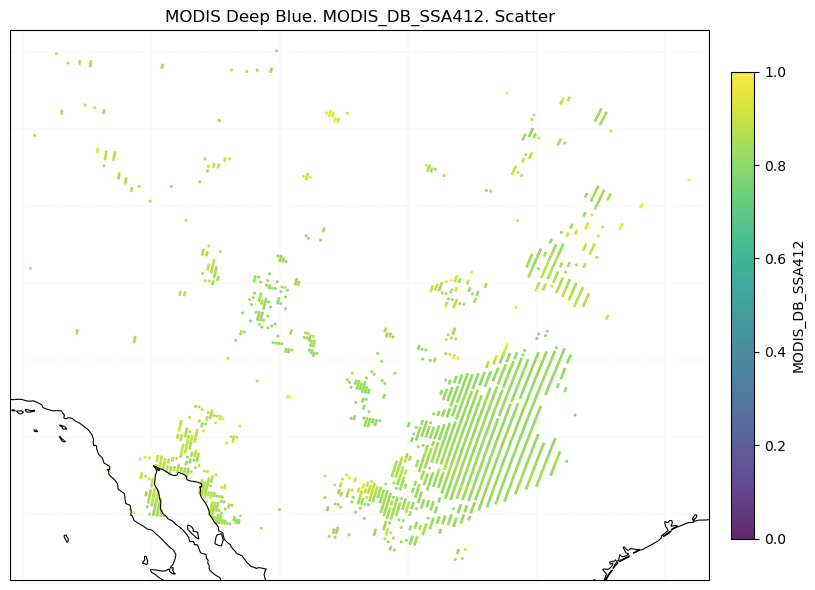

MODIS_DB_SSA412 {'N': 2253, 'vmin': 0.0, 'vmax': 1.0}


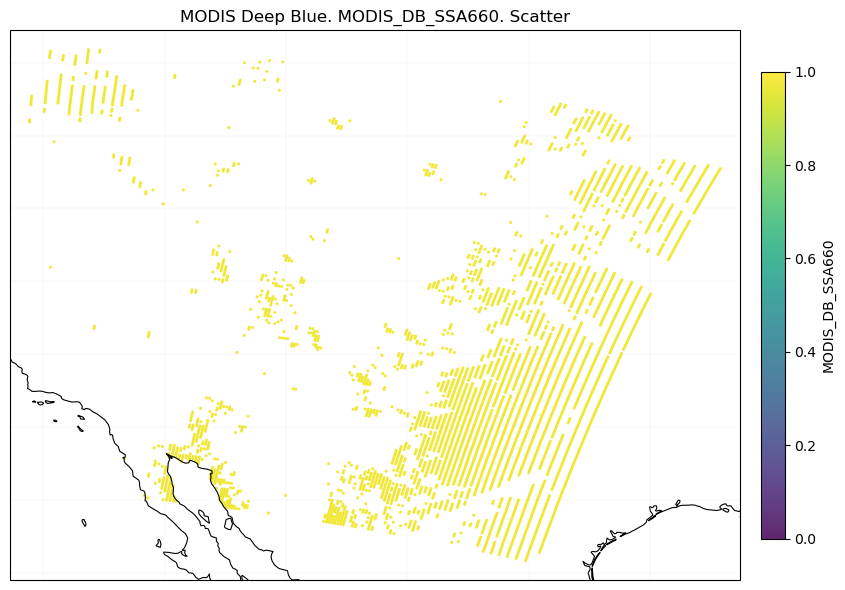

MODIS_DB_SSA660 {'N': 3981, 'vmin': 0.0, 'vmax': 1.0}


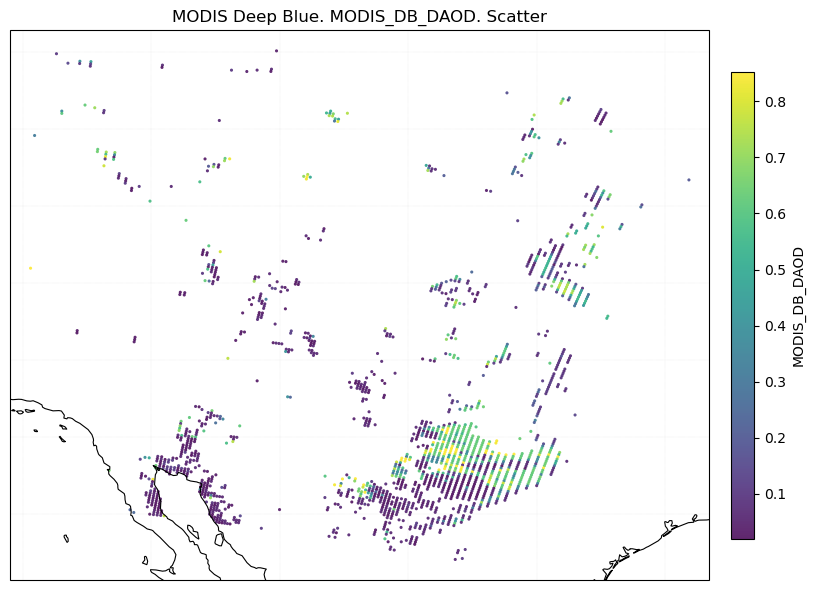

MODIS_DB_DAOD {'N': 1768, 'vmin': 0.020114930346608162, 'vmax': 0.8527828943729401}


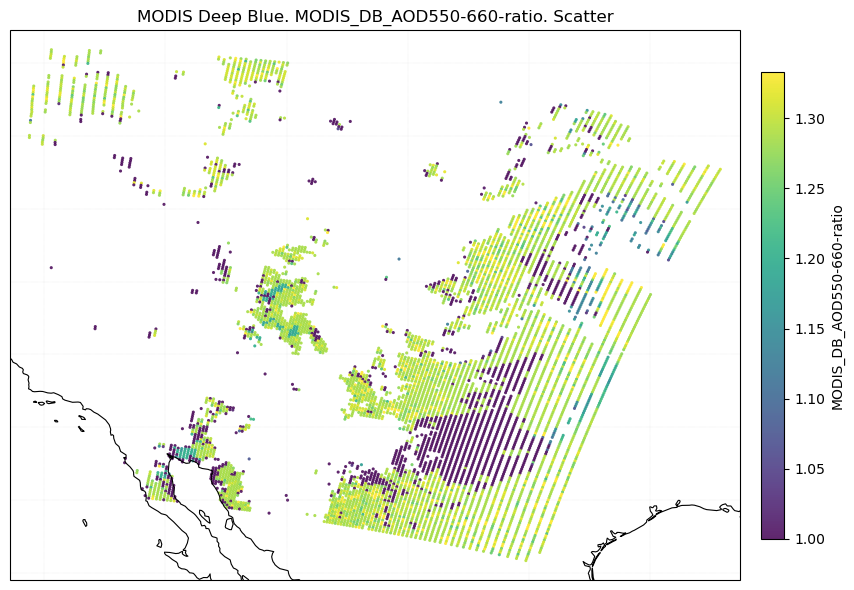

MODIS_DB_AOD550-660-ratio {'N': 6905, 'vmin': 1.0, 'vmax': 1.3333333333333333}


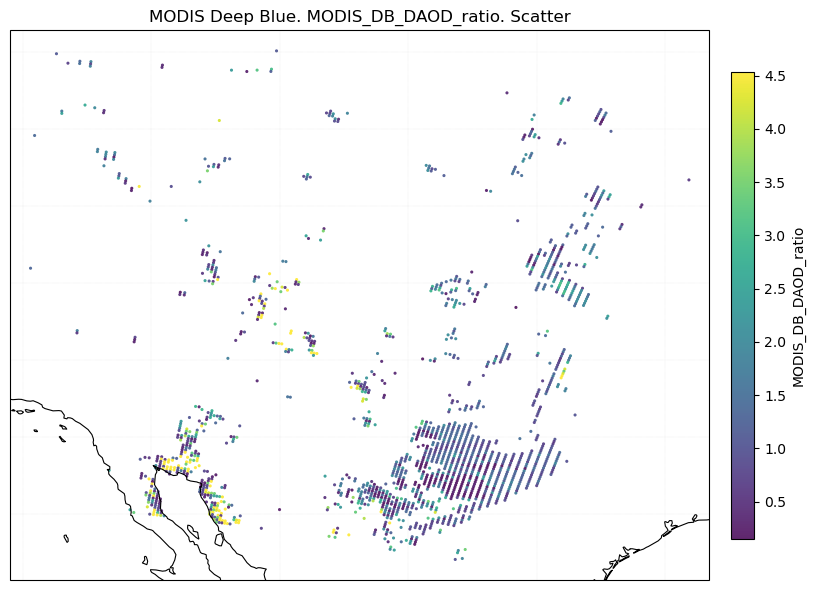

MODIS_DB_DAOD_ratio {'N': 1768, 'vmin': 0.15058131785072867, 'vmax': 4.53933253611016}


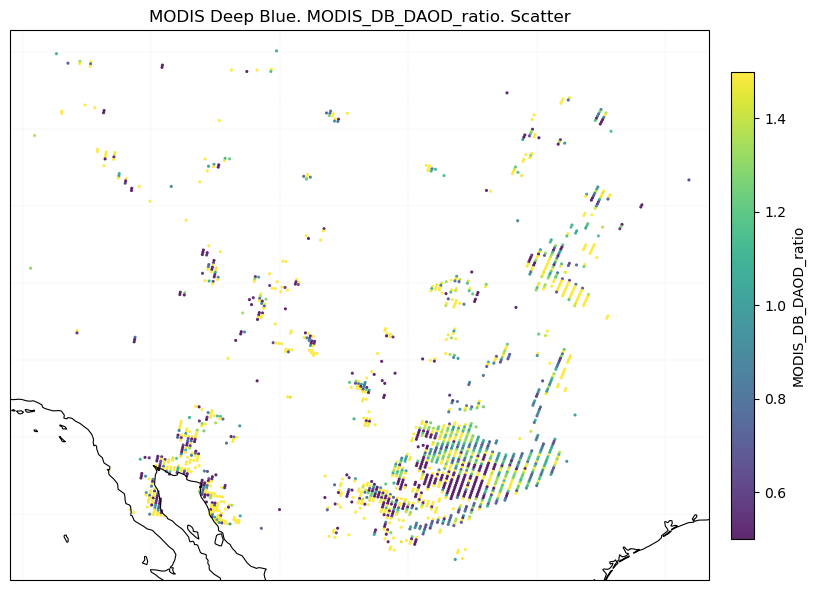

In [171]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ---------------------------
# Nice, reusable scatter map
# ---------------------------
def plot_feature_scatter_map(
    lat2d, lon2d, z2d, *,
    title="",
    cbar_label="",
    projection="robinson",   # "robinson" or "platecarree"
    extent_pad_deg=1.0,
    subsample=1,             # e.g., 2 or 3 to thin points
    s=4, alpha=0.8,
    robust=True,             # robust color limits (2–98%)
    vmin=None, vmax=None,
    cmap=None,               # leave None to use matplotlib default
    is_fraction=False,       # for SSA/FM F etc. forces [0,1]
    wrap_lon=True,
):
    lat = np.asarray(lat2d, dtype=float)
    lon = np.asarray(lon2d, dtype=float)
    z   = np.asarray(z2d, dtype=float)

    if wrap_lon:
        lon = ((lon + 180) % 360) - 180

    # optional thinning
    if subsample > 1:
        lat = lat[::subsample, ::subsample]
        lon = lon[::subsample, ::subsample]
        z   = z[::subsample, ::subsample]

    # flatten + finite mask
    lat_f = lat.ravel()
    lon_f = lon.ravel()
    z_f   = z.ravel()
    m = np.isfinite(lat_f) & np.isfinite(lon_f) & np.isfinite(z_f)
    lat_f, lon_f, z_f = lat_f[m], lon_f[m], z_f[m]

    if lat_f.size == 0:
        raise ValueError("No finite samples to plot.")

    # color limits
    if is_fraction:
        vvmin, vvmax = 0.0, 1.0
    else:
        if (vmin is None) or (vmax is None):
            if robust:
                vvmin = float(np.nanpercentile(z_f, 2)) if vmin is None else vmin
                vvmax = float(np.nanpercentile(z_f, 98)) if vmax is None else vmax
            else:
                vvmin = float(np.nanmin(z_f)) if vmin is None else vmin
                vvmax = float(np.nanmax(z_f)) if vmax is None else vmax
        else:
            vvmin, vvmax = float(vmin), float(vmax)

        # guard against degenerate limits
        if not np.isfinite(vvmin) or not np.isfinite(vvmax) or vvmin == vvmax:
            vvmin = float(np.nanmin(z_f))
            vvmax = float(np.nanmax(z_f))

    # projections
    proj_data = ccrs.PlateCarree()
    if projection.lower() == "platecarree":
        proj_map = ccrs.PlateCarree()
    else:
        proj_map = ccrs.Robinson()

    fig = plt.figure(figsize=(11, 6))
    ax = plt.axes(projection=proj_map)
    ax.coastlines(linewidth=0.8)
    gl = ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5, linestyle=":")

    # auto-zoom to granule footprint (looks much better than global)
    ax.set_extent(
        [lon_f.min()-extent_pad_deg, lon_f.max()+extent_pad_deg,
         lat_f.min()-extent_pad_deg, lat_f.max()+extent_pad_deg],
        crs=proj_data
    )

    sc = ax.scatter(
        lon_f, lat_f,
        c=z_f,
        s=s,
        alpha=alpha,
        transform=proj_data,
        vmin=vvmin, vmax=vvmax,
        cmap=cmap,
        linewidths=0
    )

    cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    cb.set_label(cbar_label if cbar_label else "value")

    ax.set_title(title if title else "Feature map (scatter)")
    plt.tight_layout()
    plt.show()

    return {"N": int(lat_f.size), "vmin": vvmin, "vmax": vvmax}


# ---------------------------
# Batch plotting for all features
# ---------------------------
lat2d = MOD04_granule.lat
lon2d = MOD04_granule.lon

features_2d = {
    "MODIS_DB_AOD550": MODIS_DB_AOD550,
    "MODIS_DB_AOD412": MODIS_DB_AOD412,
    "MODIS_DB_AOD470": MODIS_DB_AOD470,
    "MODIS_DB_AOD660": MODIS_DB_AOD660,
    "MODIS_DB_AE":     MODIS_DB_AE,
    "MODIS_DB_SSA412": MODIS_DB_SSA412,
    #"MODIS_DB_SSA470": MODIS_DB_SSA470,
    "MODIS_DB_SSA660": MODIS_DB_SSA660,
    "MODIS_DB_DAOD": dust_aod_grid_675,
    "MODIS_DB_AOD550-660-ratio": MODIS_DB_AOD550/MODIS_DB_AOD660,
    "MODIS_DB_DAOD_ratio": dust_aod_grid_675/MODIS_DB_AOD660,
}

for name, arr in features_2d.items():
    is_ssa = "SSA" in name
    stats = plot_feature_scatter_map(
        lat2d, lon2d, arr,
        title=f"MODIS Deep Blue. {name}. Scatter",
        cbar_label=name,
        projection="platecarree",   # clearer when zoomed to swath
        subsample=1,                # set 2 or 3 if it’s slow / too dense
        s=5,
        alpha=0.85,
        robust=True,
        is_fraction=is_ssa,         # SSA fixed to [0,1]
        extent_pad_deg=0.8,
    )
    print(name, stats)
stats = plot_feature_scatter_map(
        lat2d, lon2d, dust_aod_grid_675/MODIS_DB_AOD660,
        title=f"MODIS Deep Blue. {name}. Scatter",
        cbar_label=name,
        projection="platecarree",   # clearer when zoomed to swath
        subsample=1,                # set 2 or 3 if it’s slow / too dense
        s=5,
        alpha=0.85,
        robust=True,
        is_fraction=is_ssa,         # SSA fixed to [0,1]
        extent_pad_deg=0.8,
        vmin=0.5,vmax=1.5
    )

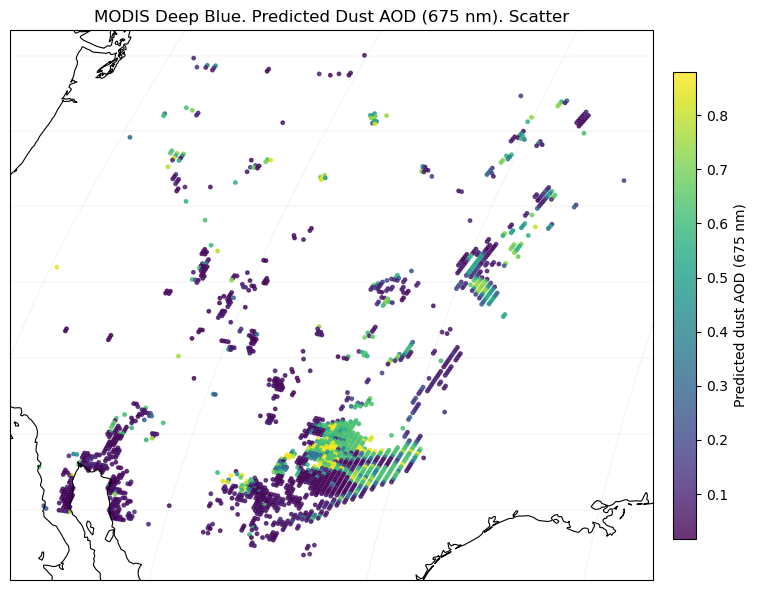

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lat = np.asarray(MOD04_granule.lat, dtype=float)
lon = np.asarray(MOD04_granule.lon, dtype=float)
z   = np.asarray(dust_aod_grid_675, dtype=float)

# wrap lon to [-180, 180)
lon = ((lon + 180) % 360) - 180

# flatten + keep only finite points
lat_f = lat.ravel()
lon_f = lon.ravel()
z_f   = z.ravel()
m = np.isfinite(lat_f) & np.isfinite(lon_f) & np.isfinite(z_f)

lat_f = lat_f[m]
lon_f = lon_f[m]
z_f   = z_f[m]

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj_map)
ax.coastlines(linewidth=0.8)
ax.gridlines(draw_labels=False, linewidth=0.2, alpha=0.5)

sc = ax.scatter(
    lon_f, lat_f,
    c=z_f,
    s=6,              # point size
    alpha=0.8,
    transform=proj_data,
)

cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cb.set_label("Predicted dust AOD (675 nm)")

ax.set_title("MODIS Deep Blue. Predicted Dust AOD (675 nm). Scatter")
plt.tight_layout()
plt.show()

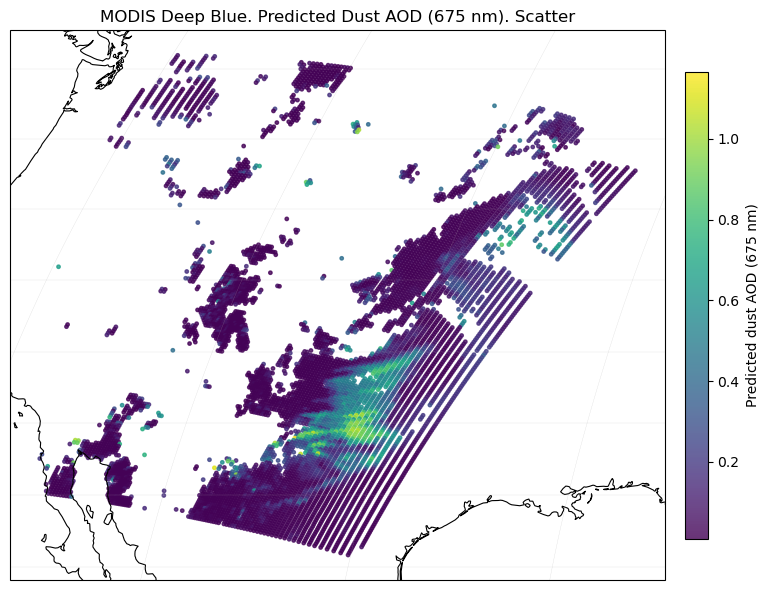

In [173]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lat = np.asarray(MOD04_granule.lat, dtype=float)
lon = np.asarray(MOD04_granule.lon, dtype=float)
z   = np.asarray(MODIS_DB_AOD550, dtype=float)

# wrap lon to [-180, 180)
lon = ((lon + 180) % 360) - 180

# flatten + keep only finite points
lat_f = lat.ravel()
lon_f = lon.ravel()
z_f   = z.ravel()
m = np.isfinite(lat_f) & np.isfinite(lon_f) & np.isfinite(z_f)

lat_f = lat_f[m]
lon_f = lon_f[m]
z_f   = z_f[m]

proj_data = ccrs.PlateCarree()
proj_map  = ccrs.Robinson()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=proj_map)
ax.coastlines(linewidth=0.8)
ax.gridlines(draw_labels=False, linewidth=0.2, alpha=0.5)

sc = ax.scatter(
    lon_f, lat_f,
    c=z_f,
    s=6,              # point size
    alpha=0.8,
    transform=proj_data,
)

cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
cb.set_label("Predicted dust AOD (675 nm)")

ax.set_title("MODIS Deep Blue. Predicted Dust AOD (675 nm). Scatter")
plt.tight_layout()
plt.show()